# BUSINESS UNDERSTANDING

##Tổng quan bài toán
###Bài toán đặt ra yêu cầu tiến hành phân tích hành vi của khách hàng đang sử dụng tính năng “Heo Số” trên ứng dụng ngân hàng số của MB Bank, nhằm xây dựng chân dung người dùng (customer profile) và dự báo nhóm khách hàng có nguy cơ ngừng sử dụng dịch vụ trong tương lai (churn).

###Làm rõ hơn bối cảnh trong bài,  Heo Số là một tính năng tiết kiệm số do MB Bank cung cấp trên ứng dụng ngân hàng số, cho phép khách hàng thực hiện gửi tiền theo hình thức tiết kiệm mục tiêu với các khoản tiền nhỏ, linh hoạt và được quản lý hoàn toàn trực tuyến. Tính năng này hỗ trợ người dùng thiết lập và theo dõi các mục tiêu tài chính cá nhân, đồng thời khuyến khích hình thành thói quen tiết kiệm thông qua cơ chế gửi tiền chủ động, giao diện trực quan và khả năng cập nhật tiến độ theo thời gian thực. Về bản chất, Heo Số đóng vai trò như một khoản tiết kiệm ngắn hạn, linh hoạt, không yêu cầu kỳ hạn cố định, cho phép khách hàng nạp tiền, rút tiền và điều chỉnh mục tiêu dễ dàng. Với cơ chế vận hành đơn giản và mức vốn tham gia thấp, Heo Số hướng tới việc mở rộng khả năng tiếp cận tài chính cho nhiều nhóm khách hàng. Bên cạnh chức năng tiết kiệm, Heo Số còn góp phần gia tăng mức độ tương tác của khách hàng với hệ sinh thái dịch vụ số của MB Bank, từ đó tăng cường trải nghiệm người dùng cũng như đóng góp vào nguồn vốn huy động ổn định của ngân hàng.
###Việc phân tích hành vi khách hàng và dự báo khả năng ngừng sử dụng tính năng Heo Số có tính cấp thiết rõ ràng khi xét đến vai trò của tiền gửi trong hoạt động ngân hàng thương mại Việt Nam. Theo nghiên cứu đăng trên Tạp chí Ngân hàng Nhà nước (2024), tiền gửi chiếm khoảng 70–80% tổng nguồn vốn của các ngân hàng thương mại, trong đó tiền gửi chi phí thấp - bao gồm các hình thức tiết kiệm linh hoạt và tiền gửi nhỏ lẻ - chiếm trên 25% tổng huy động và đóng vai trò quan trọng trong việc giảm chi phí vốn. Nghiên cứu cũng chỉ ra rằng khả năng sinh lời của ngân hàng phụ thuộc trực tiếp vào quy mô và tính ổn định của nguồn vốn huy động này. Do đó, việc nhận diện sớm nhóm khách hàng có nguy cơ churn Heo Số là cần thiết để MB Bank duy trì nguồn vốn giá rẻ ổn định, hạn chế rủi ro suy giảm hiệu quả tài chính và củng cố tăng trưởng bền vững trong bối cảnh cạnh tranh số ngày càng gia tăng.


###Trong quá trình thực hiện, nhóm nghiên cứu cần tự xây dựng và xác định tiêu chí để định nghĩa thế nào là một khách hàng churn Heo Số, bảo đảm tiêu chí này phản ánh đúng hành vi thực tế và có thể đo lường được bằng dữ liệu.

##Tài liệu tham khảo
###Nguyễn, T. T. H., & Trần, T. B. (2024). Tác động của tiền gửi đến hiệu quả tài chính các ngân hàng thương mại Việt Nam. Tạp chí Ngân hàng (Ngân hàng Nhà nước Việt Nam). https://tapchinganhang.gov.vn/tac-dong-cua-tien-gui-den-hieu-qua-tai-chinh-cac-ngan-hang-thuong-mai-viet-nam-465.html

##Mục tiêu bài toán


###1.   Khám phá và mô tả đặc điểm của người dùng và người rời bỏ Heo Số (bao gồm nhân khẩu học, mức độ tương tác với ứng dụng, khả năng tài chính và hành vi tiết kiệm).
###2.   Nhận diện các dấu hiệu dẫn đến rời bỏ, phân tích sự khác biệt giữa khách hàng tiếp tục sử dụng và khách hàng ngừng sử dụng dịch vụ.
###3.   Xây dựng mô hình dự báo churn, hỗ trợ ngân hàng X chủ động triển khai các hoạt động chăm sóc, duy trì và phát triển tệp người dùng Heo Số.





##Giả thuyết trong bài

###Giả thuyết 1: Các giá trị về giao dịch trong bài không phải giá trị thật, mà là các giá trị được scale. Bộ dữ liệu này có thể không được scale theo MinMaxScaling (do không phải cột nào cũng có min 0 và max 1) hoặc Z-score (do không có giá trị nào dưới 0). Nhóm đưa ra giả định bộ dữ liệu được thực hiện theo Decimal scaling

###Giả thuyết 2: Null trong dữ liệu không phải do lỗi hệ thống ghi nhận, mà do khách hàng không đăng nhập vào app dẫn đến hệ thống không ghi nhận hoạt động. Ví dụ cột count_payment_code_week (số_loại_dịch_vụ_sử_dụng_trong_1_tuần) có giá trị 0 nghĩa là khách hàng đăng nhập vào hệ thống nhưng không sử dụng dịch vụ nào, còn null nghĩa là khách hàng không đăng nhập vào app ngân hàng

##Định nghĩa về Churn
###Số lần đăng nhập tháng 3 = Số lần đăng nhập tháng 6 (Hệ thống dừng ghi nhận thêm số lần đăng nhập) => Churn (1). Số lần đăng nhập tháng 3 < Số lần đăng nhập tháng 6 (Hệ thống ghi nhận thêm số lần đăng nhập) => Không Churn (0)


# NHẬP DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
df = pd.read_csv('/content/dataset.csv')
df.head()

,local_ref_1,vn_marital_status,resid_province,resid_district,resid_wards,birth_incorp_date,amount_week,max_amount_week,min_amount_week,distinct_payment_code_week,...,totalSavings2021_heoSo,balanceJuin2021,nominal_interestJuin2021,real_interestJuin2021,nhomno_xhtdJuin2021,categoryJuin2021,sub_productJuin2021,loaikyhanJuin2021,sectorJuin2021,product_codeJuin2021
0,MALE,Married,27.0,262.0,9436.0,1992.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MALE,Single,79.0,769.0,27097.0,1986.0,NaN,NaN,NaN,NaN,...,NaN,0.003666,0.006953,0.004128,1.0,21061.0,365.0,DH,1890.0,22321.0
2,MALE,Married,1.0,250.0,8989.0,1980.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MALE,Single,40.0,431.0,18055.0,2001.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MALE,Married,49.0,512.0,20758.0,1989.0,0.0,0.000114,0.000636,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(100000, 50)

#LÀM SẠCH DATA

In [5]:
df_clean = df.copy()

##Đổi tên cột

Để phục vụ cho quá trình phân tích, nhóm đổi tên các cột có trong bộ dataset quy ước chung dễ nhớ hơn

In [6]:
rename_dict = {
    "local_ref_1": "giới_tính_khách_hàng",
    "vn_marital_status": "tình_trạng_hôn_nhân",
    "resid_province": "tỉnh_thành_sinh_sống",
    "resid_district": "quận_huyện_sinh_sống",
    "resid_wards": "phường_xã_sinh_sống",
    "birth_incorp_date": "ngày_sinh",

    "amount_week": "tổng_số_tiền_giao_dịch_trong_1_tuần",
    "max_amount_week": "số_tiền_lớn_nhất_trong_1_tuần",
    "min_amount_week": "số_tiền_nhỏ_nhất_trong_1_tuần",
    "distinct_payment_code_week": "số_loại_dịch_vụ_sử_dụng_trong_1_tuần",
    "count_payment_code_week": "số_lần_sử_dụng_dịch_vụ_trong_1_tuần",
    "distinct_trans_group_week": "số_nhóm_giao_dịch_trong_1_tuần",
    "distinct_ref_no_week": "số_lượng_đối_tác_giao_dịch_trong_1_tuần",

    "amount_month": "tổng_số_tiền_giao_dịch_trong_1_tháng",
    "max_amount_month": "số_tiền_lớn_nhất_trong_1_tháng",
    "min_amount_month": "số_tiền_nhỏ_nhất_trong_1_tháng",
    "distinct_payment_code_month": "số_loại_dịch_vụ_sử_dụng_trong_1_tháng",
    "count_payment_code_month": "số_lần_sử_dụng_dịch_vụ_trong_1_tháng",
    "distinct_trans_group_month": "số_nhóm_giao_dịch_trong_1_tháng",
    "distinct_ref_no_month": "số_lượng_đối_tác_giao_dịch_trong_1_tháng",

    "amount_3month": "tổng_số_tiền_giao_dịch_trong_3_tháng",
    "max_amount_3month": "số_tiền_lớn_nhất_trong_3_tháng",
    "min_amount_3month": "số_tiền_nhỏ_nhất_trong_3_tháng",
    "distinct_payment_code_3month": "số_loại_dịch_vụ_sử_dụng_trong_3_tháng",
    "count_payment_code_3month": "số_lần_sử_dụng_dịch_vụ_trong_3_tháng",
    "distinct_trans_group_3month": "số_nhóm_giao_dịch_trong_3_tháng",
    "distinct_ref_no_3month": "số_lượng_đối_tác_giao_dịch_trong_3_tháng",

    "most_act_mar2021_count": "số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021",
    "most_act_mar2021": "loại_giao_dịch_phổ_biến_nhất_tháng_3_2021",
    "total_act_mar2021": "tổng_số_giao_dịch_tháng_3_2021",
    "total_amt_mar2021": "tổng_giá_trị_giao_dịch_tháng_3_2021",

    "most_act_juin2021_count": "số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_6_2021",
    "most_act_juin2021": "loại_giao_dịch_phổ_biến_nhất_tháng_6_2021",
    "total_act_juin2021": "tổng_số_giao_dịch_tháng_6_2021",
    "total_amt_juin2021": "tổng_giá_trị_giao_dịch_tháng_6_2021",

    "rd_id": "mã_khách_hàng",

    "savingValueMar2021_heoSo": "số_dư_tiết_kiệm_heo_số_tháng_3_2021",
    "savingValueJuin2021_heoSo": "số_dư_tiết_kiệm_heo_số_tháng_6_2021",
    "totalLoginMar2021_heoSo": "tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021",
    "totalLoginJuin2021_heoSo": "tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021",
    "totalSavings2021_heoSo": "tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021",

    "balanceJuin2021": "số_dư_tài_khoản_tiền_gửi",
    "nominal_interestJuin2021": "lãi_suất_danh_nghĩa",
    "real_interestJuin2021": "lãi_suất_thực_tế",

    "nhomno_xhtdJuin2021": "nhóm_nợ_tại_ngân_hàng",
    "categoryJuin2021": "nhóm_sản_phẩm_tín_dụng",
    "sub_productJuin2021": "sản_phẩm_tín_dụng",
    "loaikyhanJuin2021": "loại_kỳ_hạn_vay",
    "sectorJuin2021": "ngành_nghề_kinh_doanh",
    "product_codeJuin2021": "mã_sản_phẩm_vay"
}

# Áp dụng:
df_clean = df_clean.rename(columns=rename_dict)

Kiểm tra tên cột và số lượng cột sau khi đổi tên


In [7]:
print(df_clean.columns)
print(f"Total columns: {df_clean.shape[1]}")

Index(['giới_tính_khách_hàng', 'tình_trạng_hôn_nhân', 'tỉnh_thành_sinh_sống',
       'quận_huyện_sinh_sống', 'phường_xã_sinh_sống', 'ngày_sinh',
       'tổng_số_tiền_giao_dịch_trong_1_tuần', 'số_tiền_lớn_nhất_trong_1_tuần',
       'số_tiền_nhỏ_nhất_trong_1_tuần', 'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tuần', 'số_nhóm_giao_dịch_trong_1_tuần',
       'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
       'tổng_số_tiền_giao_dịch_trong_1_tháng',
       'số_tiền_lớn_nhất_trong_1_tháng', 'số_tiền_nhỏ_nhất_trong_1_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
       'số_nhóm_giao_dịch_trong_1_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
       'tổng_số_tiền_giao_dịch_trong_3_tháng',
       'số_tiền_lớn_nhất_trong_3_tháng', 'số_tiền_nhỏ_nhất_trong_3_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
       'số_nhóm_giao_dịch_trong_3_tháng

##Kiểm tra trùng lặp

In [8]:
num_duplicates = df_clean.duplicated().sum()
print(f"Số lượng hàng trùng lặp trong DataFrame: {num_duplicates}")

Số lượng hàng trùng lặp trong DataFrame: 0


##Chuẩn hóa format trong các cột định tính

In [9]:
qualitative_cols = df_clean.select_dtypes(include='object').columns

for col in qualitative_cols:
    unique_values = df_clean[col].unique()
    num_unique = len(unique_values)
    print(f"Cột: {col}")
    print(f"Số lượng giá trị unique: {num_unique}")
    if num_unique <= 20:
        print(f"Giá trị unique: {unique_values}")
    else:
        print("\t(Quá nhiều giá trị unique để hiển thị toàn bộ)")
    print("\n" + "-"*50 + "\n")

Cột: giới_tính_khách_hàng
Số lượng giá trị unique: 3
Giá trị unique: ['MALE' 'FEMALE' nan]

--------------------------------------------------

Cột: tình_trạng_hôn_nhân
Số lượng giá trị unique: 8
Giá trị unique: ['Married' 'Single' nan 'Other' 'Partner' 'Seperated' 'Divorced' 'Widow']

--------------------------------------------------

Cột: loại_giao_dịch_phổ_biến_nhất_tháng_3_2021
Số lượng giá trị unique: 7
Giá trị unique: ['Giao dich chuyen khoan' nan 'GIAO DICH PHI TAI CHINH'
 'Giao dich thanh toan' 'GIAO DICH RUT TIEN ATM' 'GIAO DICH TIET KIEM'
 'GIAO DICH THANH TOAN']

--------------------------------------------------

Cột: loại_giao_dịch_phổ_biến_nhất_tháng_6_2021
Số lượng giá trị unique: 8
Giá trị unique: ['Giao dich chuyen khoan' 'Giao dich thanh toan' nan
 'GIAO DICH RUT TIEN ATM' 'GIAO DICH TIET KIEM' 'GIAO DICH PHI TAI CHINH'
 'GIAO DICH THANH TOAN' 'GIAO DICH VAY']

--------------------------------------------------

Cột: loại_kỳ_hạn_vay
Số lượng giá trị unique: 4
Giá trị

###Chuẩn hóa cột giới tính

In [10]:
df_clean['giới_tính_khách_hàng'] = df_clean['giới_tính_khách_hàng'].replace({
    'MALE': 'Nam',
    'FEMALE': 'Nữ'
})

###Chuẩn hóa tình trạng hôn nhân

In [11]:
df_clean['tình_trạng_hôn_nhân'] = df_clean['tình_trạng_hôn_nhân'].replace({
    'Married': 'Đã kết hôn',
    'Single': 'Độc thân',
    'Other': 'Khác',
    'Partner': 'Sống chung',
    'Seperated': 'Ly thân',
    'Divorced': 'Ly hôn',
    'Widow': 'Góa'
})

### Chuẩn hóa kỳ hạn vay

In [12]:
df_clean['loại_kỳ_hạn_vay'] = df_clean['loại_kỳ_hạn_vay'].replace({
    'DH': 'Dài hạn',
    'NH': 'Ngắn hạn',
    'TH': 'Trung hạn'
})

###Chuẩn hóa format các giá trị của 2 cột loại_giao_dịch_phổ_biến_nhất_tháng_3_2021, loại_giao_dịch_phổ_biến_nhất_tháng_6_2021

In [13]:
def standardize_transaction_type(text):
    if pd.isna(text):
        return text
    # Convert to string, then to lowercase, then capitalize the first letter
    return str(text).lower().capitalize()

# Apply the function to the specified columns
df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'] = df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'].apply(standardize_transaction_type)
df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'] = df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'].apply(standardize_transaction_type)

print("Unique values after standardization for 'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021':")
print(df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'].unique())

print("\nUnique values after standardization for 'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021':")
print(df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'].unique())

Unique values after standardization for 'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021':
['Giao dich chuyen khoan' nan 'Giao dich phi tai chinh'
 'Giao dich thanh toan' 'Giao dich rut tien atm' 'Giao dich tiet kiem']

Unique values after standardization for 'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021':
['Giao dich chuyen khoan' 'Giao dich thanh toan' nan
 'Giao dich rut tien atm' 'Giao dich tiet kiem' 'Giao dich phi tai chinh'
 'Giao dich vay']


In [14]:
transaction_type_mapping = {
    'Giao dich chuyen khoan': 'Giao dịch chuyển khoản',
    'Giao dich phi tai chinh': 'Giao dịch phi tài chính',
    'Giao dich thanh toan': 'Giao dịch thanh toán',
    'Giao dich rut tien atm': 'Giao dịch rút tiền ATM',
    'Giao dich tiet kiem': 'Giao dịch tiết kiệm',
    'Giao dich vay': 'Giao dịch vay'
}

df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'] = df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'].replace(transaction_type_mapping)
df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'] = df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'].replace(transaction_type_mapping)

print("Unique values after translation for 'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021':")
print(df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_3_2021'].unique())

print("\nUnique values after translation for 'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021':")
print(df_clean['loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'].unique())

Unique values after translation for 'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021':
['Giao dịch chuyển khoản' nan 'Giao dịch phi tài chính'
 'Giao dịch thanh toán' 'Giao dịch rút tiền ATM' 'Giao dịch tiết kiệm']

Unique values after translation for 'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021':
['Giao dịch chuyển khoản' 'Giao dịch thanh toán' nan
 'Giao dịch rút tiền ATM' 'Giao dịch tiết kiệm' 'Giao dịch phi tài chính'
 'Giao dịch vay']


###Kiểm tra các giá trị định tính sau khi chuẩn hóa

In [15]:
qualitative_cols = df_clean.select_dtypes(include='object').columns

for col in qualitative_cols:
    unique_values = df_clean[col].unique()
    num_unique = len(unique_values)
    print(f"Cột: {col}")
    print(f"Số lượng giá trị unique: {num_unique}")
    if num_unique <= 20:
        print(f"Giá trị unique: {unique_values}")
    else:
        print("\t(Quá nhiều giá trị unique để hiển thị toàn bộ)")
    print("\n" + "-"*50 + "\n")

Cột: giới_tính_khách_hàng
Số lượng giá trị unique: 3
Giá trị unique: ['Nam' 'Nữ' nan]

--------------------------------------------------

Cột: tình_trạng_hôn_nhân
Số lượng giá trị unique: 8
Giá trị unique: ['Đã kết hôn' 'Độc thân' nan 'Khác' 'Sống chung' 'Ly thân' 'Ly hôn' 'Góa']

--------------------------------------------------

Cột: loại_giao_dịch_phổ_biến_nhất_tháng_3_2021
Số lượng giá trị unique: 6
Giá trị unique: ['Giao dịch chuyển khoản' nan 'Giao dịch phi tài chính'
 'Giao dịch thanh toán' 'Giao dịch rút tiền ATM' 'Giao dịch tiết kiệm']

--------------------------------------------------

Cột: loại_giao_dịch_phổ_biến_nhất_tháng_6_2021
Số lượng giá trị unique: 7
Giá trị unique: ['Giao dịch chuyển khoản' 'Giao dịch thanh toán' nan
 'Giao dịch rút tiền ATM' 'Giao dịch tiết kiệm' 'Giao dịch phi tài chính'
 'Giao dịch vay']

--------------------------------------------------

Cột: loại_kỳ_hạn_vay
Số lượng giá trị unique: 4
Giá trị unique: [nan 'Dài hạn' 'Ngắn hạn' 'Trung hạn']

--

##Kiểm tra giá trị bất thường

Tuổi

In [16]:
# Đảm bảo cột 'ngày_sinh' là kiểu số
df_clean['ngày_sinh'] = pd.to_numeric(df_clean['ngày_sinh'], errors='coerce')

# Tạo cột 'age'
df_clean['Tuổi'] = 2021 - df_clean['ngày_sinh']

# Hiển thị 5 dòng đầu tiên của DataFrame với cột 'age' mới
print(df_clean[['ngày_sinh', 'Tuổi']].head())

   ngày_sinh  Tuổi
0     1992.0  29.0
1     1986.0  35.0
2     1980.0  41.0
3     2001.0  20.0
4     1989.0  32.0


###Kiểm tra bất thường trong cột tuổi

Descriptive statistics for Tuổi column:
count    99990.000000
mean        32.519332
std          9.474698
min          1.000000
25%         26.000000
50%         31.000000
75%         38.000000
max        948.000000
Name: Tuổi, dtype: float64


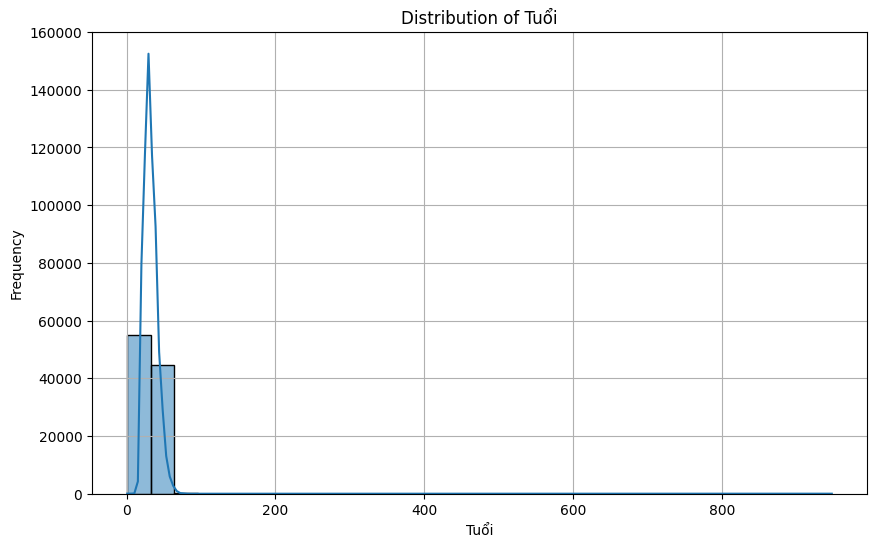

In [17]:
print('Descriptive statistics for Tuổi column:')
print(df_clean['Tuổi'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Tuổi'].dropna(), kde=True, bins=30)
plt.title('Distribution of Tuổi')
plt.xlabel('Tuổi')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Có các giá trị bất thường trong cột tuổi, do phân phối tuổi trải dài đến 800 tuổi. Bất thường về tuổi có thể do lỗi nhập liệu. Để xử lý, nhóm điền median độ tuổi vào các giá trị bất thường

In [18]:
print("Bản ghi có tuổi lớn hơn 100:")
print(df_clean[df_clean['Tuổi'] > 100])

Bản ghi có tuổi lớn hơn 100:
      giới_tính_khách_hàng tình_trạng_hôn_nhân  tỉnh_thành_sinh_sống  \
18897                  Nam          Đã kết hôn                  75.0   
39010                  NaN                 NaN                   NaN   
47634                  Nam          Đã kết hôn                  92.0   
54895                  Nam            Độc thân                  15.0   
73845                  Nam          Đã kết hôn                  56.0   

       quận_huyện_sinh_sống  phường_xã_sinh_sống  ngày_sinh  \
18897                 740.0              26389.0     1779.0   
39010                   NaN                  NaN     1905.0   
47634                 916.0              31117.0     1900.0   
54895                 135.0               4348.0     1884.0   
73845                 568.0              22363.0     1073.0   

       tổng_số_tiền_giao_dịch_trong_1_tuần  số_tiền_lớn_nhất_trong_1_tuần  \
18897                                  0.0                       0.000081   
39010

In [19]:
# Tính median cho tuổi hợp lệ (<= 95)
median_age = df_clean.loc[df_clean['Tuổi'] <= 95, 'Tuổi'].median()

# Gán giá trị tuổi > 95 thành median
df_clean.loc[df_clean['Tuổi'] > 95, 'Tuổi'] = median_age

print("Median age used for fill:", median_age)

Median age used for fill: 31.0


Kiểm tra lại số giá trị bất thường

In [20]:
num_records_age_100_plus = df_clean[df_clean['Tuổi'] >= 100].shape[0]
print(f"Số lượng bản ghi có tuổi lớn hơn hoặc bằng 100: {num_records_age_100_plus}")

Số lượng bản ghi có tuổi lớn hơn hoặc bằng 100: 0


Descriptive statistics for Tuổi column after cleaning:
count    99990.000000
mean        32.505241
std          8.982862
min          1.000000
25%         26.000000
50%         31.000000
75%         38.000000
max         91.000000
Name: Tuổi, dtype: float64


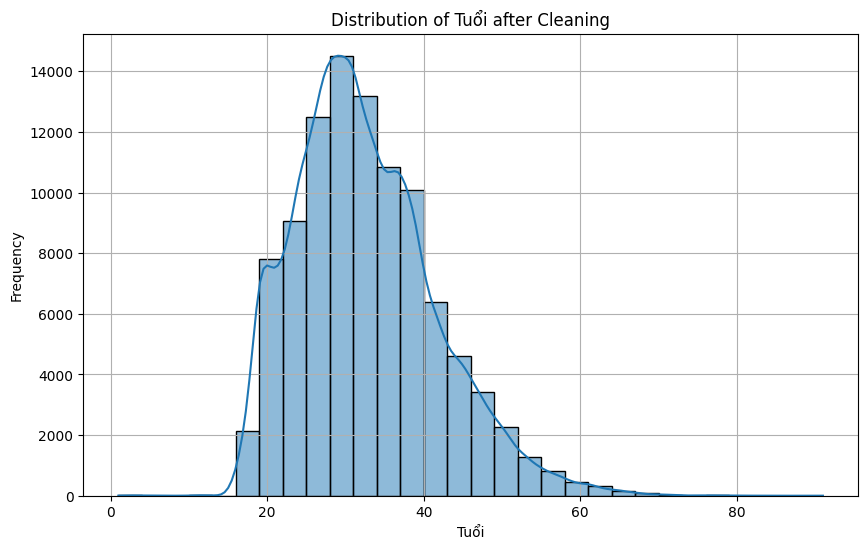

In [21]:
print('Descriptive statistics for Tuổi column after cleaning:')
print(df_clean['Tuổi'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Tuổi'].dropna(), kde=True, bins=30)
plt.title('Distribution of Tuổi after Cleaning')
plt.xlabel('Tuổi')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

###Kiểm tra bất thường trong cột hành vi giao dịch

số_lượng_đối_tác_giao_dịch

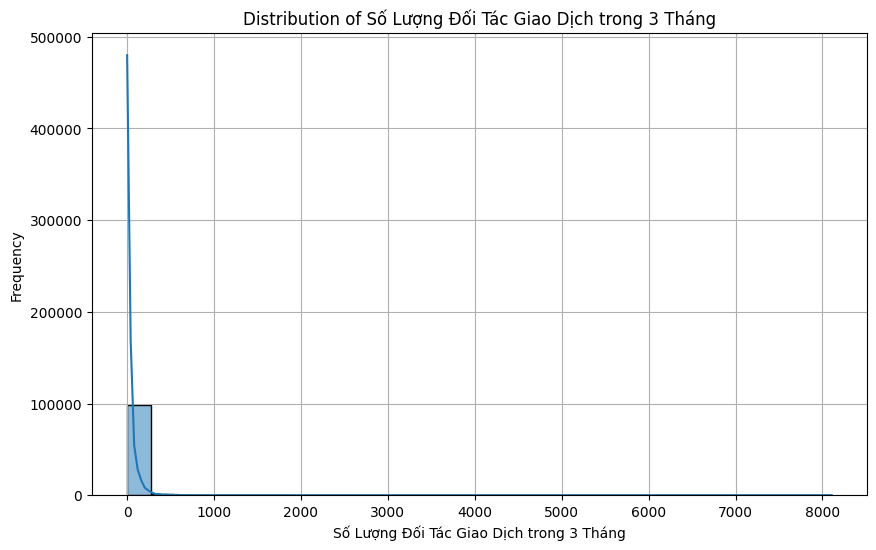

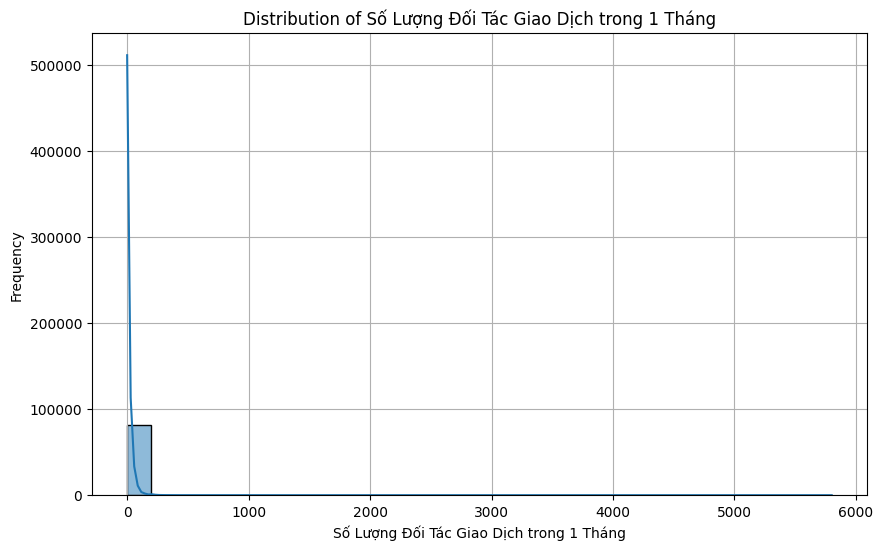

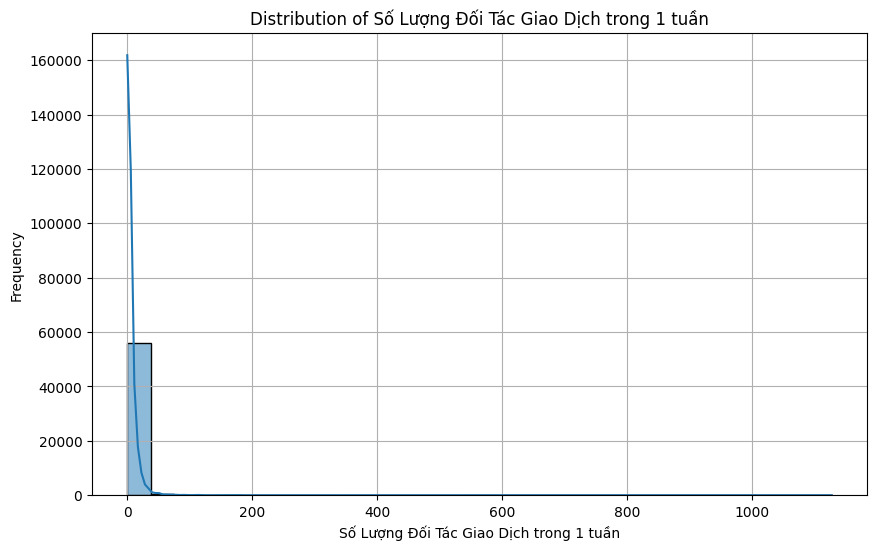

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['số_lượng_đối_tác_giao_dịch_trong_3_tháng'].dropna(), kde=True, bins=30)
plt.title('Distribution of Số Lượng Đối Tác Giao Dịch trong 3 Tháng')
plt.xlabel('Số Lượng Đối Tác Giao Dịch trong 3 Tháng')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['số_lượng_đối_tác_giao_dịch_trong_1_tháng'].dropna(), kde=True, bins=30)
plt.title('Distribution of Số Lượng Đối Tác Giao Dịch trong 1 Tháng')
plt.xlabel('Số Lượng Đối Tác Giao Dịch trong 1 Tháng')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['số_lượng_đối_tác_giao_dịch_trong_1_tuần'].dropna(), kde=True, bins=30)
plt.title('Distribution of Số Lượng Đối Tác Giao Dịch trong 1 tuần')
plt.xlabel('Số Lượng Đối Tác Giao Dịch trong 1 tuần')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [23]:
cols_to_describe_partners = [
    'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_1_tuần'
]

# Tính thống kê mô tả cho các cột được yêu cầu
summary_partners = df_clean[cols_to_describe_partners].describe()

# Hiển thị kết quả thống kê mô tả
print("Thống kê mô tả cho số lượng đối tác giao dịch:")
display(summary_partners)

Thống kê mô tả cho số lượng đối tác giao dịch:


,số_lượng_đối_tác_giao_dịch_trong_3_tháng,số_lượng_đối_tác_giao_dịch_trong_1_tháng,số_lượng_đối_tác_giao_dịch_trong_1_tuần
count,100000.00000,82223.000000,56850.000000
mean,40.06861,18.274339,6.178276
std,90.35093,41.825200,11.763902
min,0.00000,0.000000,0.000000
25%,4.00000,3.000000,1.000000
50%,17.00000,9.000000,3.000000
75%,45.00000,20.000000,7.000000
max,8106.00000,5800.000000,1128.000000


Số lần login

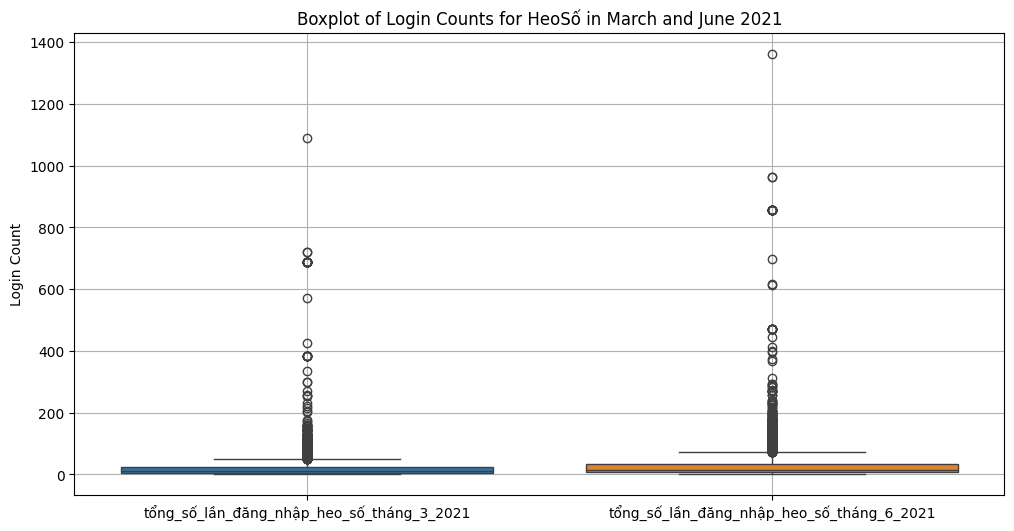

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021', 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021']])
plt.title('Boxplot of Login Counts for HeoSố in March and June 2021')
plt.ylabel('Login Count')
plt.grid(True)
plt.show()

In [25]:
mask = (
    (df_clean['số_lần_sử_dụng_dịch_vụ_trong_1_tuần'] == 0) &
    (
      (df_clean['số_tiền_lớn_nhất_trong_1_tuần'] > 0) |
      (df_clean['số_tiền_nhỏ_nhất_trong_1_tuần'] > 0) |
      (df_clean['số_loại_dịch_vụ_sử_dụng_trong_1_tuần'] > 0)
    )
)
df_clean[mask].shape

(37044, 51)

Kiểm tra các cột giao dịch

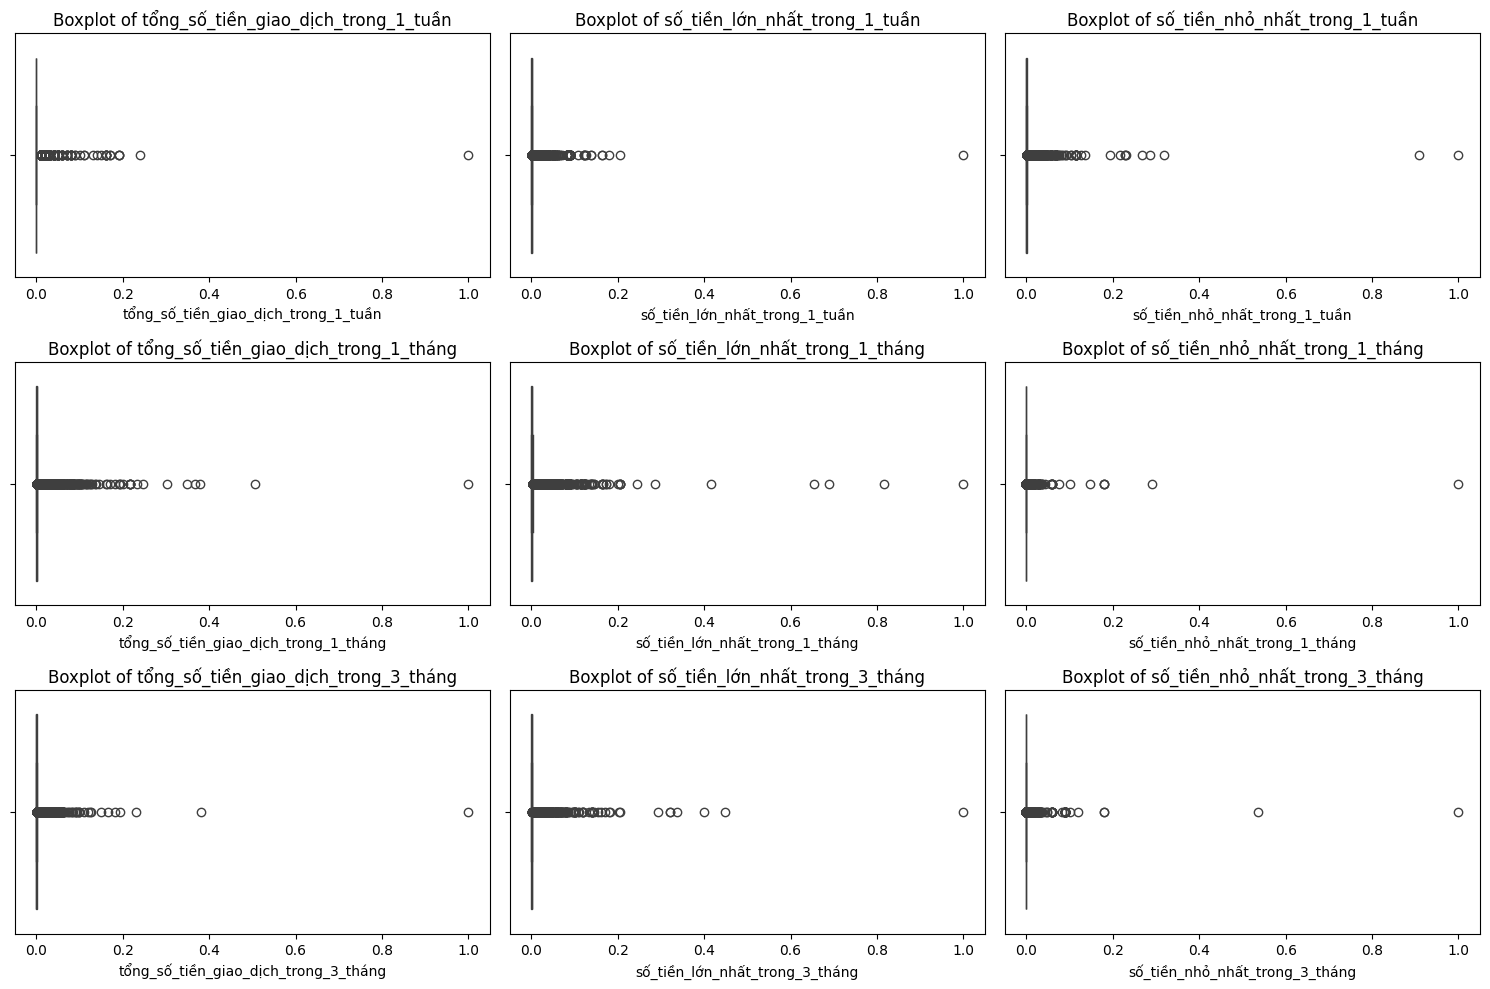

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các cột cần kiểm tra boxplot
cols_to_plot = [
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'số_tiền_lớn_nhất_trong_1_tuần',
    'số_tiền_nhỏ_nhất_trong_1_tuần',
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'số_tiền_lớn_nhất_trong_1_tháng',
    'số_tiền_nhỏ_nhất_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng',
    'số_tiền_lớn_nhất_trong_3_tháng',
    'số_tiền_nhỏ_nhất_trong_3_tháng'
]

# Vẽ boxplot cho từng cột
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


In [27]:
# Danh sách các cột cần làm thống kê mô tả
cols_to_describe = [
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'số_tiền_lớn_nhất_trong_1_tuần',
    'số_tiền_nhỏ_nhất_trong_1_tuần',
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'số_tiền_lớn_nhất_trong_1_tháng',
    'số_tiền_nhỏ_nhất_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng',
    'số_tiền_lớn_nhất_trong_3_tháng',
    'số_tiền_nhỏ_nhất_trong_3_tháng'
]

# Tính thống kê mô tả cho các cột
summary = df_clean[cols_to_describe].describe()

# Hiển thị kết quả thống kê mô tả
print("Thống kê mô tả cho các cột giao dịch:")
print(summary)

Thống kê mô tả cho các cột giao dịch:
       tổng_số_tiền_giao_dịch_trong_1_tuần  số_tiền_lớn_nhất_trong_1_tuần  \
count                          54800.00000                   5.480000e+04   
mean                               0.00059                   1.223446e-03   
std                                0.00615                   6.287416e-03   
min                                0.00000                   2.040000e-09   
25%                                0.00000                   3.060000e-05   
50%                                0.00000                   1.551020e-04   
75%                                0.00000                   7.297960e-04   
max                                1.00000                   1.000000e+00   

       số_tiền_nhỏ_nhất_trong_1_tuần  tổng_số_tiền_giao_dịch_trong_1_tháng  \
count                   54800.000000                          7.700000e+04   
mean                        0.000669                          1.238261e-03   
std                         0.0075

##Xử lí null value

###Fill theo context

Với các cột định tính, do các cột này thể hiện đặc điểm nhân khẩu của khách hàng, tức thường là những đặc điểm cổ định, do đó nhóm quyết định sẽ clean null bằng tại các cột này bằng cách chia các bản ghi khách hàng thành các nhóm thế hệ, sau đó từ từng nhóm thế hệ, fill null các đặc điểm nhân khẩu chiếm tỉ lệ cao nhất trong bộ data (>50%)

In [28]:
median_birth_year = df_clean['ngày_sinh'].median()
df_clean['ngày_sinh'].fillna(median_birth_year, inplace=True)
print(f"Số lượng giá trị null trong cột 'ngày_sinh' sau khi điền: {df_clean['ngày_sinh'].isnull().sum()}")

Số lượng giá trị null trong cột 'ngày_sinh' sau khi điền: 0


/tmp/ipython-input-600985731.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['ngày_sinh'].fillna(median_birth_year, inplace=True)


In [29]:
median_age = df_clean['Tuổi'].median()
df_clean['Tuổi'].fillna(median_age, inplace=True)
print(f"Số lượng giá trị null trong cột 'Tuổi' sau khi điền: {df_clean['Tuổi'].isnull().sum()}")

Số lượng giá trị null trong cột 'Tuổi' sau khi điền: 0


/tmp/ipython-input-470901737.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Tuổi'].fillna(median_age, inplace=True)


Tạo cột thế hệ

In [30]:
def map_generation(age):
    if age <= 8:
        return "Gen Alpha"
    elif 9 <= age <= 24:
        return "Gen Z"
    elif 25 <= age <= 40:
        return "Millennials (Gen Y)"
    elif 41 <= age <= 56:
        return "Gen X"
    elif 57 <= age <= 75:
        return "Baby Boomers"
    elif 76 <= age <= 93:
        return "Silent Generation"
    else:
        return "Greatest Generation"

df_clean['thế_hệ'] = df_clean['Tuổi'].apply(map_generation)

In [31]:
gender_by_generation = df_clean.groupby('thế_hệ')['giới_tính_khách_hàng'].value_counts(normalize=True).unstack()
print("Tỷ lệ giới tính theo từng thế hệ:")
print(gender_by_generation.fillna(0).map(lambda x: f'{x:.2%}'))

Tỷ lệ giới tính theo từng thế hệ:
giới_tính_khách_hàng     Nam      Nữ
thế_hệ                              
Baby Boomers          68.36%  31.64%
Gen Alpha             58.33%  41.67%
Gen X                 70.99%  29.01%
Gen Z                 62.03%  37.97%
Millennials (Gen Y)   65.91%  34.09%
Silent Generation     68.42%  31.58%


In [32]:
# Tái tạo gender_by_generation để đảm bảo nó là số, không phải chuỗi đã định dạng
gender_by_generation = df_clean.groupby('thế_hệ')['giới_tính_khách_hàng'].value_counts(normalize=True).unstack()

# Tạo một dictionary để lưu trữ giới tính chiếm ưu thế cho mỗi thế hệ
dominant_gender_mapping = {}
for generation, proportions in gender_by_generation.iterrows():
    if proportions.get('Nam', 0) >= 0.50:
        dominant_gender_mapping[generation] = 'Nam'
    elif proportions.get('Nữ', 0) >= 0.50:
        dominant_gender_mapping[generation] = 'Nữ'
    # Nếu không có giới tính nào chiếm ưu thế > 60%, không thêm vào mapping hoặc để giá trị mặc định là NaN

# Điền giá trị null trong cột 'giới_tính_khách_hàng' dựa trên ánh xạ
for generation, dominant_gender in dominant_gender_mapping.items():
    mask = (df_clean['thế_hệ'] == generation) & (df_clean['giới_tính_khách_hàng'].isnull())
    df_clean.loc[mask, 'giới_tính_khách_hàng'] = dominant_gender

print("Số lượng giá trị null trong cột 'giới_tính_khách_hàng' sau khi điền:")
print(df_clean['giới_tính_khách_hàng'].isnull().sum())

Số lượng giá trị null trong cột 'giới_tính_khách_hàng' sau khi điền:
0


In [33]:
# Bước 1: Kiểm tra tỉ lệ tình trạng hôn nhân của từng thế hệ
marital_status_by_generation = df_clean.groupby('thế_hệ')['tình_trạng_hôn_nhân'].value_counts(normalize=True).unstack()
print("Tỷ lệ tình trạng hôn nhân theo từng thế hệ:")
print(marital_status_by_generation.fillna(0).map(lambda x: f'{x:.2%}'))

# Bước 2: Điền các giá trị null trong cột 'tình_trạng_hôn_nhân' dựa trên giá trị có tỉ lệ cao nhất theo từng nhóm thế hệ

# Lấy giá trị mode (phổ biến nhất) của tình_trạng_hôn_nhân cho mỗi thế hệ
mode_marital_status_by_generation = df_clean.groupby('thế_hệ')['tình_trạng_hôn_nhân'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Tạo ánh xạ từ thế hệ đến tình trạng hôn nhân phổ biến nhất
marital_status_mapping = mode_marital_status_by_generation.to_dict()

# Điền giá trị null trong cột 'tình_trạng_hôn_nhân' dựa trên ánh xạ
for generation, mode_status in marital_status_mapping.items():
    mask = (df_clean['thế_hệ'] == generation) & (df_clean['tình_trạng_hôn_nhân'].isnull())
    df_clean.loc[mask, 'tình_trạng_hôn_nhân'] = mode_status

print("\nSố lượng giá trị null trong cột 'tình_trạng_hôn_nhân' sau khi điền:")
print(df_clean['tình_trạng_hôn_nhân'].isnull().sum())

Tỷ lệ tình trạng hôn nhân theo từng thế hệ:
tình_trạng_hôn_nhân    Góa   Khác Ly hôn Ly thân Sống chung Đã kết hôn  \
thế_hệ                                                                   
Baby Boomers         0.16%  0.56%  0.00%   0.00%      0.00%     77.29%   
Gen Alpha            0.00%  0.00%  0.00%   0.00%      0.00%     16.67%   
Gen X                0.01%  0.35%  0.09%   0.01%      0.06%     76.54%   
Gen Z                0.00%  0.26%  0.00%   0.00%      0.01%      4.55%   
Millennials (Gen Y)  0.01%  0.41%  0.03%   0.00%      0.05%     46.50%   
Silent Generation    0.00%  0.00%  0.00%   0.00%      0.00%     73.68%   

tình_trạng_hôn_nhân Độc thân  
thế_hệ                        
Baby Boomers          21.98%  
Gen Alpha             83.33%  
Gen X                 22.94%  
Gen Z                 95.18%  
Millennials (Gen Y)   53.00%  
Silent Generation     26.32%  

Số lượng giá trị null trong cột 'tình_trạng_hôn_nhân' sau khi điền:
0


In [34]:
# Bước 1 & 2: Tính mode của 'tỉnh_thành_sinh_sống' cho mỗi 'thế_hệ'
mode_province_by_generation = df_clean.groupby('thế_hệ')['tỉnh_thành_sinh_sống'] \
                                      .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Bước 3: Tạo ánh xạ từ thế hệ đến tỉnh thành sinh sống phổ biến nhất
province_generation_mapping = mode_province_by_generation.to_dict()

# Bước 4, 5, 6: Điền giá trị null trong cột 'tỉnh_thành_sinh_sống' dựa trên ánh xạ
for generation, mode_province in province_generation_mapping.items():
    mask = (df_clean['thế_hệ'] == generation) & (df_clean['tỉnh_thành_sinh_sống'].isnull())
    df_clean.loc[mask, 'tỉnh_thành_sinh_sống'] = mode_province

# Bước 7: Kiểm tra lại số lượng null cho cột tỉnh_thành_sinh_sống sau khi điền
print("\nSố lượng giá trị null trong cột 'tỉnh_thành_sinh_sống' sau khi điền:")
print(df_clean['tỉnh_thành_sinh_sống'].isnull().sum())


Số lượng giá trị null trong cột 'tỉnh_thành_sinh_sống' sau khi điền:
0


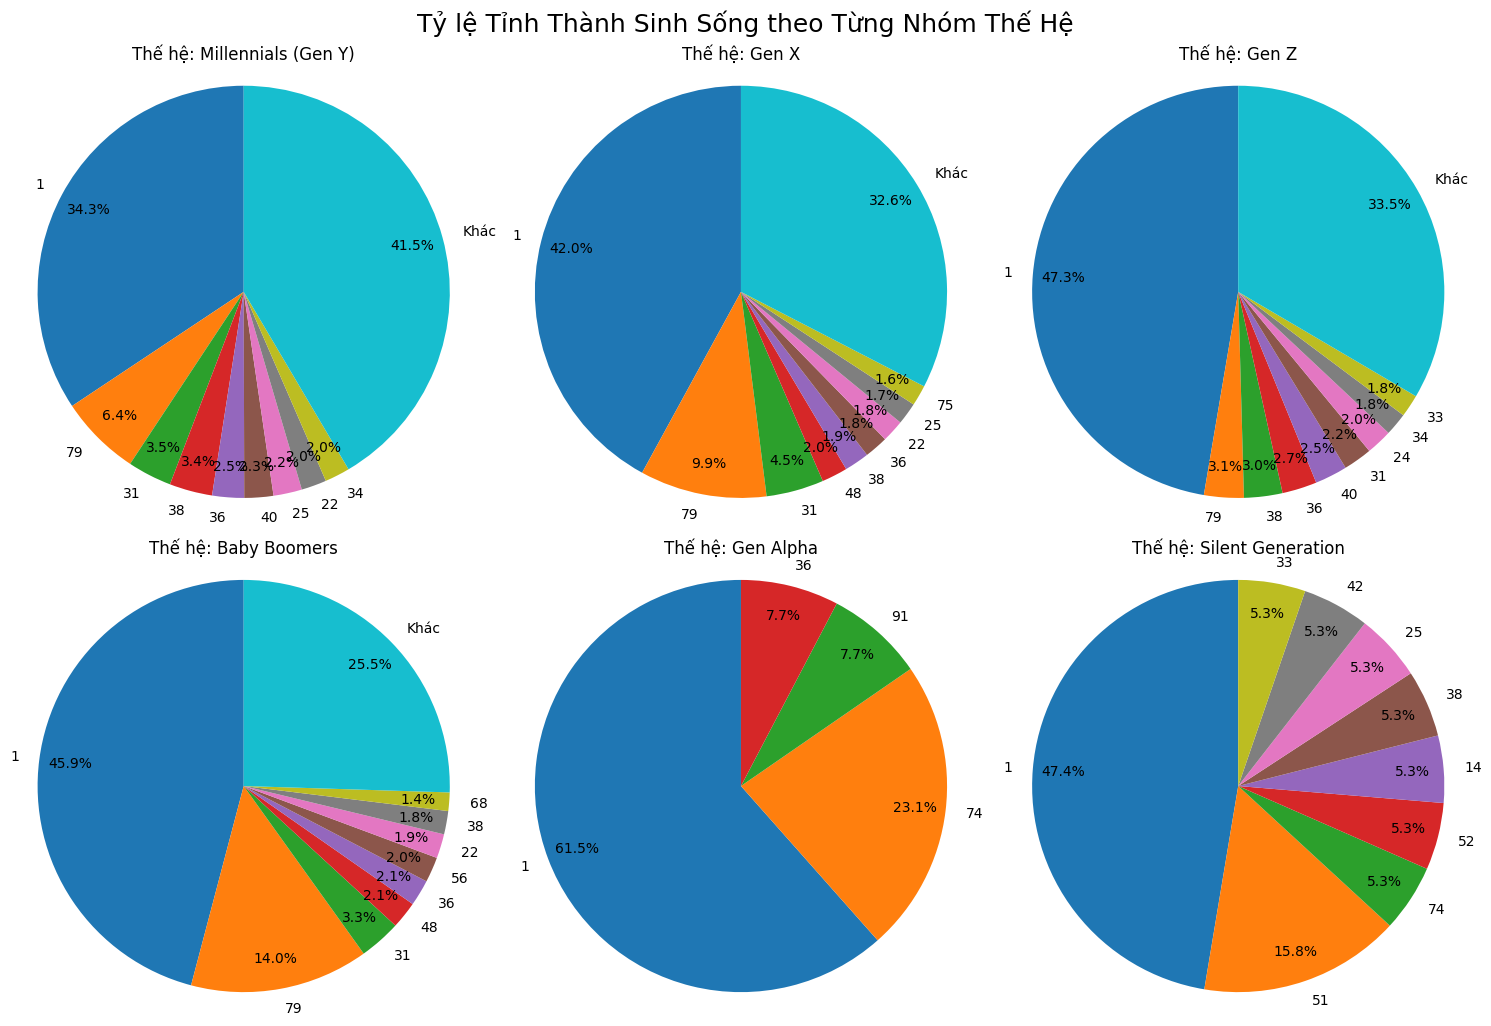

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get unique generations, dropping any potential NaN values from the 'thế_hệ' column
generations = df_clean['thế_hệ'].dropna().unique()

# Determine the number of rows and columns for subplots
num_generations = len(generations)
num_cols = 3 # Number of columns for the subplot grid
num_rows = (num_generations + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 5))

for i, gen in enumerate(generations):
    plt.subplot(num_rows, num_cols, i + 1)

    # Filter data for the current generation, dropping nulls in 'tỉnh_thành_sinh_sống'
    gen_df = df_clean[df_clean['thế_hệ'] == gen].dropna(subset=['tỉnh_thành_sinh_sống'])

    # Get value counts for 'tỉnh_thành_sinh_sống'
    province_counts = gen_df['tỉnh_thành_sinh_sống'].value_counts()

    # Group small categories into 'Other' if there are too many unique provinces
    if len(province_counts) > 10: # Limit to top 9 provinces + Other
        top_provinces = province_counts.head(9)
        other_count = province_counts.iloc[9:].sum()
        province_data = pd.concat([top_provinces, pd.Series({'Khác': other_count})])
    else:
        province_data = province_counts

    # Convert province IDs to strings for better labeling
    province_labels = [str(int(p)) if isinstance(p, (float, int)) else str(p) for p in province_data.index]

    plt.pie(province_data, labels=province_labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.title(f'Thế hệ: {gen}')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.suptitle('Tỷ lệ Tỉnh Thành Sinh Sống theo Từng Nhóm Thế Hệ', y=1.02, fontsize=18) # Add a main title
plt.show()

In [36]:
# Drop rows where either 'nhóm_sản_phẩm_tín_dụng' or 'sản_phẩm_tín_dụng' is null to ensure accurate counts
df_filtered = df_clean.dropna(subset=['nhóm_sản_phẩm_tín_dụng', 'sản_phẩm_tín_dụng'])

# Calculate the proportion of 'sản_phẩm_tín_dụng' within each 'nhóm_sản_phẩm_tín_dụng'
product_distribution = df_filtered.groupby('nhóm_sản_phẩm_tín_dụng')['sản_phẩm_tín_dụng'].value_counts(normalize=True).unstack(fill_value=0)

# Format to percentage for better readability
product_distribution_percentage = product_distribution.applymap(lambda x: f'{x:.2%}')

print("Tỷ lệ sản phẩm tín dụng theo nhóm sản phẩm tín dụng:")
print(product_distribution_percentage)

# Optionally, you can also visualize the top products within each group if there are too many
# For example, to show the top 5 products in each group:
# for group in product_distribution.index:
#     print(f"\nNhóm sản phẩm tín dụng: {group}")
#     print(product_distribution.loc[group].nlargest(5).apply(lambda x: f'{x:.2%}'))

Tỷ lệ sản phẩm tín dụng theo nhóm sản phẩm tín dụng:
sản_phẩm_tín_dụng        306.0  323.0  325.0   330.0  331.0   332.0  356.0  \
nhóm_sản_phẩm_tín_dụng                                                       
1005.0                   0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21054.0                 23.71%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21056.0                  0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21057.0                  0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21060.0                  0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21061.0                  0.00%  0.30%  0.17%   0.00%  0.00%   0.00%  0.08%   
21063.0                  0.00%  0.00%  0.00%  84.02%  1.59%  14.40%  0.00%   
21064.0                  0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   
21071.0                  0.00%  0.00%  0.00%   0.00%  0.00%   0.00%  0.00%   

sản_phẩm_tín_dụng        360.0  362.0   363.0  ...  461.0   462.0  463.0  \
nhóm_sản_phẩ

/tmp/ipython-input-3195308041.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  product_distribution_percentage = product_distribution.applymap(lambda x: f'{x:.2%}')


In [37]:
cols_trans_check = [
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'số_tiền_lớn_nhất_trong_1_tuần',
    'số_tiền_nhỏ_nhất_trong_1_tuần',
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'số_tiền_lớn_nhất_trong_1_tháng',
    'số_tiền_nhỏ_nhất_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng',
    'số_tiền_lớn_nhất_trong_3_tháng',
    'số_tiền_nhỏ_nhất_trong_3_tháng'
]

count_non_null_rows = df_clean[cols_trans_check].notnull().all(axis=1).sum()

print("Số dòng mà TẤT CẢ 9 cột giao dịch KHÔNG NULL:", count_non_null_rows)

Số dòng mà TẤT CẢ 9 cột giao dịch KHÔNG NULL: 54800


Không thể clean bằng nội suy từ

In [38]:
num_duplicate_customer_ids = df_clean['mã_khách_hàng'].duplicated().sum()
print(f"Số lượng mã khách hàng trùng lặp: {num_duplicate_customer_ids}")

Số lượng mã khách hàng trùng lặp: 0


Clean theo demographic của khách hàng

In [39]:
mask_inconsistent = df_clean['tỉnh_thành_sinh_sống'].isnull() & df_clean['quận_huyện_sinh_sống'].notnull()
inconsistent_rows = df_clean[mask_inconsistent]

print("Các dòng có 'tỉnh_thành_sinh_sống' là null nhưng 'quận_huyện_sinh_sống' không null:")
print(inconsistent_rows[['tỉnh_thành_sinh_sống', 'quận_huyện_sinh_sống']].head())

Các dòng có 'tỉnh_thành_sinh_sống' là null nhưng 'quận_huyện_sinh_sống' không null:
Empty DataFrame
Columns: [tỉnh_thành_sinh_sống, quận_huyện_sinh_sống]
Index: []


In [40]:
mask_inconsistent = df_clean['tỉnh_thành_sinh_sống'].isnull() & df_clean['quận_huyện_sinh_sống'].notnull()
num_inconsistent_rows = df_clean[mask_inconsistent].shape[0]
print(f"Tổng số lượng dòng có 'tỉnh_thành_sinh_sống' là null nhưng 'quận_huyện_sinh_sống' không null: {num_inconsistent_rows}")

Tổng số lượng dòng có 'tỉnh_thành_sinh_sống' là null nhưng 'quận_huyện_sinh_sống' không null: 0


In [41]:
mask_both_null = df_clean['tỉnh_thành_sinh_sống'].isnull() & df_clean['quận_huyện_sinh_sống'].isnull()
num_both_null_rows = df_clean[mask_both_null].shape[0]
print(f"Tổng số lượng dòng có 'tỉnh_thành_sinh_sống' và 'quận_huyện_sinh_sống' đều null: {num_both_null_rows}")

Tổng số lượng dòng có 'tỉnh_thành_sinh_sống' và 'quận_huyện_sinh_sống' đều null: 0


In [42]:
# Bước 1: Tạo ánh xạ từ quận_huyện_sinh_sống đến tỉnh_thành_sinh_sống
# Sử dụng mode để lấy giá trị tỉnh_thành_sinh_sống phổ biến nhất cho mỗi quận_huyện_sinh_sống
province_district_mapping = df_clean.dropna(subset=['tỉnh_thành_sinh_sống', 'quận_huyện_sinh_sống']) \
                                     .groupby('quận_huyện_sinh_sống')['tỉnh_thành_sinh_sống'] \
                                     .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan) \
                                     .to_dict()

print(f"Số lượng cặp quận-huyện -> tỉnh-thành trong mapping: {len(province_district_mapping)}")


Số lượng cặp quận-huyện -> tỉnh-thành trong mapping: 704


In [43]:
# Bước 2: Điền giá trị null cho tỉnh_thành_sinh_sống dựa trên ánh xạ và điều kiện
# Xác định các dòng cần điền: tỉnh_thành_sinh_sống là null nhưng quận_huyện_sinh_sống không null
mask_to_fill = df_clean['tỉnh_thành_sinh_sống'].isnull() & df_clean['quận_huyện_sinh_sống'].notnull()

# Áp dụng ánh xạ để điền giá trị
df_clean.loc[mask_to_fill, 'tỉnh_thành_sinh_sống'] = df_clean.loc[mask_to_fill, 'quận_huyện_sinh_sống']\
                                                               .map(province_district_mapping)

print("Đã điền giá trị null cho 'tỉnh_thành_sinh_sống' dựa trên 'quận_huyện_sinh_sống' cho các dòng phù hợp.")

# Kiểm tra lại số lượng null cho cột tỉnh_thành_sinh_sống sau khi điền
print(f"\nSố lượng giá trị null của 'tỉnh_thành_sinh_sống' sau khi xử lý: {df_clean['tỉnh_thành_sinh_sống'].isnull().sum()}")


Đã điền giá trị null cho 'tỉnh_thành_sinh_sống' dựa trên 'quận_huyện_sinh_sống' cho các dòng phù hợp.

Số lượng giá trị null của 'tỉnh_thành_sinh_sống' sau khi xử lý: 0


###Kiểm tra giao dịch

Kiểm tra số bản ghi đăng nhập heo số tháng 3 null nhưng tháng 6 không null và tháng 3 > tháng 6 phát hiện không có bản ghi nào. Điều này chứng tỏ logic ghi nhận số lần đăng nhập tháng 6 vào heo số đã tính cả số lần đăng nhập của tháng 3. Ví dụ tháng 3 đăng nhập 1 lần và tháng 6 đăng nhập 5 lần, nghĩa là trong 3 tháng khách hàng đã đăng nhập thêm 4 lần.

In [44]:
cond_mar_notnull_jun_null = (
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'].notnull() &
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'].isnull()
)

count_mar_notnull_jun_null = cond_mar_notnull_jun_null.sum()

print("Số bản ghi TH3 không null nhưng TH6 null:", count_mar_notnull_jun_null)

cond_both_notnull = (
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'].notnull() &
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'].notnull()
)

cond_mar_gt_jun = (
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'] >
    df_clean['tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021']
)

count_mar_gt_jun = (cond_both_notnull & cond_mar_gt_jun).sum()

print("Số bản ghi login TH3 > login TH6:", count_mar_gt_jun)

Số bản ghi TH3 không null nhưng TH6 null: 0
Số bản ghi login TH3 > login TH6: 0


In [45]:
cols_month = [
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'số_tiền_lớn_nhất_trong_1_tháng',
    'số_tiền_nhỏ_nhất_trong_1_tháng'
]

# Thống kê mô tả
summary_month = df_clean[cols_month].describe()

print("📌 Thống kê mô tả cho các cột giao dịch trong 1 tuần:")
print(summary_month)


📌 Thống kê mô tả cho các cột giao dịch trong 1 tuần:
       tổng_số_tiền_giao_dịch_trong_1_tháng  số_tiền_lớn_nhất_trong_1_tháng  \
count                          7.700000e+04                    7.700000e+04   
mean                           1.238261e-03                    1.974828e-03   
std                            7.281018e-03                    8.754136e-03   
min                            2.800000e-10                    2.040000e-09   
25%                            2.400000e-05                    8.160000e-05   
50%                            1.017675e-04                    3.040205e-04   
75%                            5.404727e-04                    1.224490e-03   
max                            1.000000e+00                    1.000000e+00   

       số_tiền_nhỏ_nhất_trong_1_tháng  
count                    77000.000000  
mean                         0.000121  
std                          0.004095  
min                          0.000000  
25%                          0.0000

In [46]:
cols_week = [
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'số_tiền_lớn_nhất_trong_1_tuần',
    'số_tiền_nhỏ_nhất_trong_1_tuần'
]

# Thống kê mô tả
summary_week = df_clean[cols_week].describe()

print("📌 Thống kê mô tả cho các cột giao dịch trong 1 tuần:")
print(summary_week)

📌 Thống kê mô tả cho các cột giao dịch trong 1 tuần:
       tổng_số_tiền_giao_dịch_trong_1_tuần  số_tiền_lớn_nhất_trong_1_tuần  \
count                          54800.00000                   5.480000e+04   
mean                               0.00059                   1.223446e-03   
std                                0.00615                   6.287416e-03   
min                                0.00000                   2.040000e-09   
25%                                0.00000                   3.060000e-05   
50%                                0.00000                   1.551020e-04   
75%                                0.00000                   7.297960e-04   
max                                1.00000                   1.000000e+00   

       số_tiền_nhỏ_nhất_trong_1_tuần  
count                   54800.000000  
mean                        0.000669  
std                         0.007529  
min                         0.000000  
25%                         0.000011  
50%                

###Các giao dịch theo thời gian

In [47]:
# 1. Copy và rename
df_clean = df_clean.rename(columns=rename_dict)

# 2. Lọc cột định lượng SAU KHI rename
quantitative_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# 3. Fill null = 0 cho cột định lượng
df_clean[quantitative_cols] = df_clean[quantitative_cols].fillna(0)

# 5. Check
df_clean.isnull().sum()

,0
giới_tính_khách_hàng,0
tình_trạng_hôn_nhân,0
tỉnh_thành_sinh_sống,0
quận_huyện_sinh_sống,0
phường_xã_sinh_sống,0
ngày_sinh,0
tổng_số_tiền_giao_dịch_trong_1_tuần,0
số_tiền_lớn_nhất_trong_1_tuần,0
số_tiền_nhỏ_nhất_trong_1_tuần,0
số_loại_dịch_vụ_sử_dụng_trong_1_tuần,0


##Bỏ cột không cần thiết

Các cột có tính id sẽ bị loại khỏi phần phân tích do không thể khai thác được insight

In [48]:
df_clean = df_clean.drop(columns=['mã_khách_hàng', 'quận_huyện_sinh_sống', 'phường_xã_sinh_sống', 'nhóm_nợ_tại_ngân_hàng', 'nhóm_sản_phẩm_tín_dụng', 'sản_phẩm_tín_dụng',
                'ngành_nghề_kinh_doanh', 'mã_sản_phẩm_vay'])

In [49]:
cols_to_drop_final = ['Tuổi', 'ngày_sinh', ]

df_clean = df_clean.drop(columns=cols_to_drop_final)

print(df_clean.columns)

Index(['giới_tính_khách_hàng', 'tình_trạng_hôn_nhân', 'tỉnh_thành_sinh_sống',
       'tổng_số_tiền_giao_dịch_trong_1_tuần', 'số_tiền_lớn_nhất_trong_1_tuần',
       'số_tiền_nhỏ_nhất_trong_1_tuần', 'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tuần', 'số_nhóm_giao_dịch_trong_1_tuần',
       'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
       'tổng_số_tiền_giao_dịch_trong_1_tháng',
       'số_tiền_lớn_nhất_trong_1_tháng', 'số_tiền_nhỏ_nhất_trong_1_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
       'số_nhóm_giao_dịch_trong_1_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
       'tổng_số_tiền_giao_dịch_trong_3_tháng',
       'số_tiền_lớn_nhất_trong_3_tháng', 'số_tiền_nhỏ_nhất_trong_3_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
       'số_nhóm_giao_dịch_trong_3_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
       'số_lư

In [50]:
print(df_clean.isnull().sum())

giới_tính_khách_hàng                                      0
tình_trạng_hôn_nhân                                       0
tỉnh_thành_sinh_sống                                      0
tổng_số_tiền_giao_dịch_trong_1_tuần                       0
số_tiền_lớn_nhất_trong_1_tuần                             0
số_tiền_nhỏ_nhất_trong_1_tuần                             0
số_loại_dịch_vụ_sử_dụng_trong_1_tuần                      0
số_lần_sử_dụng_dịch_vụ_trong_1_tuần                       0
số_nhóm_giao_dịch_trong_1_tuần                            0
số_lượng_đối_tác_giao_dịch_trong_1_tuần                   0
tổng_số_tiền_giao_dịch_trong_1_tháng                      0
số_tiền_lớn_nhất_trong_1_tháng                            0
số_tiền_nhỏ_nhất_trong_1_tháng                            0
số_loại_dịch_vụ_sử_dụng_trong_1_tháng                     0
số_lần_sử_dụng_dịch_vụ_trong_1_tháng                      0
số_nhóm_giao_dịch_trong_1_tháng                           0
số_lượng_đối_tác_giao_dịch_trong_1_tháng

In [51]:
df_clean.shape

(100000, 42)

In [52]:
df_clean['tình_trạng_hôn_nhân'].unique()

array(['Đã kết hôn', 'Độc thân', 'Khác', 'Sống chung', 'Ly thân',
       'Ly hôn', 'Góa'], dtype=object)

#EDA

##Phân tích tổng quan vấn đề

In [53]:
df_eda_total = df_clean.copy()

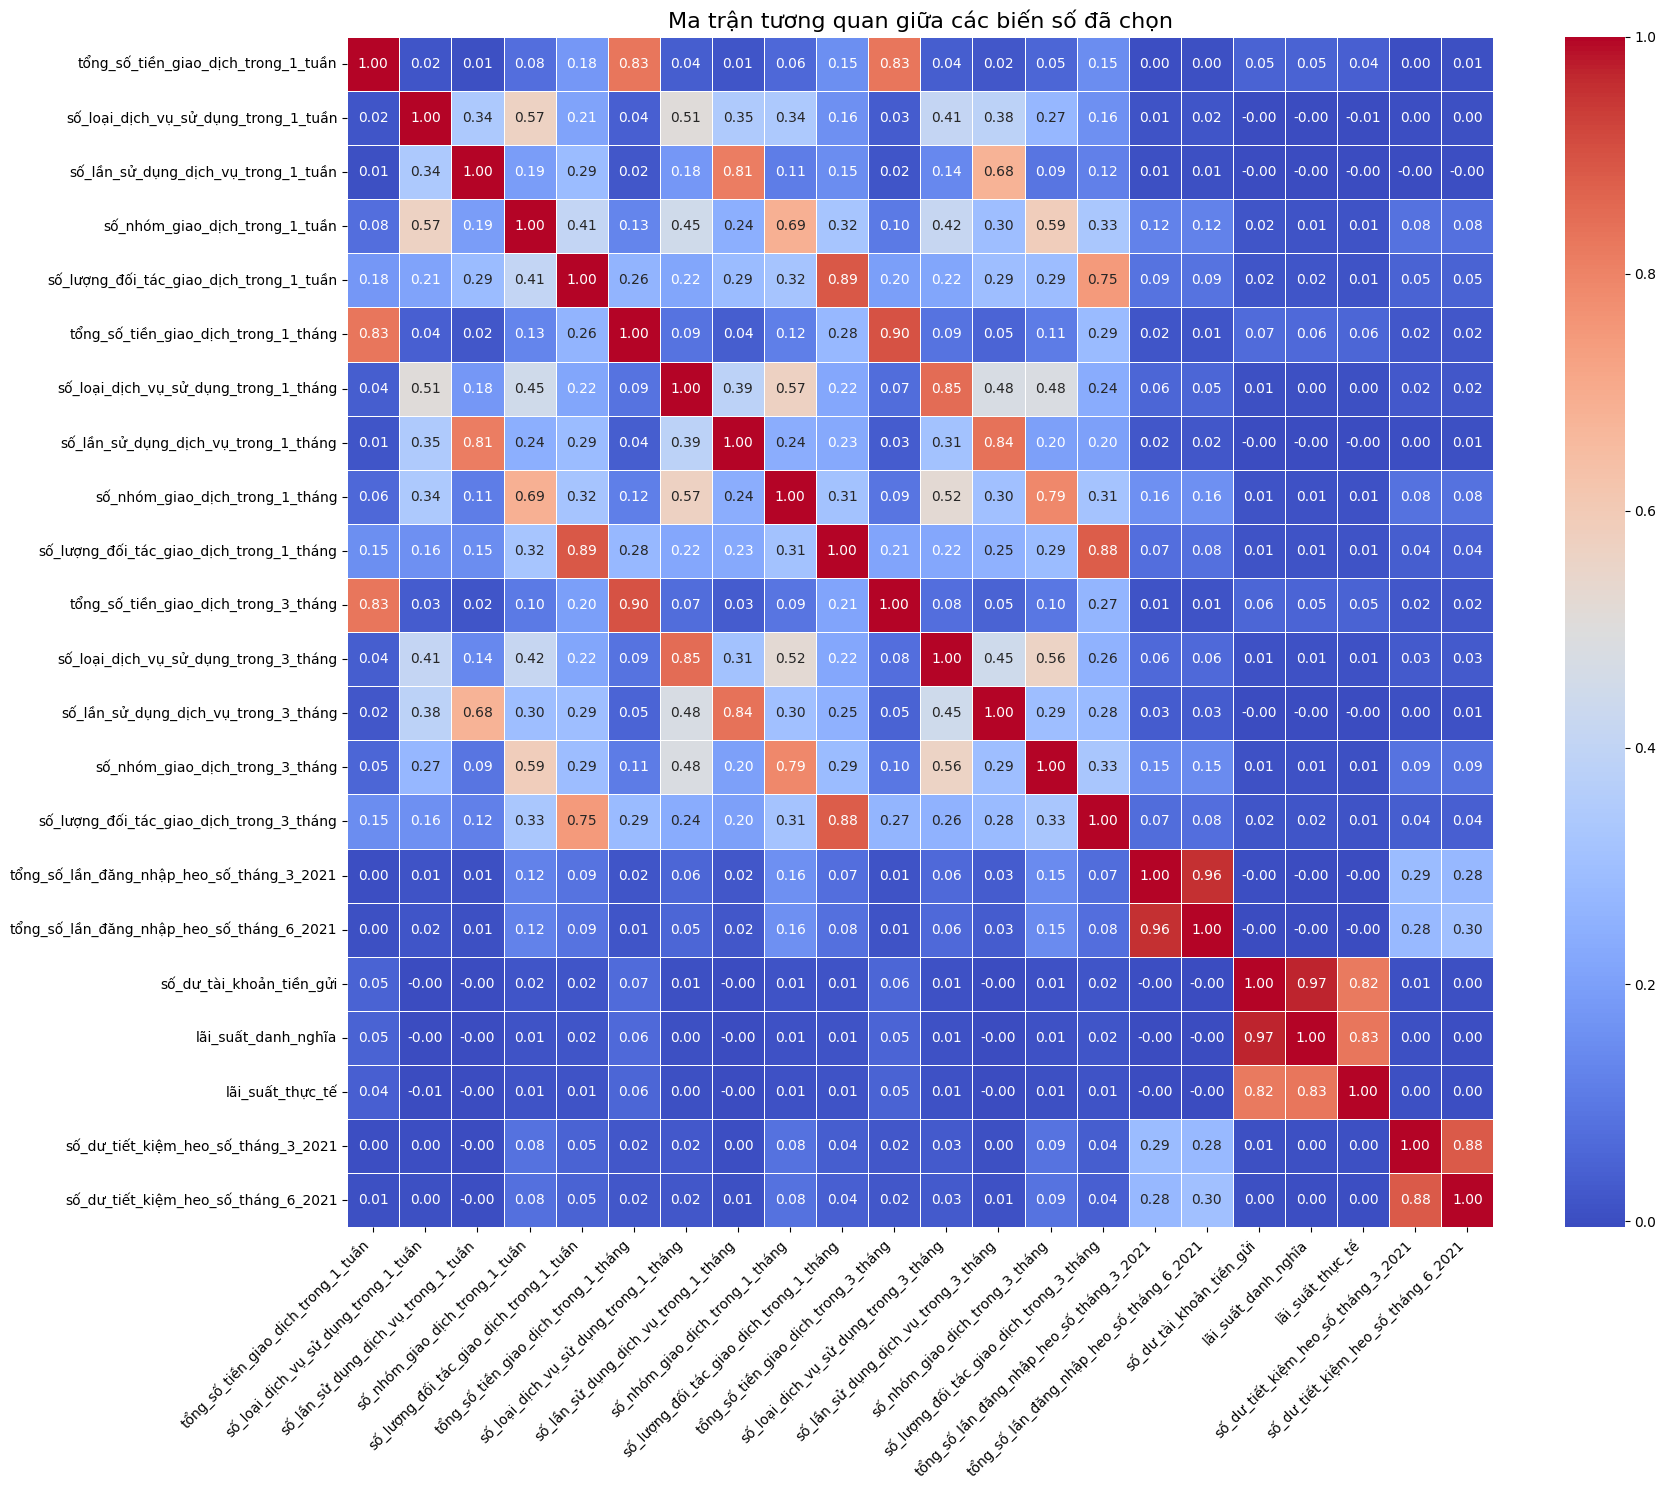

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset of relevant numerical columns for the correlation matrix
# You can add or remove columns based on your analysis needs
selected_numerical_cols = [
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần',
    'số_nhóm_giao_dịch_trong_1_tuần',
    'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
    'số_nhóm_giao_dịch_trong_1_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng',
    'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
    'số_nhóm_giao_dịch_trong_3_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    'số_dư_tài_khoản_tiền_gửi',
    'lãi_suất_danh_nghĩa',
    'lãi_suất_thực_tế',
    'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021'
]

# Filter df_model to only include the selected numerical columns
df_corr = df_eda_total[selected_numerical_cols]

# Calculate the correlation matrix using df_corr (which contains only numerical columns)
correlation_matrix = df_corr.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan giữa các biến số đã chọn', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

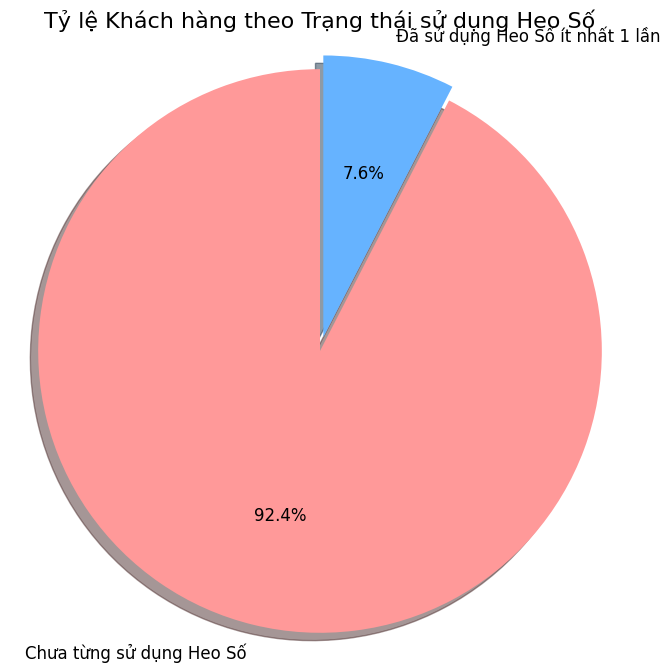

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_eda_total is available and represents the full dataset
# (from the 'EDA' section, it's a copy of df_clean before active user filtering)

# Define the condition for 'never used Heo Số'
never_used_condition = (
    (df_eda_total['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'] == 0) &
    (df_eda_total['tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'] == 0)
)

# Calculate counts for each group
count_never_used = df_eda_total[never_used_condition].shape[0]
count_at_least_once = df_eda_total[~never_used_condition].shape[0]

# Create a Series for the pie chart
data = pd.Series({
    'Chưa từng sử dụng Heo Số': count_never_used,
    'Đã sử dụng Heo Số ít nhất 1 lần': count_at_least_once
})

# Plot the pie chart
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff'] # Custom colors
explode = (0.05, 0) # Explode the 'never used' slice for emphasis

plt.pie(data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Tỷ lệ Khách hàng theo Trạng thái sử dụng Heo Số', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


92,4% khách hàng chưa từng sử dụng Heo Số

Chỉ 7,6% khách hàng đã từng dùng Heo Số (ít nhất 1 lần)

👉 Điều này cho thấy:

Heo Số chưa phải sản phẩm đại trà

##Nhóm khách hàng từng sử dụng heo số ít nhất 1 lần

Để phân tích sâu hơn về đề bài, nhóm xóa các bản ghi có tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021 = tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021 = 0, nghĩa là khách hàng chưa từng sử dụng heo số. Nhóm tập trung vào nhóm khách hàng đã sử dụng heo số ít nhất 1 lần

In [56]:
df_eda_active = df_eda_total.copy()

In [57]:
# Define the columns of interest
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

# Drop rows where BOTH columns equal 0
df_eda_active = df_eda_active[
    ~((df_eda_active[col_m3] == 0) & (df_eda_active[col_m6] == 0))
]

print("Số lượng bản ghi sau khi xóa các dòng có cả hai cột login = 0:", df_eda_active.shape[0])
print("Số lượng giá trị = 0 trong các cột login sau khi xử lý:")
print((df_eda_active[[col_m3, col_m6]] == 0).sum())

Số lượng bản ghi sau khi xóa các dòng có cả hai cột login = 0: 7571
Số lượng giá trị = 0 trong các cột login sau khi xử lý:
tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021    256
tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021      0
dtype: int64


In [58]:
print(df_eda_active.isnull().sum())

giới_tính_khách_hàng                                     0
tình_trạng_hôn_nhân                                      0
tỉnh_thành_sinh_sống                                     0
tổng_số_tiền_giao_dịch_trong_1_tuần                      0
số_tiền_lớn_nhất_trong_1_tuần                            0
số_tiền_nhỏ_nhất_trong_1_tuần                            0
số_loại_dịch_vụ_sử_dụng_trong_1_tuần                     0
số_lần_sử_dụng_dịch_vụ_trong_1_tuần                      0
số_nhóm_giao_dịch_trong_1_tuần                           0
số_lượng_đối_tác_giao_dịch_trong_1_tuần                  0
tổng_số_tiền_giao_dịch_trong_1_tháng                     0
số_tiền_lớn_nhất_trong_1_tháng                           0
số_tiền_nhỏ_nhất_trong_1_tháng                           0
số_loại_dịch_vụ_sử_dụng_trong_1_tháng                    0
số_lần_sử_dụng_dịch_vụ_trong_1_tháng                     0
số_nhóm_giao_dịch_trong_1_tháng                          0
số_lượng_đối_tác_giao_dịch_trong_1_tháng                

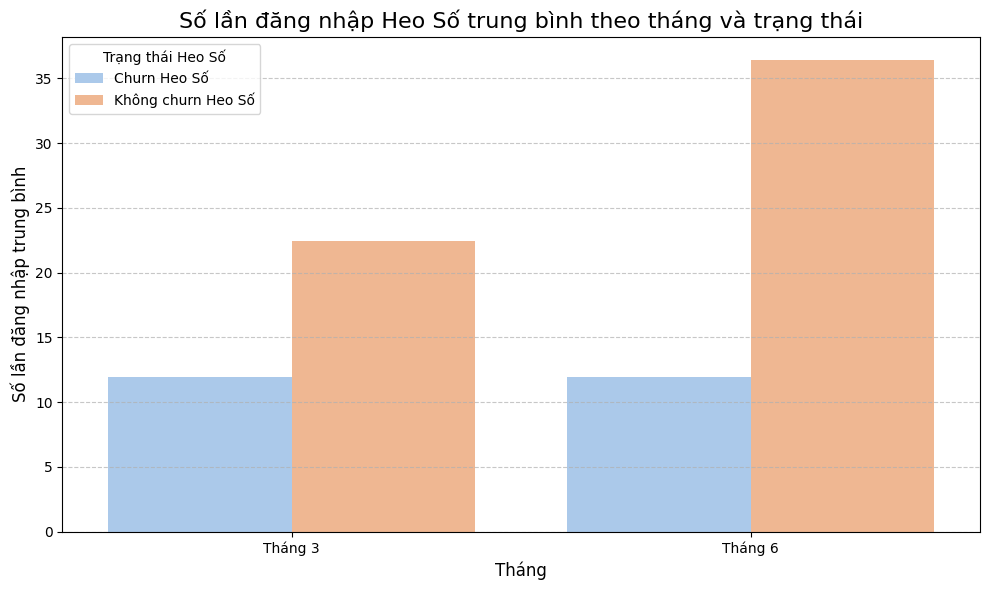

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_eda_active is up-to-date with the churn status
# This re-initialization ensures this cell can run independently if needed
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_total.copy()
df_eda_active = df_eda_active[~((df_eda_active[col_m3] == 0) & (df_eda_active[col_m6] == 0))].copy()

df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the login count columns to analyze
login_cols = [
    'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'
]

# Calculate the average login counts for each churn group
average_logins = df_compare.groupby('dùng_heo_số_label')[login_cols].mean()

# Prepare data for plotting by melting it to a long format
plot_df_logins = average_logins.stack().reset_index()
plot_df_logins.columns = ['Trạng thái Heo Số', 'Tháng', 'Số lần đăng nhập trung bình']

# Map Tháng labels for better readability
month_mapping = {
    'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021': 'Tháng 3',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021': 'Tháng 6'
}
plot_df_logins['Tháng'] = plot_df_logins['Tháng'].map(month_mapping)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Tháng',
    y='Số lần đăng nhập trung bình',
    hue='Trạng thái Heo Số',
    data=plot_df_logins,
    palette='pastel'
)

plt.title('Số lần đăng nhập Heo Số trung bình theo tháng và trạng thái', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số lần đăng nhập trung bình', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
# Initialize 'dùng_heo_số' with NaN
df_eda_active['dùng_heo_số'] = np.nan

# Define the columns of interest
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

# Mask: cả hai cột đều không null
not_null_mask = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()

# Churn = 1:
# login tháng 3 == tháng 6 và cả hai > 0
churn_condition = (
    (df_eda_active[col_m3] == df_eda_active[col_m6]) &
    (df_eda_active[col_m3] > 0) &
    (df_eda_active[col_m6] > 0) &
    not_null_mask
)
df_eda_active.loc[churn_condition, 'dùng_heo_số'] = 1

# Không churn = 0:
# login tháng 3 < tháng 6 và tháng 3 >= 0
non_churn_condition = (
    (df_eda_active[col_m3] < df_eda_active[col_m6]) &
    (df_eda_active[col_m3] >= 0) &
    not_null_mask
)
df_eda_active.loc[non_churn_condition, 'dùng_heo_số'] = 0

print("Đã tạo cột 'dùng_heo_số' theo logic churn yêu cầu.")
print(
    df_eda_active[
        [col_m3, col_m6, 'dùng_heo_số']
    ].head()
)


Đã tạo cột 'dùng_heo_số' theo logic churn yêu cầu.
     tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021  \
491                                       11.0   
677                                        3.0   
774                                       10.0   
842                                        0.0   
993                                       14.0   

     tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021  dùng_heo_số  
491                                       11.0          1.0  
677                                        7.0          0.0  
774                                       10.0          1.0  
842                                        1.0          0.0  
993                                       15.0          0.0  


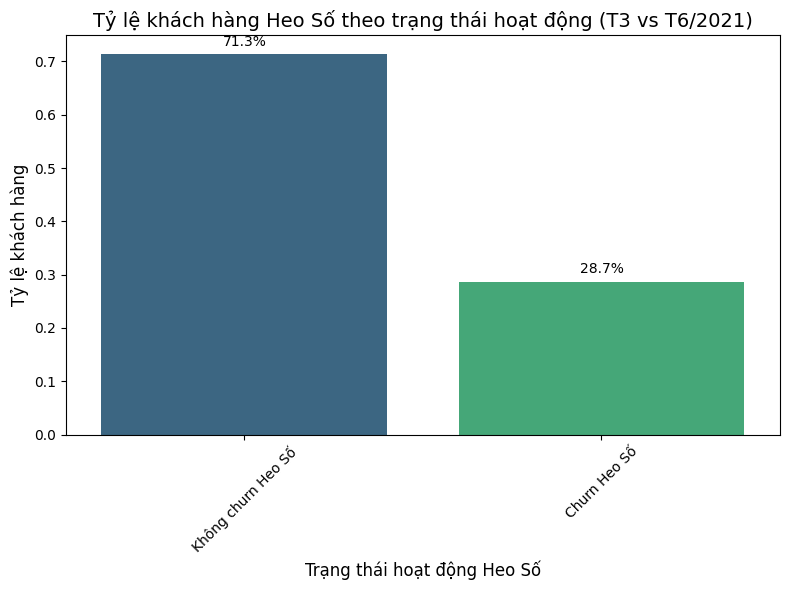

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values from 'dùng_heo_số' before calculating proportions
df_active_users = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Calculate the proportion of each category
churn_proportions = df_active_users['dùng_heo_số'].value_counts(normalize=True).sort_index()

# Map the numerical values to more descriptive labels
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
churn_proportions.index = churn_proportions.index.map(churn_labels)

plt.figure(figsize=(8, 6))
sns.barplot(x=churn_proportions.index, y=churn_proportions.values, hue=churn_proportions.index, palette='viridis', legend=False)

plt.title('Tỷ lệ khách hàng Heo Số theo trạng thái hoạt động (T3 vs T6/2021)', fontsize=14)
plt.xlabel('Trạng thái hoạt động Heo Số', fontsize=12)
plt.ylabel('Tỷ lệ khách hàng', fontsize=12)
plt.yticks(rotation=0)
plt.tick_params(axis='x', rotation=45)

# Add percentage labels on top of the bars
for index, value in enumerate(churn_proportions.values):
    plt.text(index, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipython-input-551614030.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


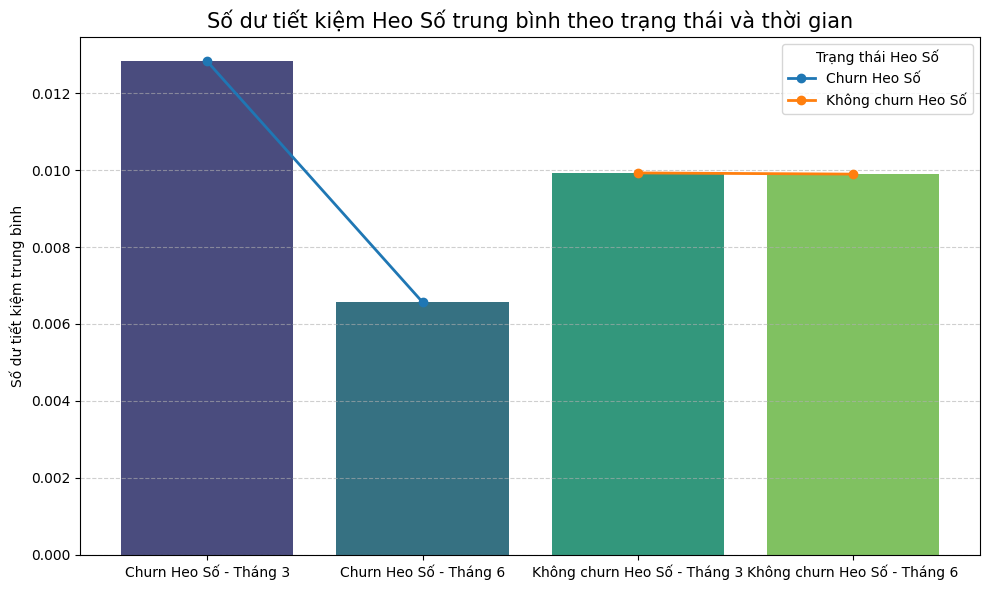

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================
# 1. Chuẩn bị dữ liệu
# =========================

# Map nhãn churn
churn_labels = {
    1: 'Churn Heo Số',
    0: 'Không churn Heo Số'
}

df_compare['churn_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Các cột số dư
saving_cols = [
    'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021'
]

# Tính trung bình theo churn
avg_savings = (
    df_compare
    .groupby('churn_label')[saving_cols]
    .mean()
    .reset_index()
)

# Đưa về long format
plot_df = avg_savings.melt(
    id_vars='churn_label',
    var_name='Tháng',
    value_name='Số dư tiết kiệm trung bình'
)

# Map tên tháng
month_mapping = {
    'số_dư_tiết_kiệm_heo_số_tháng_3_2021': 'Tháng 3',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021': 'Tháng 6'
}
plot_df['Tháng'] = plot_df['Tháng'].map(month_mapping)

# Tạo trục X có thứ tự mong muốn
plot_df['X'] = plot_df.apply(
    lambda x: f"{x['churn_label']} - {x['Tháng']}", axis=1
)

x_order = [
    'Churn Heo Số - Tháng 3',
    'Churn Heo Số - Tháng 6',
    'Không churn Heo Số - Tháng 3',
    'Không churn Heo Số - Tháng 6'
]

# =========================
# 2. Vẽ biểu đồ
# =========================

plt.figure(figsize=(10, 6))

# Bar plot
sns.barplot(
    data=plot_df,
    x='X',
    y='Số dư tiết kiệm trung bình',
    order=x_order,
    palette='viridis'
)

# Line plot (kết nối theo từng nhóm)
for label in plot_df['churn_label'].unique():
    subset = plot_df[plot_df['churn_label'] == label]
    plt.plot(
        subset['X'],
        subset['Số dư tiết kiệm trung bình'],
        marker='o',
        linewidth=2,
        label=label
    )

# =========================
# 3. Trang trí biểu đồ
# =========================

plt.title('Số dư tiết kiệm Heo Số trung bình theo trạng thái và thời gian', fontsize=15)
plt.xlabel('')
plt.ylabel('Số dư tiết kiệm trung bình')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Trạng thái Heo Số')
plt.tight_layout()
plt.show()


##Nhân khẩu học

In [63]:
df_eda_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7571 entries, 491 to 99999
Data columns (total 43 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   giới_tính_khách_hàng                                7571 non-null   object 
 1   tình_trạng_hôn_nhân                                 7571 non-null   object 
 2   tỉnh_thành_sinh_sống                                7571 non-null   float64
 3   tổng_số_tiền_giao_dịch_trong_1_tuần                 7571 non-null   float64
 4   số_tiền_lớn_nhất_trong_1_tuần                       7571 non-null   float64
 5   số_tiền_nhỏ_nhất_trong_1_tuần                       7571 non-null   float64
 6   số_loại_dịch_vụ_sử_dụng_trong_1_tuần                7571 non-null   float64
 7   số_lần_sử_dụng_dịch_vụ_trong_1_tuần                 7571 non-null   float64
 8   số_nhóm_giao_dịch_trong_1_tuần                      7571 non-null   float64
 9  

In [64]:
# MAP PROVINCE CODE → CITY (theo mã CCCD)
province_map = {
    1: "Hà Nội",
    2: "Hà Giang",
    4: "Cao Bằng",
    6: "Bắc Kạn",
    8: "Tuyên Quang",
    10: "Lào Cai",
    11: "Điện Biên",
    12: "Lai Châu",
    14: "Sơn La",
    15: "Yên Bái",
    17: "Hòa Bình",
    19: "Thái Nguyên",
    20: "Lạng Sơn",
    22: "Quảng Ninh",
    24: "Bắc Giang",
    25: "Phú Thọ",
    26: "Vĩnh Phúc",
    27: "Bắc Ninh",
    30: "Hải Dương",
    31: "Hải Phòng",
    33: "Hưng Yên",
    34: "Thái Bình",
    35: "Hà Nam",
    36: "Nam Định",
    37: "Ninh Bình",
    38: "Thanh Hóa",
    40: "Nghệ An",
    42: "Hà Tĩnh",
    44: "Quảng Bình",
    45: "Quảng Trị",
    46: "Thừa Thiên Huế",
    48: "Đà Nẵng",
    49: "Quảng Nam",
    51: "Quảng Ngãi",
    52: "Bình Định",
    54: "Phú Yên",
    56: "Khánh Hòa",
    58: "Ninh Thuận",
    60: "Bình Thuận",
    62: "Kon Tum",
    64: "Gia Lai",
    66: "Đắk Lắk",
    67: "Đắk Nông",
    68: "Lâm Đồng",
    70: "Bình Phước",
    72: "Tây Ninh",
    74: "Bình Dương",
    75: "Đồng Nai",
    77: "Bà Rịa - Vũng Tàu",
    79: "TP. Hồ Chí Minh",
    80: "Long An",
    82: "Tiền Giang",
    83: "Bến Tre",
    84: "Trà Vinh",
    86: "Vĩnh Long",
    87: "Đồng Tháp",
    89: "An Giang",
    91: "Kiên Giang",
    92: "Cần Thơ",
    93: "Hậu Giang",
    94: "Sóc Trăng",
    95: "Bạc Liêu",
    96: "Cà Mau"
}

# Áp dụng mapping
df_eda_active["Thành_phố"] = df_eda_active["tỉnh_thành_sinh_sống"].map(province_map)

**Bảng tí lệ khách hàng sử dụng heo số theo thế hệ**

In [65]:
import pandas as pd
import numpy as np

# Assuming df_eda_active is already defined and filtered for active Heo Số users.
# Re-initializing df_eda_active to ensure consistency and correctness,
# as it was used in previous EDA steps with potential modifications.

# Define the columns of interest for login counts
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

# Ensure df_eda_active is based on df_eda_total and filtered for active users
df_eda_active = df_eda_total.copy()
df_eda_active = df_eda_active[~((df_eda_active[col_m3] == 0) & (df_eda_active[col_m6] == 0))].copy()

# Calculate the proportion of each generation within the active Heo Số user group
generation_proportions = df_eda_active['thế_hệ'].value_counts(normalize=True).reset_index()
generation_proportions.columns = ['Thế hệ', 'Tỷ lệ (%)']

# Sort by a meaningful order, e.g., by age (which 'thế_hệ' implicitly represents)
generation_order = [
    'Gen Alpha',
    'Gen Z',
    'Millennials (Gen Y)',
    'Gen X',
    'Baby Boomers',
    'Silent Generation',
    'Greatest Generation'
]
generation_proportions['Thế hệ'] = pd.Categorical(generation_proportions['Thế hệ'], categories=generation_order, ordered=True)
generation_proportions = generation_proportions.sort_values('Thế hệ').reset_index(drop=True)

# Format the percentage column for better readability
generation_proportions['Tỷ lệ (%)'] = generation_proportions['Tỷ lệ (%)'].map(lambda x: f'{x:.2%}')

print("Bảng: Tỷ lệ Khách hàng sử dụng Heo Số theo Thế hệ")
display(generation_proportions)

Bảng: Tỷ lệ Khách hàng sử dụng Heo Số theo Thế hệ


,Thế hệ,Tỷ lệ (%)
0,Gen Alpha,0.01%
1,Gen Z,21.75%
2,Millennials (Gen Y),74.16%
3,Gen X,3.96%
4,Baby Boomers,0.11%


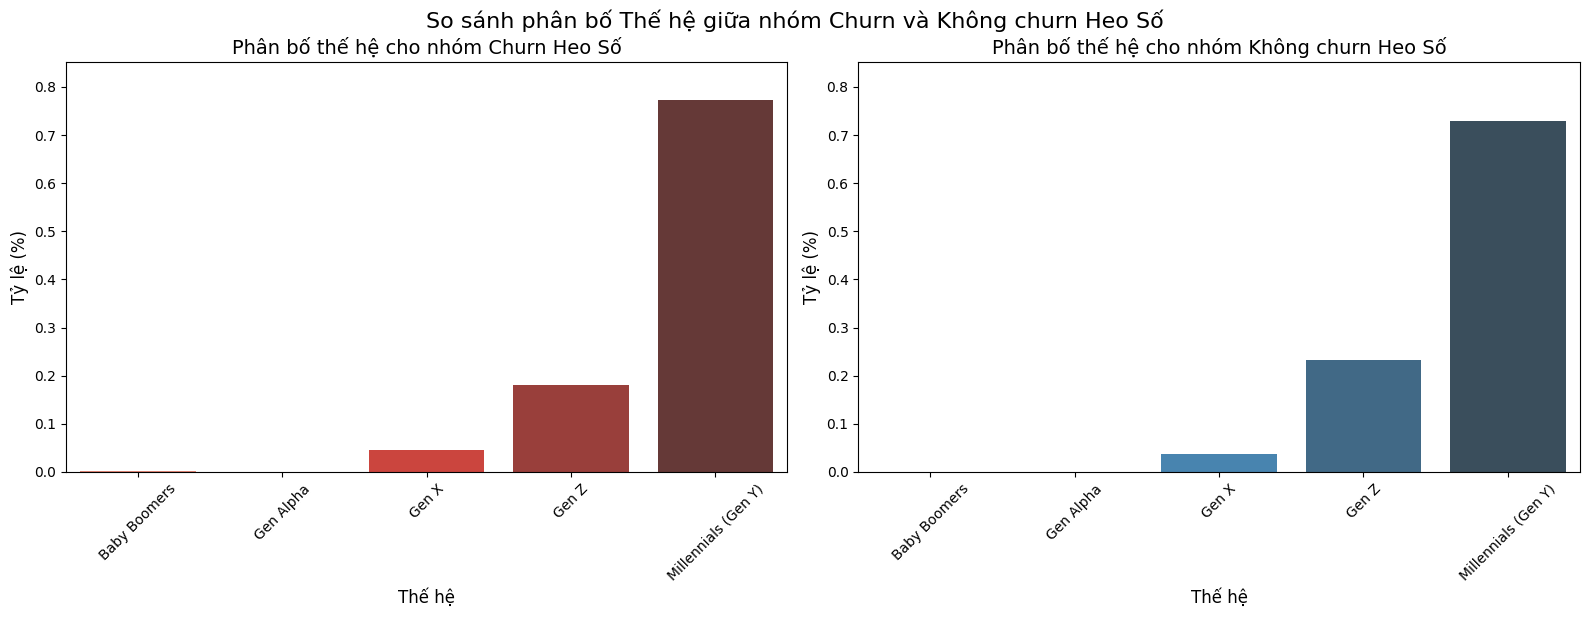

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# Define the columns of interest for login counts
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

# Ensure df_eda_active is based on df_eda_total and filtered for active users
df_eda_active = df_eda_total.copy()
df_eda_active = df_eda_active[~((df_eda_active[col_m3] == 0) & (df_eda_active[col_m6] == 0))].copy()

df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased

# --- End of re-initialization ---

# Filter out NaN values from 'dùng_heo_số' and 'thế_hệ' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số', 'thế_hệ']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Separate data into churn and non-churn groups
df_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Churn Heo Số']
df_non_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Không churn Heo Số']

# Get value counts for generation for both groups
churn_generation_proportions = df_churn['thế_hệ'].value_counts(normalize=True).sort_index()
non_churn_generation_proportions = df_non_churn['thế_hệ'].value_counts(normalize=True).sort_index()

# Define a custom order for generations if desired
generation_order = [
    'Gen Alpha',
    'Gen Z',
    'Millennials (Gen Y)',
    'Gen X',
    'Baby Boomers',
    'Silent Generation',
    'Greatest Generation'
]

# Reindex to ensure all generations are present in both series, filling missing with 0
all_generations = pd.Index(generation_order).intersection(churn_generation_proportions.index.union(non_churn_generation_proportions.index))
churn_generation_proportions = churn_generation_proportions.reindex(all_generations, fill_value=0).sort_index()
non_churn_generation_proportions = non_churn_generation_proportions.reindex(all_generations, fill_value=0).sort_index()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Churn Heo Số
sns.barplot(x=churn_generation_proportions.index, y=churn_generation_proportions.values, ax=axes[0], palette='Reds_d', hue=churn_generation_proportions.index, legend=False)
axes[0].set_title('Phân bố thế hệ cho nhóm Churn Heo Số', fontsize=14)
axes[0].set_xlabel('Thế hệ', fontsize=12)
axes[0].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, max(churn_generation_proportions.max(), non_churn_generation_proportions.max()) * 1.1)

# Plot for Không churn Heo Số
sns.barplot(x=non_churn_generation_proportions.index, y=non_churn_generation_proportions.values, ax=axes[1], palette='Blues_d', hue=non_churn_generation_proportions.index, legend=False)
axes[1].set_title('Phân bố thế hệ cho nhóm Không churn Heo Số', fontsize=14)
axes[1].set_xlabel('Thế hệ', fontsize=12)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, max(churn_generation_proportions.max(), non_churn_generation_proportions.max()) * 1.1)

plt.tight_layout()
plt.suptitle('So sánh phân bố Thế hệ giữa nhóm Churn và Không churn Heo Số', y=1.02, fontsize=16)
plt.show()

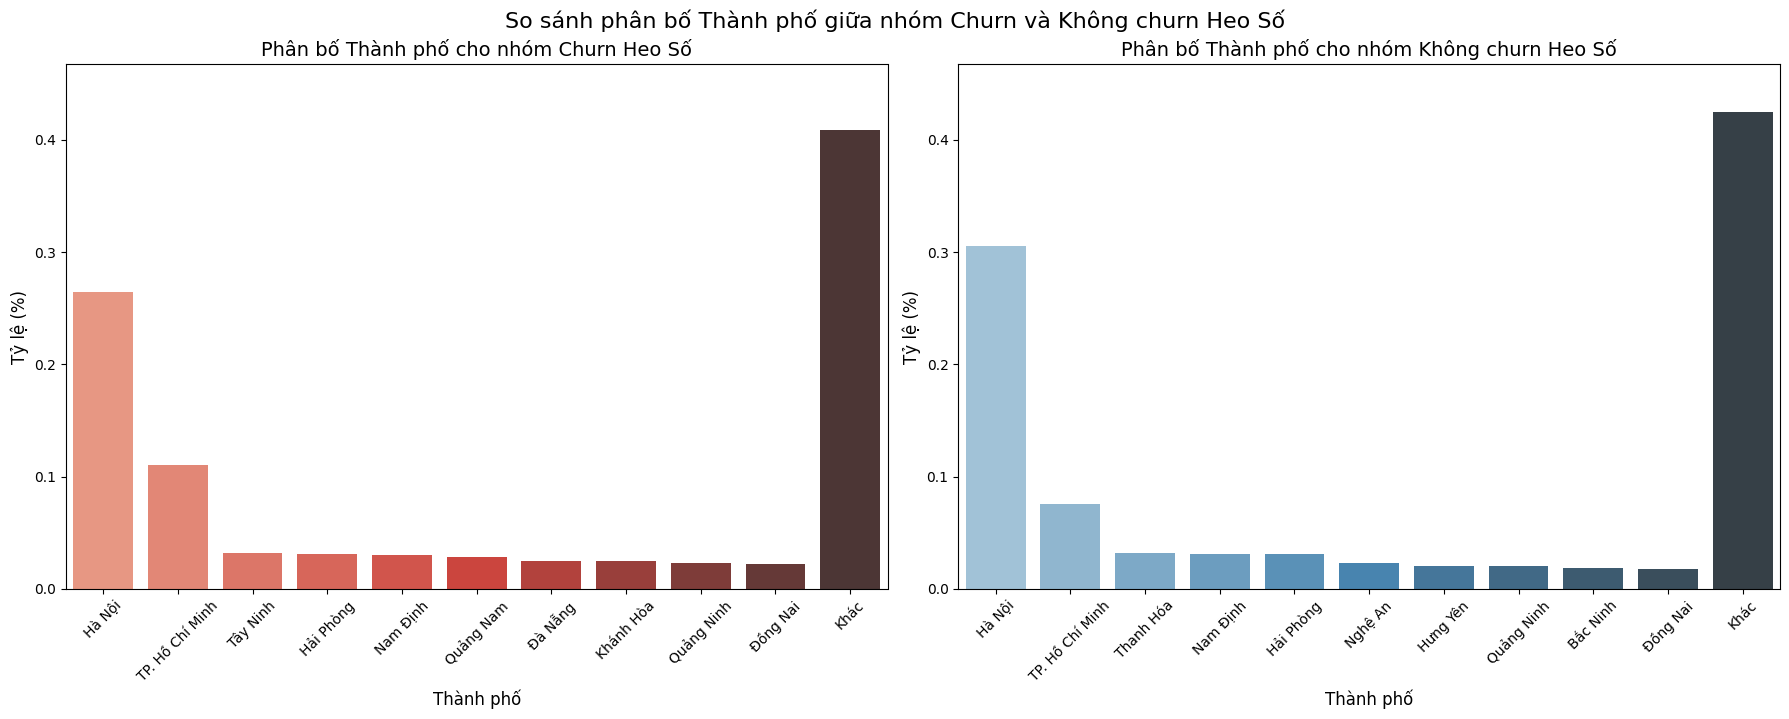

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# (This section is duplicated for standalone execution if previous cells weren't run)
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased

# MAP PROVINCE CODE → CITY (theo mã CCCD)
province_map = {
    1: "Hà Nội", 2: "Hà Giang", 4: "Cao Bằng", 6: "Bắc Kạn", 8: "Tuyên Quang",
    10: "Lào Cai", 11: "Điện Biên", 12: "Lai Châu", 14: "Sơn La", 15: "Yên Bái",
    17: "Hòa Bình", 19: "Thái Nguyên", 20: "Lạng Sơn", 22: "Quảng Ninh", 24: "Bắc Giang",
    25: "Phú Thọ", 26: "Vĩnh Phúc", 27: "Bắc Ninh", 30: "Hải Dương", 31: "Hải Phòng",
    33: "Hưng Yên", 34: "Thái Bình", 35: "Hà Nam", 36: "Nam Định", 37: "Ninh Bình",
    38: "Thanh Hóa", 40: "Nghệ An", 42: "Hà Tĩnh", 44: "Quảng Bình", 45: "Quảng Trị",
    46: "Thừa Thiên Huế", 48: "Đà Nẵng", 49: "Quảng Nam", 51: "Quảng Ngãi", 52: "Bình Định",
    54: "Phú Yên", 56: "Khánh Hòa", 58: "Ninh Thuận", 60: "Bình Thuận", 62: "Kon Tum",
    64: "Gia Lai", 66: "Đắk Lắk", 67: "Đắk Nông", 68: "Lâm Đồng", 70: "Bình Phước",
    72: "Tây Ninh", 74: "Bình Dương", 75: "Đồng Nai", 77: "Bà Rịa - Vũng Tàu",
    79: "TP. Hồ Chí Minh", 80: "Long An", 82: "Tiền Giang", 83: "Bến Tre", 84: "Trà Vinh",
    86: "Vĩnh Long", 87: "Đồng Tháp", 89: "An Giang", 91: "Kiên Giang", 92: "Cần Thơ",
    93: "Hậu Giang", 94: "Sóc Trăng", 95: "Bạc Liêu", 96: "Cà Mau"
}

# Áp dụng mapping
df_eda_active["Thành_phố"] = df_eda_active["tỉnh_thành_sinh_sống"].map(province_map)
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số', 'Thành_phố']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Separate data into churn and non-churn groups
df_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Churn Heo Số']
df_non_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Không churn Heo Số']

# Get value counts for top cities and group the rest into 'Other'
def get_top_cities_and_other(df, top_n=10):
    city_counts = df['Thành_phố'].value_counts(normalize=True)
    if len(city_counts) > top_n:
        top_cities = city_counts.head(top_n)
        other_percentage = city_counts.iloc[top_n:].sum()
        return pd.concat([top_cities, pd.Series({'Khác': other_percentage})])
    return city_counts

churn_city_proportions = get_top_cities_and_other(df_churn)
non_churn_city_proportions = get_top_cities_and_other(df_non_churn)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for Churn Heo Số
sns.barplot(x=churn_city_proportions.index, y=churn_city_proportions.values, ax=axes[0], palette='Reds_d', hue=churn_city_proportions.index, legend=False)
axes[0].set_title('Phân bố Thành phố cho nhóm Churn Heo Số', fontsize=14)
axes[0].set_xlabel('Thành phố', fontsize=12)
axes[0].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, max(churn_city_proportions.max(), non_churn_city_proportions.max()) * 1.1)

# Plot for Không churn Heo Số
sns.barplot(x=non_churn_city_proportions.index, y=non_churn_city_proportions.values, ax=axes[1], palette='Blues_d', hue=non_churn_city_proportions.index, legend=False)
axes[1].set_title('Phân bố Thành phố cho nhóm Không churn Heo Số', fontsize=14)
axes[1].set_xlabel('Thành phố', fontsize=12)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, max(churn_city_proportions.max(), non_churn_city_proportions.max()) * 1.1)

plt.tight_layout()
plt.suptitle('So sánh phân bố Thành phố giữa nhóm Churn và Không churn Heo Số', y=1.02, fontsize=16)
plt.show()

In [68]:
df_eda_active['tình_trạng_hôn_nhân'].unique()

array(['Đã kết hôn', 'Độc thân', 'Khác'], dtype=object)

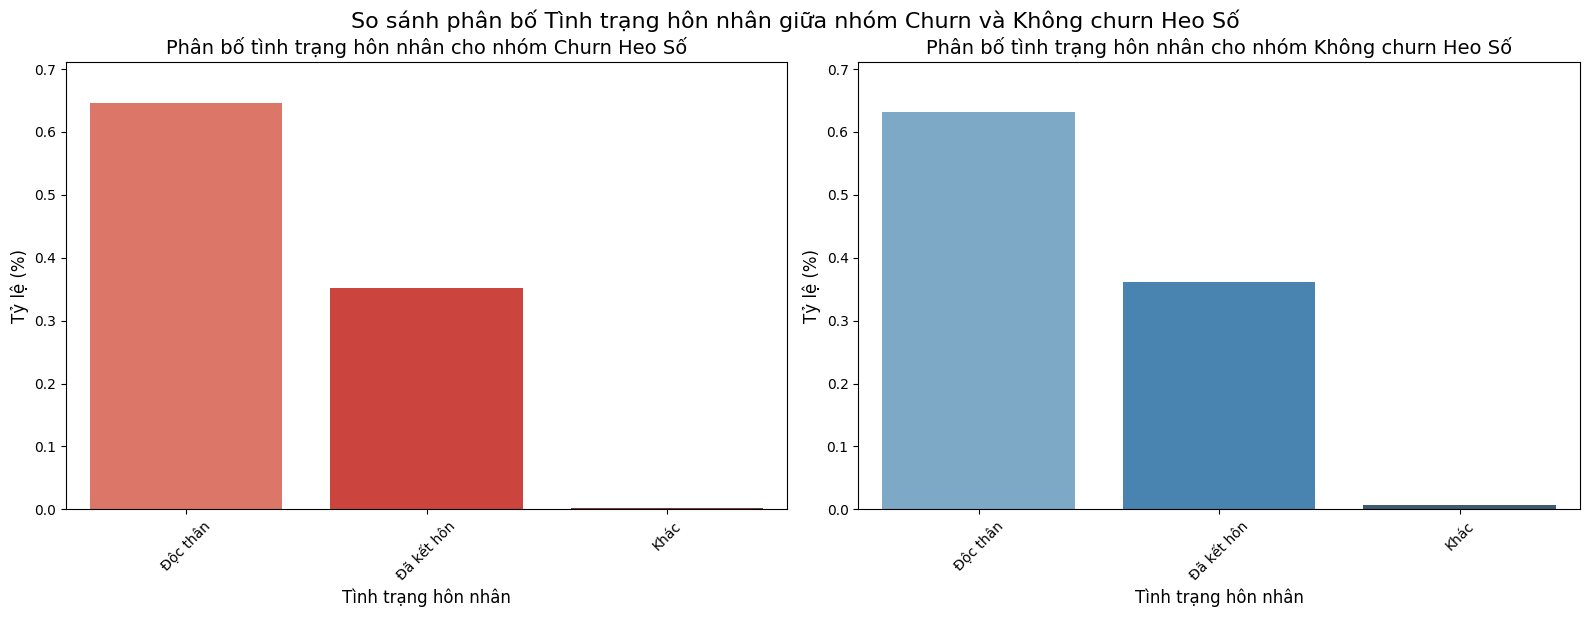

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' and 'tình_trạng_hôn_nhân' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số', 'tình_trạng_hôn_nhân']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Separate data into churn and non-churn groups
df_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Churn Heo Số']
df_non_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Không churn Heo Số']

# Get value counts for marital status for both groups
churn_marital_proportions = df_churn['tình_trạng_hôn_nhân'].value_counts(normalize=True)
non_churn_marital_proportions = df_non_churn['tình_trạng_hôn_nhân'].value_counts(normalize=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Churn Heo Số
sns.barplot(x=churn_marital_proportions.index, y=churn_marital_proportions.values, ax=axes[0], palette='Reds_d', hue=churn_marital_proportions.index, legend=False)
axes[0].set_title('Phân bố tình trạng hôn nhân cho nhóm Churn Heo Số', fontsize=14)
axes[0].set_xlabel('Tình trạng hôn nhân', fontsize=12)
axes[0].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, max(churn_marital_proportions.max(), non_churn_marital_proportions.max()) * 1.1)

# Plot for Không churn Heo Số
sns.barplot(x=non_churn_marital_proportions.index, y=non_churn_marital_proportions.values, ax=axes[1], palette='Blues_d', hue=non_churn_marital_proportions.index, legend=False)
axes[1].set_title('Phân bố tình trạng hôn nhân cho nhóm Không churn Heo Số', fontsize=14)
axes[1].set_xlabel('Tình trạng hôn nhân', fontsize=12)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, max(churn_marital_proportions.max(), non_churn_marital_proportions.max()) * 1.1)

plt.tight_layout()
plt.suptitle('So sánh phân bố Tình trạng hôn nhân giữa nhóm Churn và Không churn Heo Số', y=1.02, fontsize=16)
plt.show()

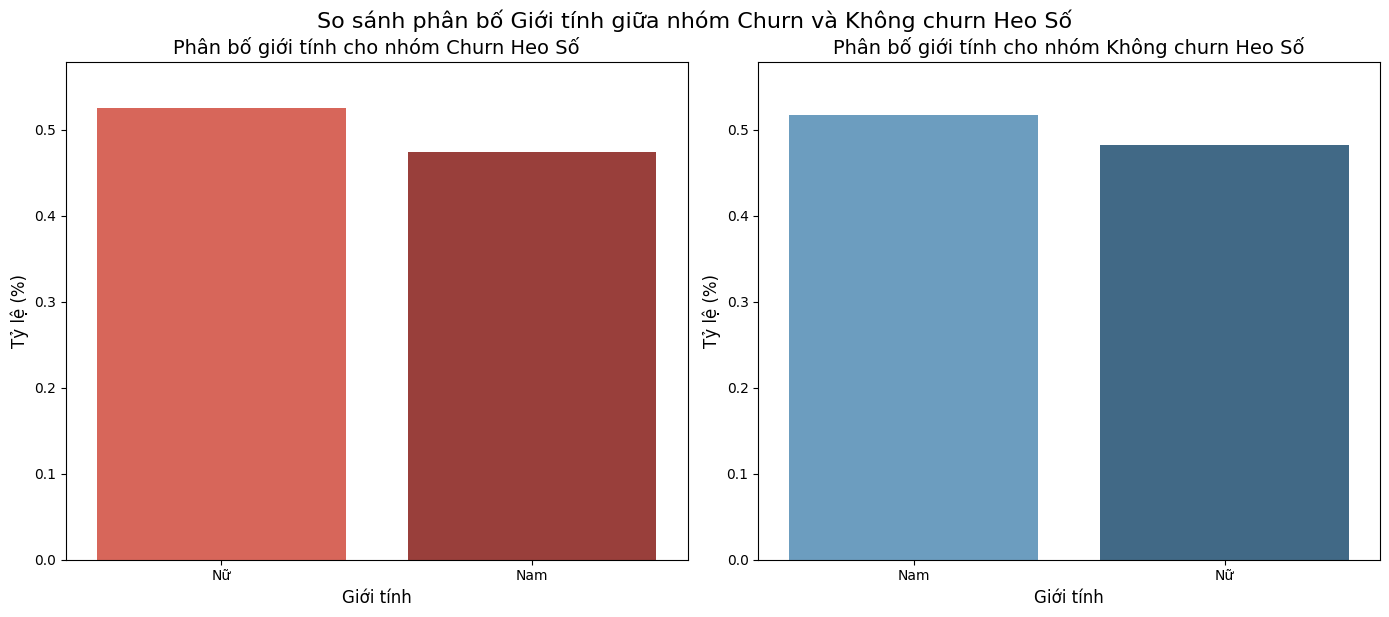

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# (This section is duplicated for standalone execution if previous cells weren't run)
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' and 'giới_tính_khách_hàng' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số', 'giới_tính_khách_hàng']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Separate data into churn and non-churn groups
df_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Churn Heo Số']
df_non_churn = df_compare[df_compare['dùng_heo_số_label'] == 'Không churn Heo Số']

# Get value counts for gender for both groups
churn_gender_proportions = df_churn['giới_tính_khách_hàng'].value_counts(normalize=True)
non_churn_gender_proportions = df_non_churn['giới_tính_khách_hàng'].value_counts(normalize=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Churn Heo Số
sns.barplot(x=churn_gender_proportions.index, y=churn_gender_proportions.values, ax=axes[0], palette='Reds_d', hue=churn_gender_proportions.index, legend=False)
axes[0].set_title('Phân bố giới tính cho nhóm Churn Heo Số', fontsize=14)
axes[0].set_xlabel('Giới tính', fontsize=12)
axes[0].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[0].set_ylim(0, max(churn_gender_proportions.max(), non_churn_gender_proportions.max()) * 1.1)

# Plot for Không churn Heo Số
sns.barplot(x=non_churn_gender_proportions.index, y=non_churn_gender_proportions.values, ax=axes[1], palette='Blues_d', hue=non_churn_gender_proportions.index, legend=False)
axes[1].set_title('Phân bố giới tính cho nhóm Không churn Heo Số', fontsize=14)
axes[1].set_xlabel('Giới tính', fontsize=12)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].set_ylim(0, max(churn_gender_proportions.max(), non_churn_gender_proportions.max()) * 1.1)

plt.tight_layout()
plt.suptitle('So sánh phân bố Giới tính giữa nhóm Churn và Không churn Heo Số', y=1.02, fontsize=16)
plt.show()

##Giao dịch


###EDA cho phần hành vi trên heo số


### Giả thuyết: Giải mã các giá trị tiền tệ
Các giá trị liên quan đến tiền tệ trong bộ dữ liệu (ví dụ: số_dư_tiết_kiệm, tổng_số_tiền_giao_dịch) đều nằm trong khoảng từ 0 đến 1. Điều này cho thấy dữ liệu đã được chuẩn hóa (scaled), không phải giá trị tiền tệ thực tế.

Để làm cho việc phân tích và diễn giải trở nên trực quan hơn, nhóm đặt ra giả thuyết rằng các giá trị này đã được chuẩn hóa theo phương pháp Decimal Scaling hoặc một phương pháp tương tự. Chúng ta sẽ giả định một hệ số nhân chung để quy đổi các giá trị này về một thang đo gần với tiền thật hơn.

Giả định: 1 đơn vị trong dữ liệu tương ứng với **1,000,000 VNĐ.**

Ví dụ:

số_dư_tiết_kiệm_heo_số = 0.001585 sẽ được hiểu là 0.001585 * 1,000,000 = 1585 VNĐ.
số_dư_tiết_kiệm_heo_số = 1.0 sẽ được hiểu là 1.0 * 1,000,000 = 1,000,000 VNĐ.
Lưu ý: Hệ số **1,000,000 VNĐ** chỉ là một giả định để các con số dễ hình dung hơn, không phải là giá trị giải mã chính xác. Tuy nhiên, việc áp dụng cùng một hệ số cho tất cả các biến tiền tệ sẽ không làm thay đổi mối quan셔 và tỷ lệ giữa chúng, do đó vẫn đảm bảo tính đúng đắn của phân tích.

### Giả thuyết: Giải mã các dữ liệu về hành vi
Trong quá trình phân tích, nhóm phát hiện cột tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021 có phân phối rất bất thường. Cụ thể, hơn 50% khách hàng có cùng một giá trị chính xác là **0.010638.** Con số này không giống một biến đếm số lần tự nhiên (ví dụ: 1, 2, 3...).

Do đó, chúng tôi đặt ra giả thuyết rằng cột dữ liệu này không phải là số lần gửi tiền thô, mà là một chỉ số đã được chuẩn hóa hoặc mã hóa bởi ngân hàng, có thể theo thang đo từ 0 đến 1.

Giả định cụ thể:

- Giá trị tối thiểu và phổ biến nhất là 0.010638 đại diện cho hành vi cơ bản nhất: **"Gửi tiền đúng 1 lần".**
- Các giá trị lớn hơn 0.010638 đại diện cho hành vi "Gửi tiền nhiều lần".
- Giá trị tối đa là 1.0 có thể đại diện cho khách hàng có số lần gửi tiền nhiều nhất trong tập dữ liệu.
- Giả thuyết này giúp giải thích tại sao một tỷ lệ lớn khách hàng lại có cùng một giá trị lẻ. Dựa trên giả định này, chúng tôi sẽ phân loại khách hàng thành hai nhóm hành vi chính: "Gửi 1 lần (Dùng thử)" và "Gửi nhiều lần (Gắn kết)" để phân tích sâu hơn về nguy cơ churn.

In [71]:
# Tạo DataFrame chính cho phân tích hành vi từ df_eda_active
df_behavior = df_eda_active.copy()

# --- 1. TẠO CÁC BIẾN DELTA ---
# Các cột cần tính delta
col_login_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_login_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'
col_balance_m3 = 'số_dư_tiết_kiệm_heo_số_tháng_3_2021'
col_balance_m6 = 'số_dư_tiết_kiệm_heo_số_tháng_6_2021'

# Điền giá trị 0 cho các giá trị NaN trong các cột gốc
cols_to_fill_delta = [col_login_m3, col_login_m6, col_balance_m3, col_balance_m6]
df_behavior[cols_to_fill_delta] = df_behavior[cols_to_fill_delta].fillna(0)

# Tạo cột delta
df_behavior['delta_login'] = df_behavior[col_login_m6] - df_behavior[col_login_m3]
df_behavior['delta_balance'] = df_behavior[col_balance_m6] - df_behavior[col_balance_m3]

# --- 2. ÁP DỤNG GIẢ THUYẾT QUY ĐỔI TIỀN TỆ ---
HE_SO_QUY_DOI = 1000000  # 1,000,000 VNĐ

# Các cột tiền tệ cần quy đổi (bao gồm cả cột delta_balance)
cols_currency_to_update = [
    'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'delta_balance'
]

# Nhân trực tiếp các cột với hệ số quy đổi
for col in cols_currency_to_update:
    if col in df_behavior.columns:
        df_behavior[col] = df_behavior[col] * HE_SO_QUY_DOI

print("DataFrame `df_behavior` đã được tạo và xử lý xong, sẵn sàng cho EDA.")

DataFrame `df_behavior` đã được tạo và xử lý xong, sẵn sàng cho EDA.


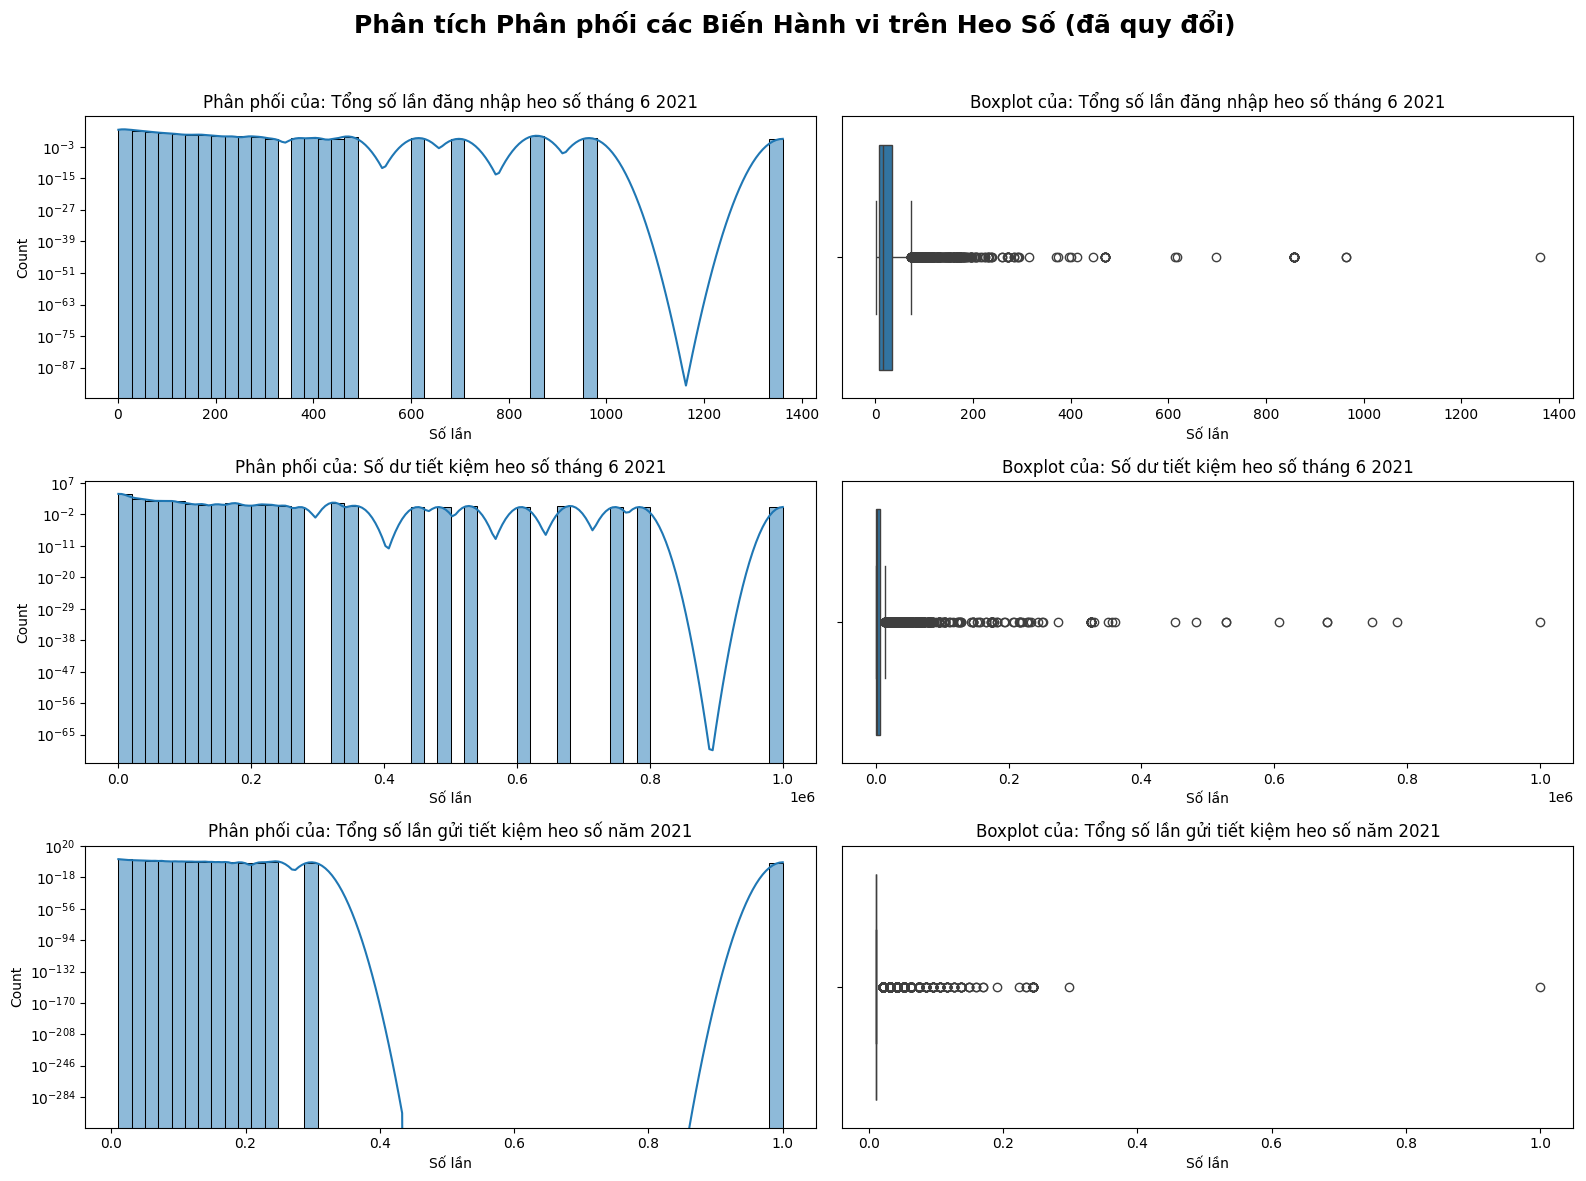


Thống kê mô tả chính (số dư đã quy đổi sang VNĐ):


,count,mean,std,min,25%,50%,75%,90%,99%,max
tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021,7571.0,29.372606,56.832050,1.000000,8.000000,16.000000,34.000000,59.000000,184.600000,1361.0
số_dư_tiết_kiệm_heo_số_tháng_6_2021,7571.0,8941.675579,35183.144013,0.000000,365.854000,1219.512000,6007.926500,16719.512000,125487.804300,1000000.0
tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021,7571.0,0.016682,0.021598,0.010638,0.010638,0.010638,0.010638,0.031915,0.085106,1.0


In [72]:
# Các cột chính về hành vi trên Heo Số (tên cột không đổi)
cols_to_analyze = [
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021'
]

# Vẽ biểu đồ
fig, axes = plt.subplots(len(cols_to_analyze), 2, figsize=(16, 12))
fig.suptitle('Phân tích Phân phối các Biến Hành vi trên Heo Số (đã quy đổi)', fontsize=18, fontweight='bold')

for i, col in enumerate(cols_to_analyze):
    # Biểu đồ phân phối (Histogram + KDE)
    sns.histplot(df_behavior[col].dropna(), kde=True, ax=axes[i, 0], bins=50)

    # Cập nhật tiêu đề và nhãn trục
    title_text = col.replace('_', ' ').capitalize()
    if 'tiết kiệm' in col:
        title_text += ' (ước tính VNĐ)'
        axes[i, 0].set_xlabel('Giá trị (VNĐ)')
    else:
        axes[i, 0].set_xlabel('Số lần')

    axes[i, 0].set_title(f'Phân phối của: {title_text}', fontsize=12)
    axes[i, 0].set_yscale('log')

    # Biểu đồ hộp (Boxplot)
    sns.boxplot(x=df_behavior[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot của: {title_text}', fontsize=12)
    if 'tiết kiệm' in col:
        axes[i, 1].set_xlabel('Giá trị (VNĐ)')
    else:
        axes[i, 1].set_xlabel('Số lần')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# In ra các thống kê mô tả quan trọng (số liệu giờ đã là VNĐ)
print("\nThống kê mô tả chính (số dư đã quy đổi sang VNĐ):")
display(df_behavior[cols_to_analyze].describe(percentiles=[.25, .5, .75, .9, .99]).transpose())

- Insight 1: Hành vi tương tác cực kỳ tích cực.

- Insight 2: Tồn tại một nhóm "siêu người dùng" (Power Users) với tần suất đột biến.

- Insight 3: Hành vi nuôi heo bằng các khoản tiền nhỏ, các khoản tiền tích lũy hằng ngày

- Insight 4: Có những người nắm giữ khối tài sản lớn trong heo số


In [73]:
# Lọc ra DataFrame chỉ chứa nhóm Churn và Non-Churn đã được định nghĩa
df_compare_table = df_behavior.dropna(subset=['dùng_heo_số']).copy()

# Các cột hành vi cốt lõi trên Heo Số để so sánh
cols_heoso = [
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021'
]

# Tính toán giá trị trung vị (median) cho từng nhóm
summary_table = df_compare_table.groupby('dùng_heo_số')[cols_heoso].median()

# Đổi tên index để dễ đọc
summary_table.index = ['Non-Churn (0)', 'Churn (1)']

# Tính toán mức độ chênh lệch (Non-Churn / Churn)
# Thêm một số nhỏ (epsilon) để tránh lỗi chia cho 0
epsilon = 1e-9
summary_table.loc['Chênh lệch (lần)'] = summary_table.loc['Non-Churn (0)'] / (summary_table.loc['Churn (1)'] + epsilon)

# --- Định dạng bảng để hiển thị ---
summary_table_display = summary_table.copy()
# Định dạng cột tiền tệ
balance_col = 'số_dư_tiết_kiệm_heo_số_tháng_6_2021'
summary_table_display[balance_col] = summary_table_display[balance_col].apply('{:,.0f} VNĐ'.format)

# Định dạng dòng chênh lệch
for col in summary_table_display.columns:
    summary_table_display.loc['Chênh lệch (lần)', col] = f"{summary_table.loc['Chênh lệch (lần)', col]:.2f} lần"

print("Bảng 1: So sánh hành vi trung vị giữa nhóm Non-Churn và Churn")
display(summary_table_display)

Bảng 1: So sánh hành vi trung vị giữa nhóm Non-Churn và Churn


/tmp/ipython-input-2021001536.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.75 lần' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_table_display.loc['Chênh lệch (lần)', col] = f"{summary_table.loc['Chênh lệch (lần)', col]:.2f} lần"
/tmp/ipython-input-2021001536.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00 lần' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_table_display.loc['Chênh lệch (lần)', col] = f"{summary_table.loc['Chênh lệch (lần)', col]:.2f} lần"


,tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021,số_dư_tiết_kiệm_heo_số_tháng_6_2021,tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021
Non-Churn (0),22.0,"1,585 VNĐ",0.010638
Churn (1),8.0,"1,220 VNĐ",0.010638
Chênh lệch (lần),2.75 lần,1.30 lần,1.00 lần



Bảng 3 (Đã sửa): Tỷ lệ các loại Hành vi Gửi tiền trong mỗi nhóm Churn/Non-Churn


HanhVi_GuiTien,Gửi nhiều lần
Non-Churn (0),100.0%
Churn (1),100.0%


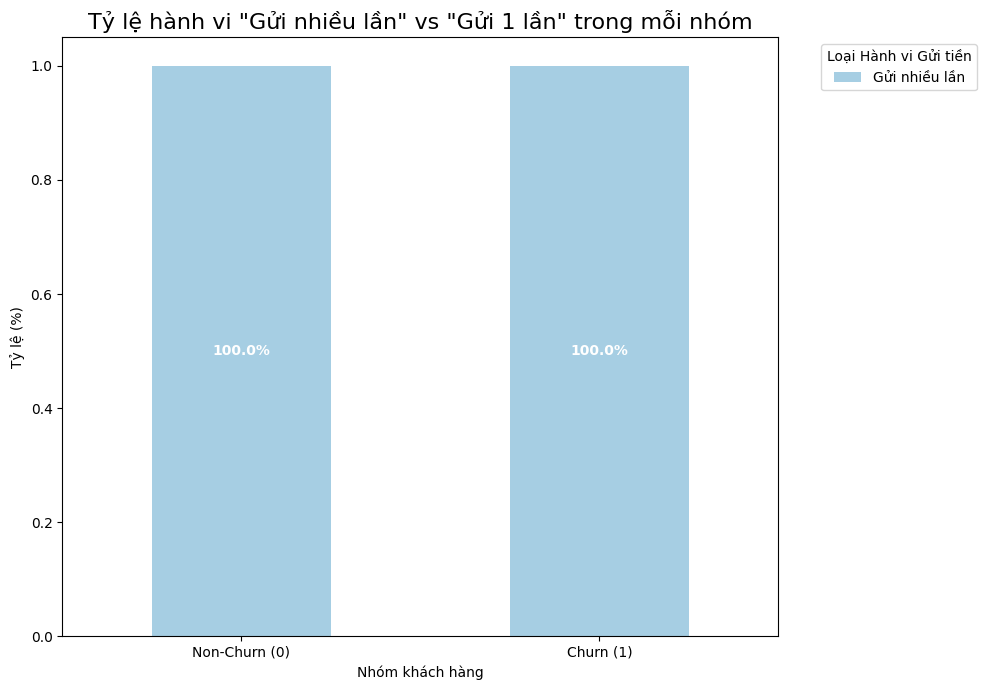

In [74]:
# --- HƯỚNG 3 (ĐÃ SỬA): KIỂM CHỨNG GIẢ THUYẾT "DÙNG THỬ" ---

# Lọc ra DataFrame cần thiết một lần nữa để chắc chắn
df_compare_table = df_behavior.dropna(subset=['dùng_heo_số']).copy()

# Giả định giá trị 'gửi 1 lần' theo Giả thuyết 4
one_time_saving_value = 0.010638

# Tạo biến phân loại hành vi gửi tiền một cách chính xác
def classify_saving_behavior_v2(x):
    # Sử dụng np.isclose để so sánh số thực một cách an toàn
    if np.isclose(x, one_time_saving_value):
        return 'Chỉ gửi 1 lần'
    elif x > one_time_saving_value:
        return 'Gửi nhiều lần'
    else: # Bao gồm các trường hợp có giá trị 0 hoặc nhỏ hơn (nếu có)
        return 'Không gửi / Gửi rất ít'

df_compare_table['HanhVi_GuiTien'] = df_compare_table['tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021'].apply(classify_saving_behavior_v2)

# Tạo bảng chéo để xem phân phối tỷ lệ
churn_rate_saving_behavior = pd.crosstab(
    df_compare_table['dùng_heo_số'],
    df_compare_table['HanhVi_GuiTien'],
    normalize='index' # Tính tỷ lệ theo hàng
)
churn_rate_saving_behavior.index = ['Non-Churn (0)', 'Churn (1)']

print("\nBảng 3 (Đã sửa): Tỷ lệ các loại Hành vi Gửi tiền trong mỗi nhóm Churn/Non-Churn")
display((churn_rate_saving_behavior * 100).round(2).astype(str) + '%')

# --- Trực quan hóa kết quả đúng ---
# Dùng biểu đồ cột chồng để thể hiện rõ tỷ lệ
churn_rate_saving_behavior.plot(kind='bar',
                                stacked=True,
                                figsize=(10, 7),
                                colormap='Paired',
                                rot=0)

plt.title('Tỷ lệ hành vi "Gửi nhiều lần" vs "Gửi 1 lần" trong mỗi nhóm', fontsize=16)
plt.ylabel('Tỷ lệ (%)')
plt.xlabel('Nhóm khách hàng')
# Thêm nhãn phần trăm lên các cột
for idx, row in enumerate(churn_rate_saving_behavior.iterrows()):
    cumulative = 0
    for col_name, value in row[1].items():
        if value > 0:
            plt.text(idx, cumulative + value / 2, f'{value:.1%}', ha='center', va='center', color='white', fontweight='bold')
        cumulative += value

plt.legend(title='Loại Hành vi Gửi tiền', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [75]:
# Tách riêng nhóm "Chỉ gửi 1 lần" từ DataFrame gốc (df_behavior)
one_time_saving_value = 0.010638
df_one_time_savers = df_behavior[np.isclose(df_behavior['tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021'], one_time_saving_value)].copy()

print(f"Phát hiện được {len(df_one_time_savers)} khách hàng thuộc nhóm 'Chỉ gửi 1 lần'.")
print("Đây có thể là nhóm 'Churn của người dùng mới'. Hãy xem các đặc điểm của họ:\n")

# Các cột hành vi để mô tả nhóm này
cols_to_describe_new_churn = [
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'delta_balance' # Thay đổi số dư của họ như thế nào?
]

# In ra bảng thống kê mô tả chỉ cho nhóm này
display(df_one_time_savers[cols_to_describe_new_churn].describe().transpose())

Phát hiện được 0 khách hàng thuộc nhóm 'Chỉ gửi 1 lần'.
Đây có thể là nhóm 'Churn của người dùng mới'. Hãy xem các đặc điểm của họ:



,count,mean,std,min,25%,50%,75%,max
tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
số_dư_tiết_kiệm_heo_số_tháng_6_2021,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delta_balance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Nhóm đăng nhập 1 lần không xuất hiện trong biến churn hay non churn<br>
- Insight: Sự Tồn tại của Nhóm "Churn Thầm lặng" ngoài Phạm vi Quan sát<br>
Phân tích thống kê cho thấy một điều rất đáng chú ý:<br>
- Toàn bộ nhóm khách hàng có hành vi "chỉ gửi tiền đúng 1 lần" (nhóm có giá trị tổng_số_lần_gửi_tiết_kiệm bằng 0.010638) đều là những người không có bất kỳ hoạt động đăng nhập nào vào tính năng Heo Số trong cả tháng 3 và tháng 6.<br>
####Điều này có nghĩa là:<br>
- Họ nằm ngoài phạm vi mô hình: Vì định nghĩa Churn/Non-Churn của chúng ta dựa trên dữ liệu đăng nhập của T3 và T6, nhóm này hoàn toàn "vô hình" trong tập dữ liệu 7,571 khách hàng mà chúng ta đang phân tích. Họ là một dạng "churn thầm lặng" mà mô hình hiện tại không thể phát hiện.<br>
**=> Kết luận: Có một lượng lớn khách hàng rời bỏ ngay sau lần trải nghiệm đầu tiên mà không để lại dấu vết tương tác (login). Cần có một chiến lược riêng để kéo họ quay lại và hình thành thói quen, thay vì chỉ tập trung vào nhóm người dùng cũ đang có dấu hiệu giảm hoạt động.**

/tmp/ipython-input-2831636140.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['0: Non-Churn', '1: Churn'])
/tmp/ipython-input-2831636140.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['0: Non-Churn', '1: Churn'])
/tmp/ipython-input-2831636140.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['0: Non-Churn', '1: Churn'])


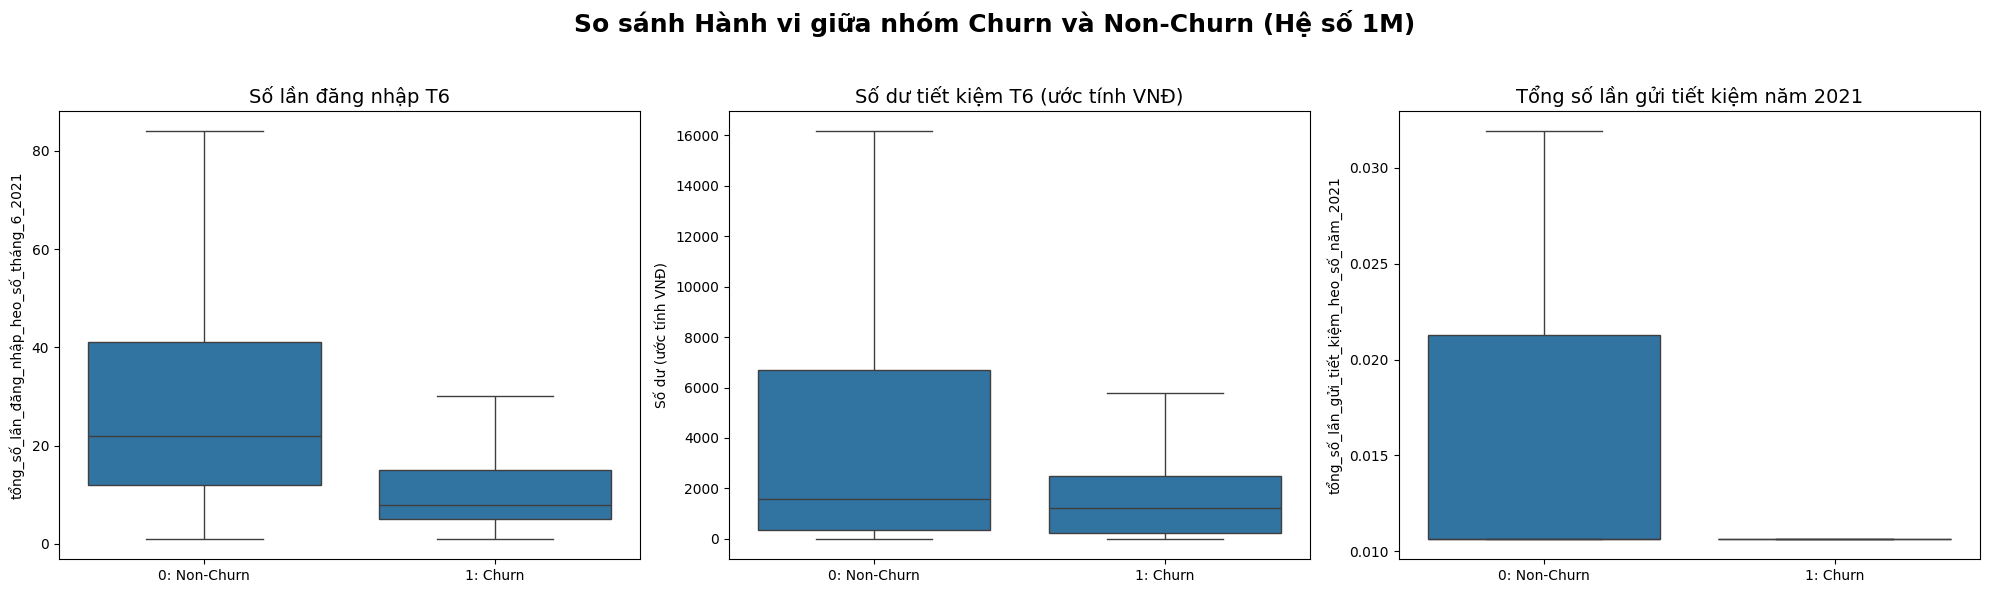

In [76]:
# Lọc bỏ các dòng mà cột 'dùng_heo_số' là NaN từ df_behavior
df_plot_compare = df_behavior.dropna(subset=['dùng_heo_số']).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('So sánh Hành vi giữa nhóm Churn và Non-Churn (Hệ số 1M)', fontsize=18, fontweight='bold')

# Biến 1: Số lần đăng nhập
sns.boxplot(data=df_plot_compare, x='dùng_heo_số', y='tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021', ax=axes[0], showfliers=False)
axes[0].set_title('Số lần đăng nhập T6', fontsize=14)
axes[0].set_xticklabels(['0: Non-Churn', '1: Churn'])
axes[0].set_xlabel('')

# Biến 2: Số dư tiết kiệm (VNĐ)
sns.boxplot(data=df_plot_compare, x='dùng_heo_số', y='số_dư_tiết_kiệm_heo_số_tháng_6_2021', ax=axes[1], showfliers=False)
axes[1].set_title('Số dư tiết kiệm T6 (ước tính VNĐ)', fontsize=14)
axes[1].set_xticklabels(['0: Non-Churn', '1: Churn'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Số dư (ước tính VNĐ)')


# Biến 3: Tổng số lần gửi tiết kiệm
sns.boxplot(data=df_plot_compare, x='dùng_heo_số', y='tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021', ax=axes[2], showfliers=False)
axes[2].set_title('Tổng số lần gửi tiết kiệm năm 2021', fontsize=14)
axes[2].set_xticklabels(['0: Non-Churn', '1: Churn'])
axes[2].set_xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- Insight 1: Khách hàng Churn có mức độ tương tác và giá trị tiết kiệm thấp hơn đáng kể

- Insight 2: Nhóm Churn gần như ngừng hẳn hành vi "nuôi heo", một khi đã churn thì gần như sẽ không gửi đồng tiết kiệm vào nuôi heo số

- Insight 3: Nhóm Non-Churn có hành vi đa dạng hơn, họ vừa đăng nhập nhiều, vừa gửi tiết kiệm nhiều lần với lượng số dư nhiều hơn đáng kể so với nhóm churn

In [77]:
import pandas as pd

# --------------------------------------------------
# 1. Lọc bỏ các dòng có 'dùng_heo_số' = NaN
# --------------------------------------------------
df_plot_compare = df_behavior.dropna(subset=['dùng_heo_số']).copy()

# --------------------------------------------------
# 2. Tạo phân khúc dựa trên số lần đăng nhập Heo Số (T6/2021)
# --------------------------------------------------
df_plot_compare['PhanKhuc_Login'] = pd.qcut(
    df_plot_compare['tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'],
    q=4,
    duplicates='drop'
)

# Gán nhãn theo số bin thực tế
labels_login = ['Tương tác thấp', 'TB', 'Cao', 'Rất cao']
df_plot_compare['PhanKhuc_Login'] = df_plot_compare['PhanKhuc_Login'].cat.rename_categories(
    labels_login[:df_plot_compare['PhanKhuc_Login'].nunique()]
)

# --------------------------------------------------
# 3. Tạo phân khúc dựa trên số dư tiết kiệm Heo Số (T6/2021)
# --------------------------------------------------
df_plot_compare['PhanKhuc_SoDu'] = pd.qcut(
    df_plot_compare['số_dư_tiết_kiệm_heo_số_tháng_6_2021'],
    q=4,
    duplicates='drop'
)

# Gán nhãn theo số bin thực tế
labels_sodu = ['Giá trị thấp', 'TB', 'Cao', 'Rất cao']
df_plot_compare['PhanKhuc_SoDu'] = df_plot_compare['PhanKhuc_SoDu'].cat.rename_categories(
    labels_sodu[:df_plot_compare['PhanKhuc_SoDu'].nunique()]
)

print(
    "DataFrame 'df_plot_compare' đã sẵn sàng: "
    "đã lọc NaN, có cột delta và các cột phân khúc."
)


DataFrame 'df_plot_compare' đã sẵn sàng: đã lọc NaN, có cột delta và các cột phân khúc.


In [78]:
# Tạo bảng tổng hợp (pivot table) để xem sự thay đổi số dư
# df_compare_table đã được tạo ở ô code trên
# Chúng ta sẽ sử dụng lại cột 'PhanKhuc_SoDu_VND' nếu bạn đã tạo nó, nếu không, hãy tạo lại

# Kiểm tra và tạo cột phân khúc nếu chưa có
if 'PhanKhuc_SoDu_VND' not in df_compare_table.columns:
    bins_balance = [-1, 10000, 50000, 200000, float('inf')]
    labels_balance = ['Giá trị thấp', 'TB', 'Cao', 'Rất cao']
    df_compare_table['PhanKhuc_SoDu_VND'] = pd.cut(df_compare_table['số_dư_tiết_kiệm_heo_số_tháng_6_2021'], bins=bins_balance, labels=labels_balance)

delta_pivot_table = pd.pivot_table(
    df_compare_table,
    values='delta_balance',
    index='PhanKhuc_SoDu_VND',
    columns='dùng_heo_số',
    aggfunc='median'
)

# Đổi tên cột
delta_pivot_table.columns = ['Non-Churn (Gửi thêm)', 'Churn (Rút ra)']

print("\nBảng 2: Mức độ thay đổi số dư trung vị (VNĐ) theo Phân khúc và Trạng thái Churn")
# Định dạng bảng kết quả
display(delta_pivot_table.applymap(lambda x: f'{x:,.0f} VNĐ' if pd.notna(x) else 'Không có dữ liệu'))


Bảng 2: Mức độ thay đổi số dư trung vị (VNĐ) theo Phân khúc và Trạng thái Churn


/tmp/ipython-input-527872396.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  delta_pivot_table = pd.pivot_table(
/tmp/ipython-input-527872396.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(delta_pivot_table.applymap(lambda x: f'{x:,.0f} VNĐ' if pd.notna(x) else 'Không có dữ liệu'))


,Non-Churn (Gửi thêm),Churn (Rút ra)
PhanKhuc_SoDu_VND,,
Giá trị thấp,61 VNĐ,-639 VNĐ
TB,459 VNĐ,"-15,215 VNĐ"
Cao,"-33,969 VNĐ","-68,961 VNĐ"
Rất cao,"17,915 VNĐ","-308,362 VNĐ"


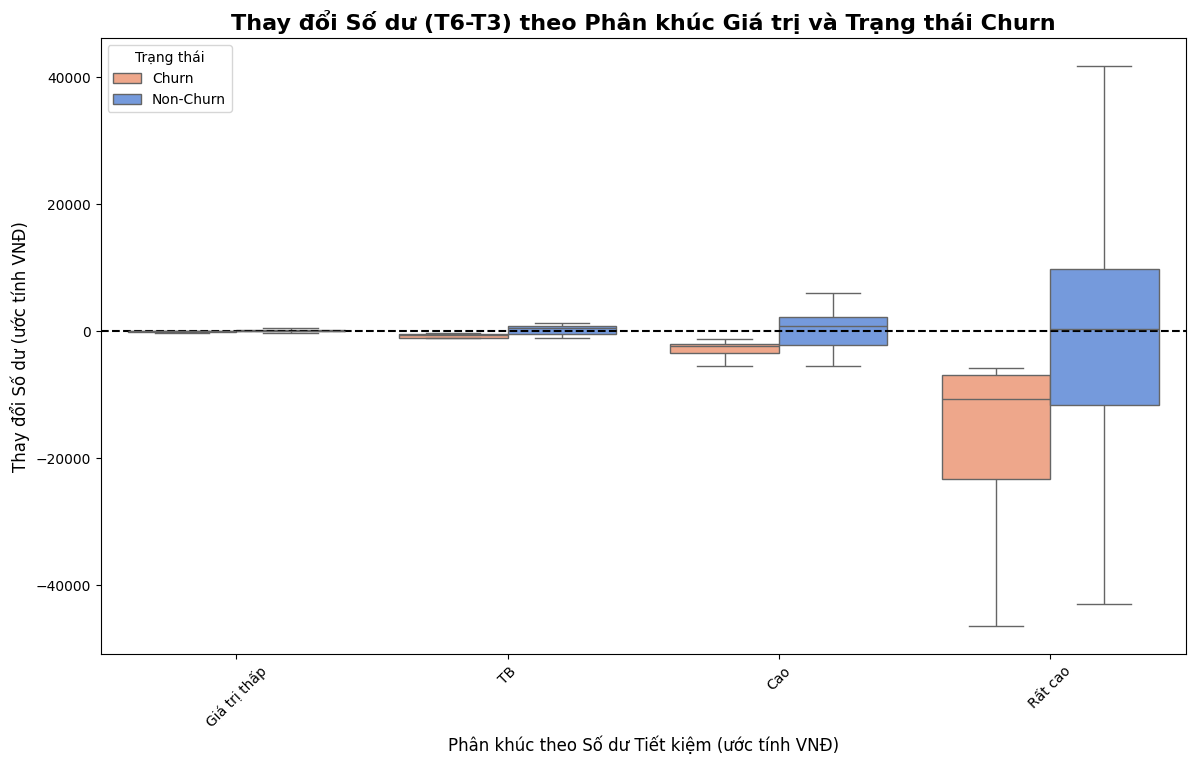

In [79]:
df_plot_final = df_plot_compare.copy()

# TẠO CỘT MỚI 'TrangThai' VỚI NHÃN DẠNG CHỮ
df_plot_final['TrangThai'] = df_plot_final['dùng_heo_số'].map({0: 'Non-Churn', 1: 'Churn'})

# VẼ BIỂU ĐỒ
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_plot_final,
            x='PhanKhuc_SoDu',
            y='delta_balance',
            hue='TrangThai',  # <-- SỬ DỤNG CỘT MỚI 'TrangThai'
            palette={'Non-Churn': 'cornflowerblue', 'Churn': 'lightsalmon'}, # Tùy chỉnh màu sắc cho đẹp hơn
            showfliers=False)

plt.title('Thay đổi Số dư (T6-T3) theo Phân khúc Giá trị và Trạng thái Churn', fontsize=16, fontweight='bold')
plt.xlabel('Phân khúc theo Số dư Tiết kiệm (ước tính VNĐ)', fontsize=12)
plt.ylabel('Thay đổi Số dư (ước tính VNĐ)', fontsize=12)
plt.axhline(0, color='black', linestyle='--')

# SEABORN SẼ TỰ ĐỘNG TẠO CHÚ GIẢI ĐÚNG, KHÔNG CẦN plt.legend() NỮA
# Lấy legend handle và chỉnh lại tiêu đề nếu muốn
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Trạng thái')

plt.tick_params(axis='x', rotation=45)
plt.show()

- Phân khúc "Giá trị thấp": Churn Thầm lặng.<br>
Khách hàng ở nhóm này, dù churn hay không, đều có biến động số dư rất nhỏ, gần như bằng 0. Điều này cho thấy hành vi rời bỏ của họ chủ yếu là ngừng gửi thêm tiền chứ không phải rút ra một khoản lớn.<br>

- Phân khúc "Trung bình (TB)": Bắt đầu có sự Phân hóa. <br>
Ở nhóm này, sự khác biệt giữa hai trạng thái bắt đầu rõ hơn. Nhóm Non-Churn có xu hướng rõ ràng là gửi thêm tiền , trong khi nhóm Churn bắt đầu có xu hướng rút tiền ra.<br>


- Phân khúc "Cao": Xu hướng Trái ngược Rõ nét.<br>
Sự phân hóa trở nên rất rõ ràng. Khách hàng Non-Churn tích cực gửi thêm những khoản tiền đáng kể. Ngược lại, khách hàng Churn thể hiện hành vi rút tiền mạnh mẽ<br>

- Phân khúc "Rất cao": Tác động Lớn nhất.<br>
Đây là nhóm có biến động mạnh nhất. Khách hàng Non-Churn là những người đóng góp nhiều nhất cho sự tăng trưởng số dư. Ngược lại, khách hàng Churn trong nhóm này gây ra thiệt hại tài chính lớn nhất, với mức rút tiền ròng cao vượt trội.<br>

 **Nhóm Non-Churn có xu hướng tăng/giữ nguyên số dư, trong khi nhóm Churn có xu hướng rút tiền ròng.**

#### Khối lượng giao dịch

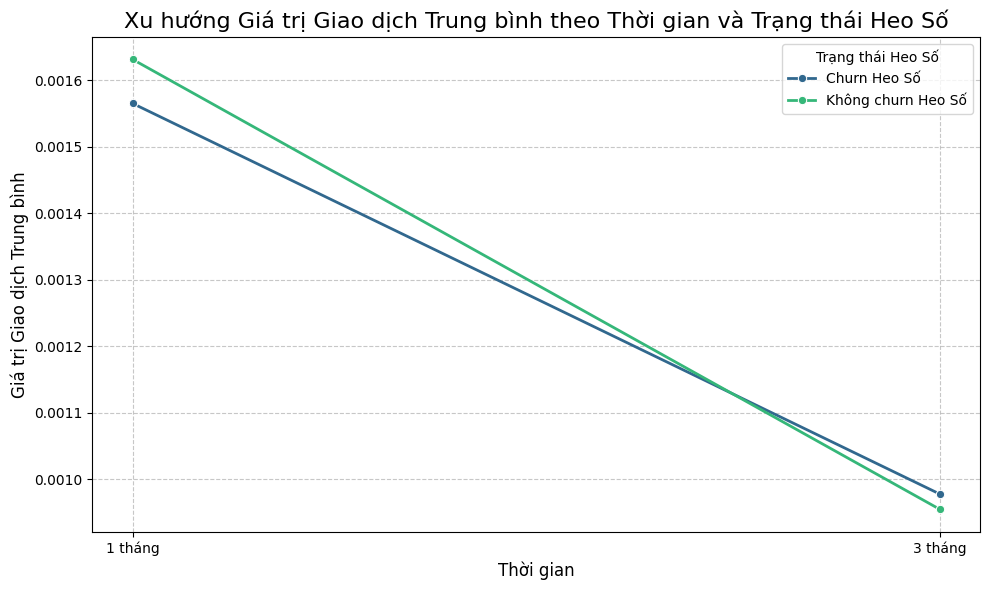

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' (to fix NameError) ---
# Assuming df_eda_total is available from previous steps

# Define the columns of interest for login counts
col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

# Remove rows where both specified columns are null
df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')

# Initialize 'dùng_heo_số' with NaN for all rows
df_eda_active['dùng_heo_số'] = np.nan

# Create a boolean mask for rows where both columns are not null in df_eda_active
not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()

# Apply the condition for equal values (maintained/stopped using) to the non-null rows
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1

# Apply the condition for month 3 value being less than month 6 value (increased usage) to the non-null rows
less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the transaction volume columns to analyze
transaction_volume_cols = [
    # 'tổng_số_tiền_giao_dịch_trong_1_tuần', # This column was dropped earlier
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng'
]

# Calculate the average transaction volumes for each churn group
average_transaction_volume = df_compare.groupby('dùng_heo_số_label')[transaction_volume_cols].mean()

# Prepare data for plotting by melting it to a long format
plot_df_volume = average_transaction_volume.stack().reset_index()
plot_df_volume.columns = ['Trạng thái Heo Số', 'Thời gian', 'Giá trị giao dịch trung bình']

# Map Thời gian labels for better readability
time_period_mapping = {
    'tổng_số_tiền_giao_dịch_trong_1_tháng': '1 tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng': '3 tháng'
}
plot_df_volume['Thời gian'] = plot_df_volume['Thời gian'].map(time_period_mapping)

# Define the order of time periods for the x-axis
time_order = ['1 tháng', '3 tháng']

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Thời gian',
    y='Giá trị giao dịch trung bình',
    hue='Trạng thái Heo Số',
    data=plot_df_volume,
    marker='o',
    palette='viridis',
    sort=False, # Maintain the order specified in time_order
    linewidth=2
)

plt.title('Xu hướng Giá trị Giao dịch Trung bình theo Thời gian và Trạng thái Heo Số', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá trị Giao dịch Trung bình', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Số lượng đối tác giao dịch

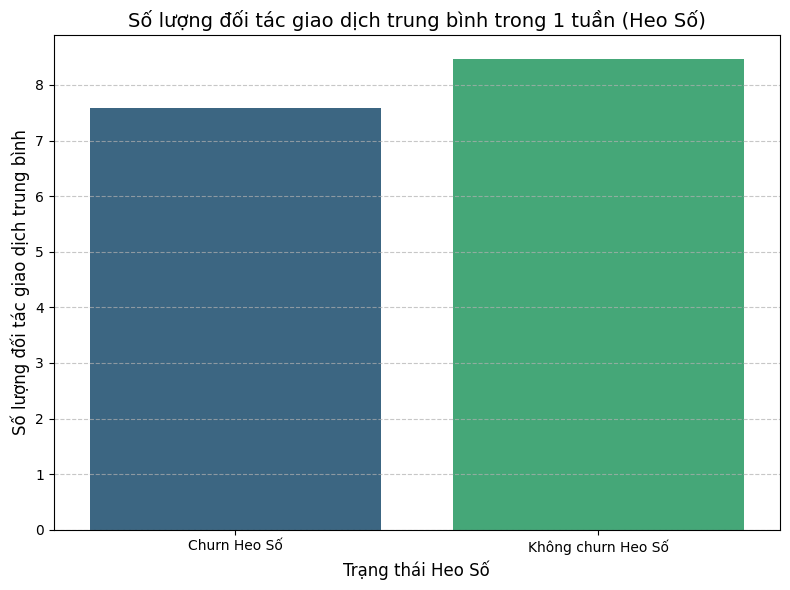

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the column for transaction partners in 1 week
partner_col = 'số_lượng_đối_tác_giao_dịch_trong_1_tuần'

# Calculate the average number of partners for each churn group
average_partners = df_compare.groupby('dùng_heo_số_label')[partner_col].mean().reset_index()
average_partners.columns = ['Trạng thái Heo Số', 'Số lượng đối tác giao dịch trung bình (1 tuần)']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Trạng thái Heo Số',
    y='Số lượng đối tác giao dịch trung bình (1 tuần)',
    hue='Trạng thái Heo Số',
    data=average_partners,
    palette='viridis',
    legend=False
)

plt.title('Số lượng đối tác giao dịch trung bình trong 1 tuần (Heo Số)', fontsize=14)
plt.xlabel('Trạng thái Heo Số', fontsize=12)
plt.ylabel('Số lượng đối tác giao dịch trung bình', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

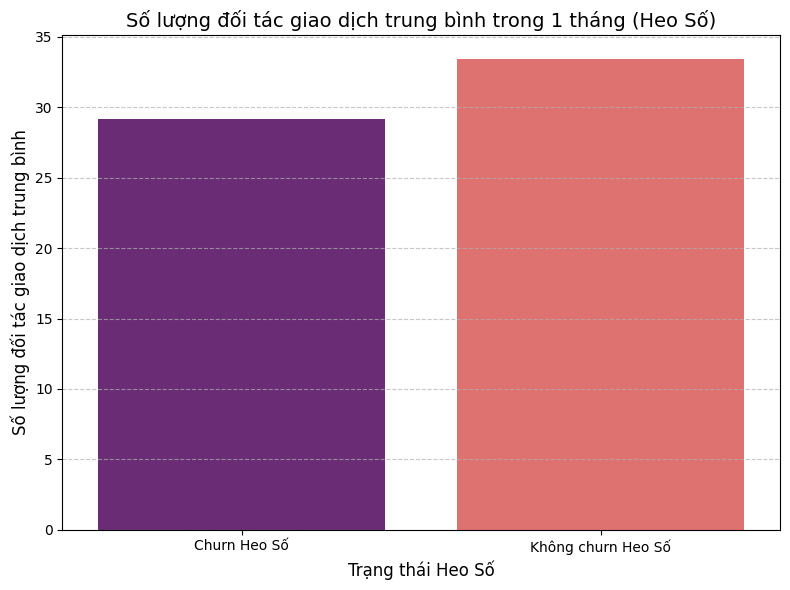

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the column for transaction partners in 1 month
partner_col_month = 'số_lượng_đối_tác_giao_dịch_trong_1_tháng'

# Calculate the average number of partners for each churn group
average_partners_month = df_compare.groupby('dùng_heo_số_label')[partner_col_month].mean().reset_index()
average_partners_month.columns = ['Trạng thái Heo Số', 'Số lượng đối tác giao dịch trung bình (1 tháng)']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Trạng thái Heo Số',
    y='Số lượng đối tác giao dịch trung bình (1 tháng)',
    hue='Trạng thái Heo Số',
    data=average_partners_month,
    palette='magma',
    legend=False
)

plt.title('Số lượng đối tác giao dịch trung bình trong 1 tháng (Heo Số)', fontsize=14)
plt.xlabel('Trạng thái Heo Số', fontsize=12)
plt.ylabel('Số lượng đối tác giao dịch trung bình', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

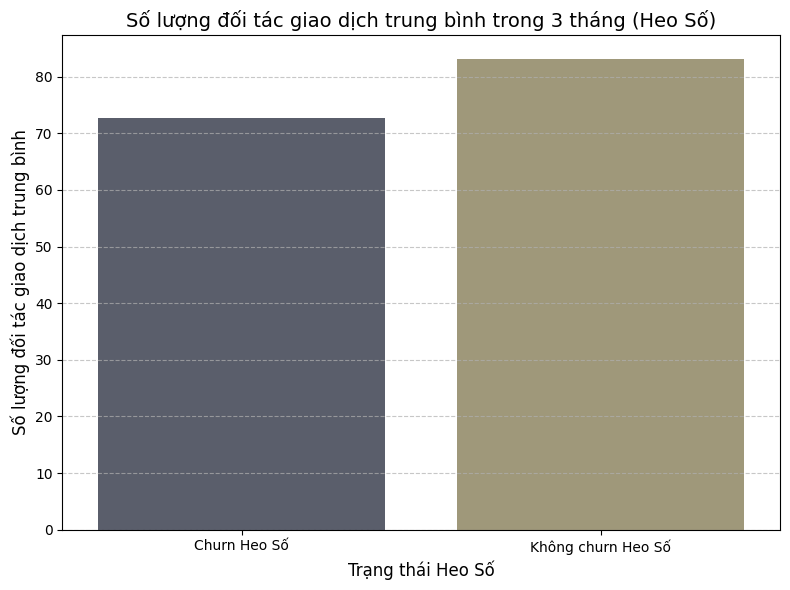

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the column for transaction partners in 3 months
partner_col_3month = 'số_lượng_đối_tác_giao_dịch_trong_3_tháng'

# Calculate the average number of partners for each churn group
average_partners_3month = df_compare.groupby('dùng_heo_số_label')[partner_col_3month].mean().reset_index()
average_partners_3month.columns = ['Trạng thái Heo Số', 'Số lượng đối tác giao dịch trung bình (3 tháng)']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Trạng thái Heo Số',
    y='Số lượng đối tác giao dịch trung bình (3 tháng)',
    hue='Trạng thái Heo Số',
    data=average_partners_3month,
    palette='cividis',
    legend=False
)

plt.title('Số lượng đối tác giao dịch trung bình trong 3 tháng (Heo Số)', fontsize=14)
plt.xlabel('Trạng thái Heo Số', fontsize=12)
plt.ylabel('Số lượng đối tác giao dịch trung bình', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

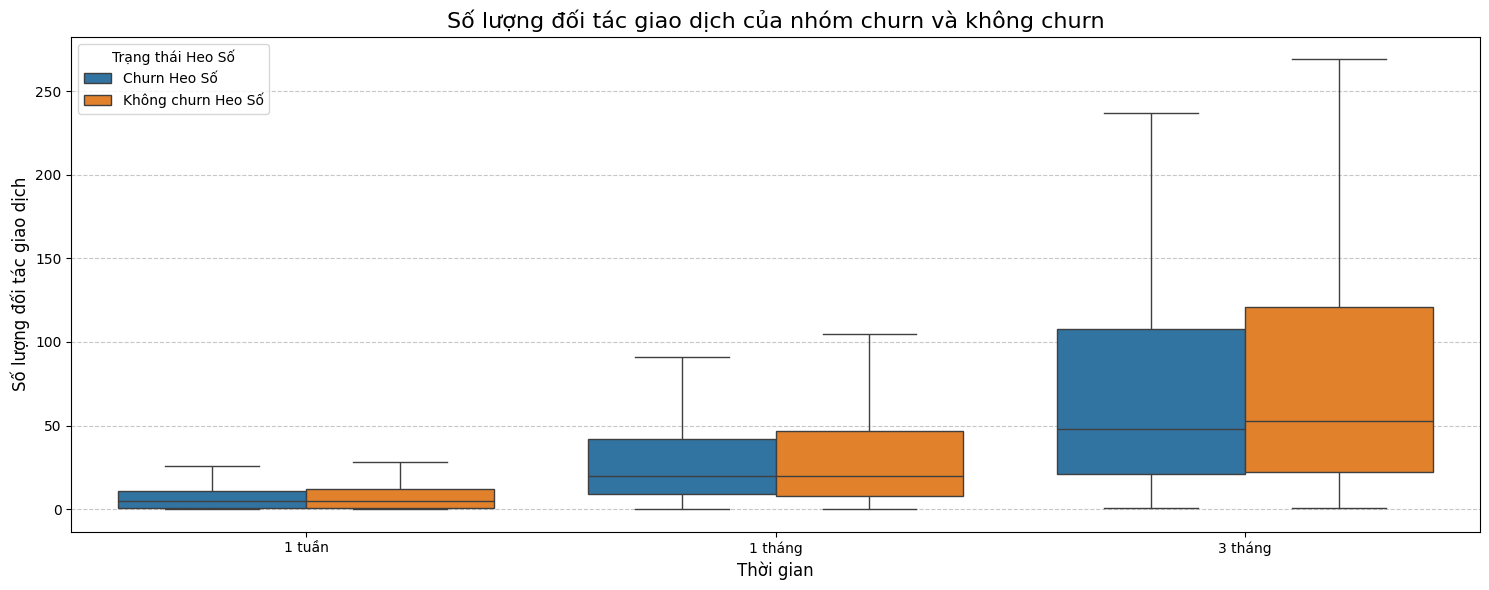

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the columns for transaction partners for different periods
partner_cols = [
    'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
    'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_3_tháng'
]

# Prepare data for plotting by melting it to a long format
# Only include 'dùng_heo_số_label' and the partner_cols for melting
plot_df_partners = df_compare[['dùng_heo_số_label'] + partner_cols].melt(
    id_vars='dùng_heo_số_label',
    var_name='Thời gian',
    value_name='Số lượng đối tác giao dịch'
)

# Map Thời gian labels for better readability
time_period_mapping = {
    'số_lượng_đối_tác_giao_dịch_trong_1_tuần': '1 tuần',
    'số_lượng_đối_tác_giao_dịch_trong_1_tháng': '1 tháng',
    'số_lượng_đối_tác_giao_dịch_trong_3_tháng': '3 tháng'
}
plot_df_partners['Thời gian'] = plot_df_partners['Thời gian'].map(time_period_mapping)

# Create subplots for each time period
plt.figure(figsize=(15, 6))
sns.boxplot(
    x='Thời gian',
    y='Số lượng đối tác giao dịch',
    hue='dùng_heo_số_label',
    data=plot_df_partners,
    palette='tab10',
    showfliers=False # Hide outliers for better visualization of central tendencies
)

plt.title('Số lượng đối tác giao dịch của nhóm churn và không churn', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng đối tác giao dịch', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Sô loại dịch vụ

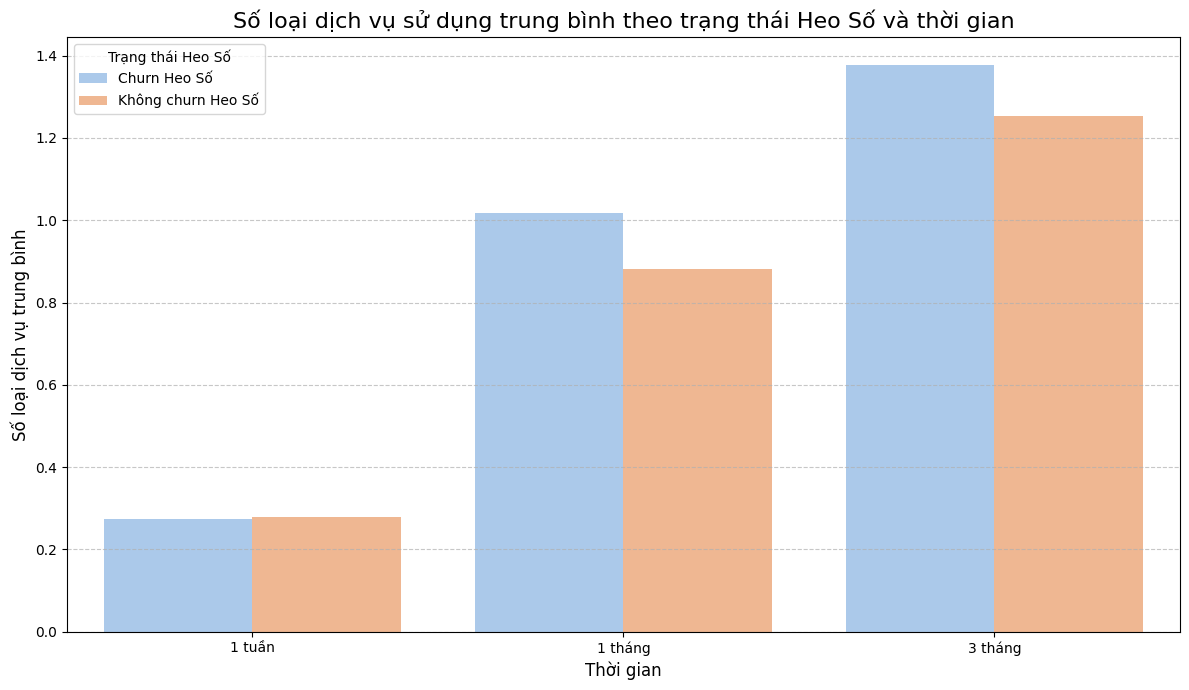

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# (This section is duplicated for standalone execution if previous cells weren't run)
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the columns for number of distinct service types for different periods
service_type_cols = [
    'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
    'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
    'số_loại_dịch_vụ_sử_dụng_trong_3_tháng'
]

# Calculate the average number of service types for each churn group
average_service_types = df_compare.groupby('dùng_heo_số_label')[service_type_cols].mean()

# Prepare data for plotting by melting it to a long format
plot_df_service_types = average_service_types.stack().reset_index()
plot_df_service_types.columns = ['Trạng thái Heo Số', 'Thời gian', 'Số loại dịch vụ trung bình']

# Map Thời gian labels for better readability
time_period_mapping = {
    'số_loại_dịch_vụ_sử_dụng_trong_1_tuần': '1 tuần',
    'số_loại_dịch_vụ_sử_dụng_trong_1_tháng': '1 tháng',
    'số_loại_dịch_vụ_sử_dụng_trong_3_tháng': '3 tháng'
}
plot_df_service_types['Thời gian'] = plot_df_service_types['Thời gian'].map(time_period_mapping)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Thời gian',
    y='Số loại dịch vụ trung bình',
    hue='Trạng thái Heo Số',
    data=plot_df_service_types,
    palette='pastel'
)

plt.title('Số loại dịch vụ sử dụng trung bình theo trạng thái Heo Số và thời gian', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số loại dịch vụ trung bình', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Số lần sử dụng dịch vụ


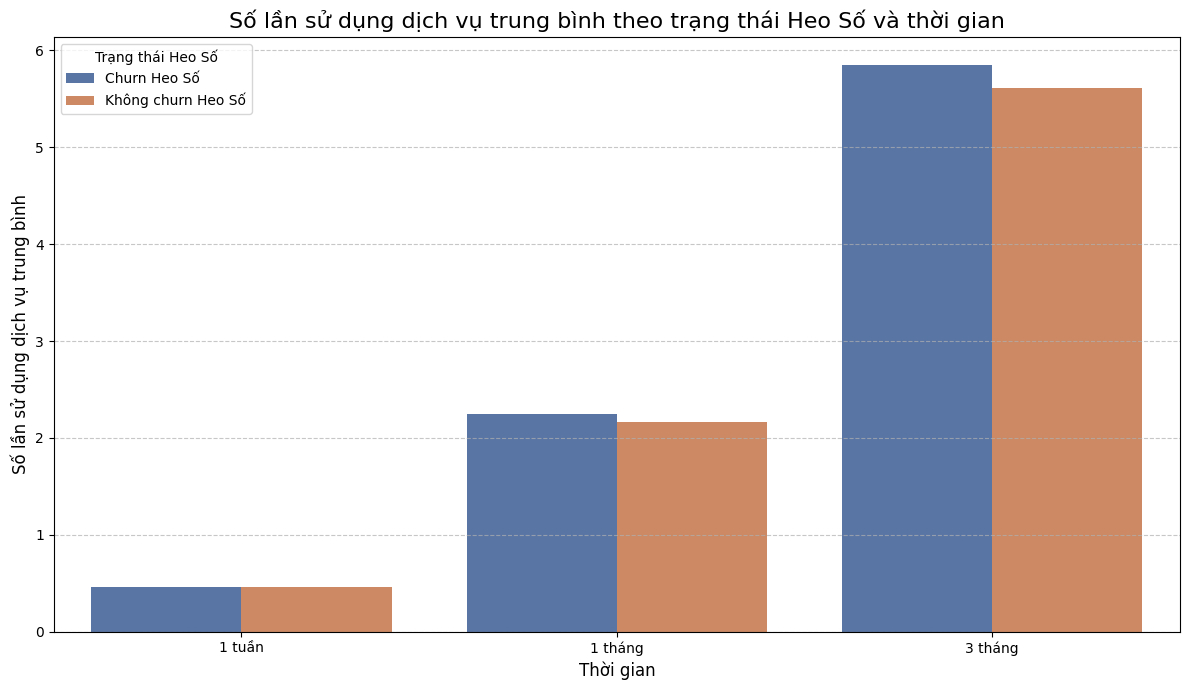

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the columns for number of service usage for different periods
service_usage_cols = [
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng'
]

# Calculate the average number of service usage for each churn group
average_service_usage = df_compare.groupby('dùng_heo_số_label')[service_usage_cols].mean()

# Prepare data for plotting by melting it to a long format
plot_df_service_usage = average_service_usage.stack().reset_index()
plot_df_service_usage.columns = ['Trạng thái Heo Số', 'Thời gian', 'Số lần sử dụng dịch vụ trung bình']

# Map Thời gian labels for better readability
time_period_mapping = {
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần': '1 tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng': '1 tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng': '3 tháng'
}
plot_df_service_usage['Thời gian'] = plot_df_service_usage['Thời gian'].map(time_period_mapping)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Thời gian',
    y='Số lần sử dụng dịch vụ trung bình',
    hue='Trạng thái Heo Số',
    data=plot_df_service_usage,
    palette='deep'
)

plt.title('Số lần sử dụng dịch vụ trung bình theo trạng thái Heo Số và thời gian', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lần sử dụng dịch vụ trung bình', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

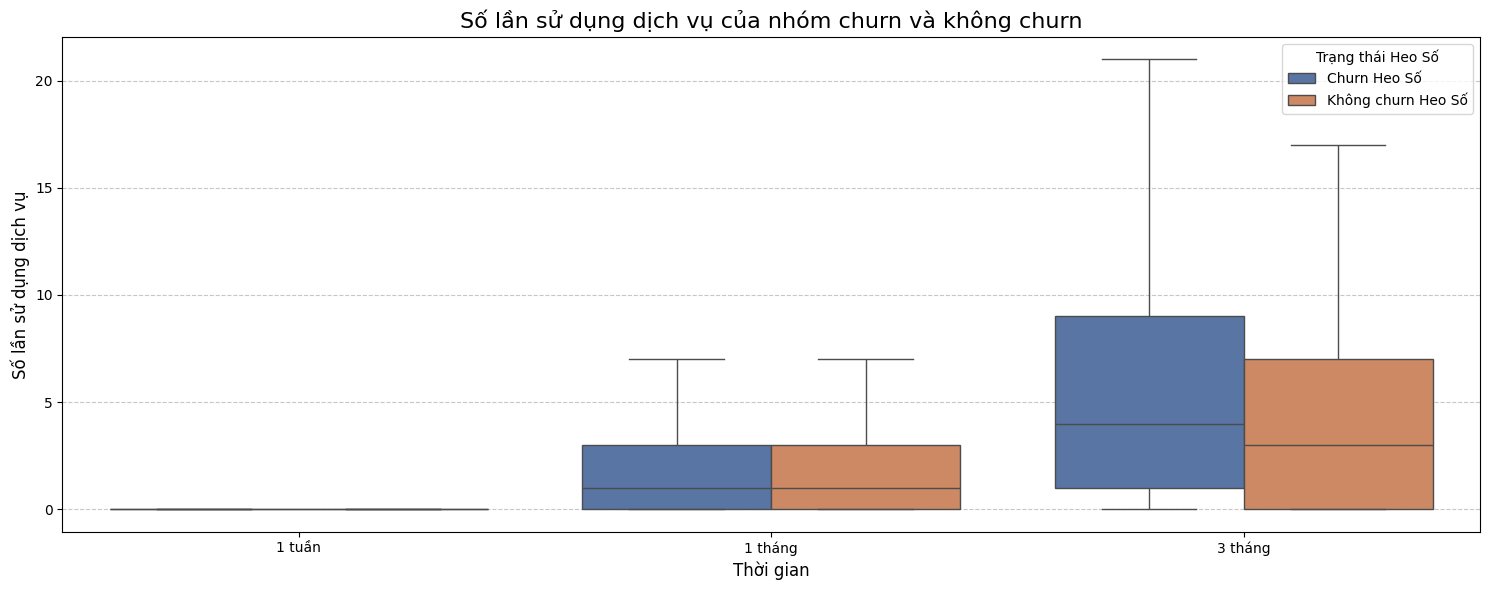

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the columns for number of service usage for different periods
service_usage_cols = [
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng'
]

# Prepare data for plotting by melting it to a long format
plot_df_service_usage = df_compare[['dùng_heo_số_label'] + service_usage_cols].melt(
    id_vars='dùng_heo_số_label',
    var_name='Thời gian',
    value_name='Số lần sử dụng dịch vụ'
)

# Map Thời gian labels for better readability
time_period_mapping = {
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần': '1 tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng': '1 tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng': '3 tháng'
}
plot_df_service_usage['Thời gian'] = plot_df_service_usage['Thời gian'].map(time_period_mapping)

# Create the boxplot
plt.figure(figsize=(15, 6))
sns.boxplot(
    x='Thời gian',
    y='Số lần sử dụng dịch vụ',
    hue='dùng_heo_số_label',
    data=plot_df_service_usage,
    palette='deep',
    showfliers=False # Hide outliers for better visualization of central tendencies
)

plt.title('Số lần sử dụng dịch vụ của nhóm churn và không churn', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lần sử dụng dịch vụ', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Số nhóm giao dịch trong 1 tuần

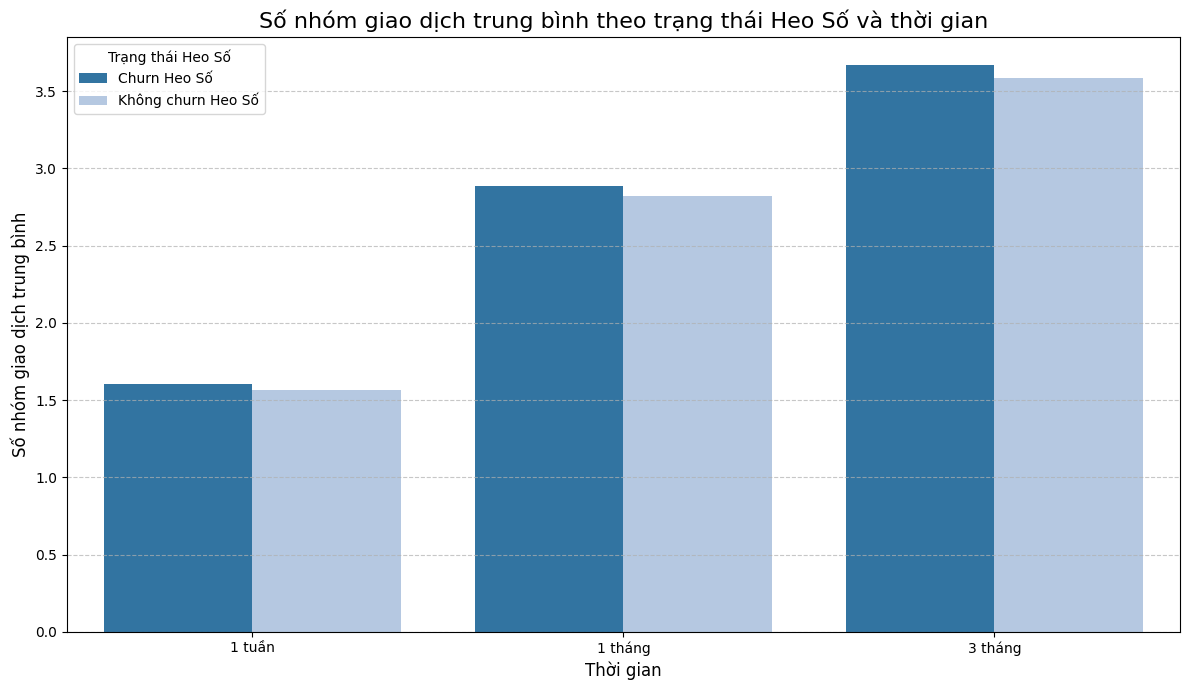

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Re-initializing df_eda_active and 'dùng_heo_số' to ensure consistency ---
# Assuming df_eda_total is available from previous steps

col_m3 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021'
col_m6 = 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021'

df_eda_active = df_eda_active.dropna(subset=[col_m3, col_m6], how='all')
df_eda_active['dùng_heo_số'] = np.nan

not_null_mask_active = df_eda_active[col_m3].notna() & df_eda_active[col_m6].notna()
equal_condition_active = (df_eda_active[col_m3] == df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[equal_condition_active, 'dùng_heo_số'] = 1 # Churn if usage stayed same

less_condition_active = (df_eda_active[col_m3] < df_eda_active[col_m6]) & not_null_mask_active
df_eda_active.loc[less_condition_active, 'dùng_heo_số'] = 0 # Not churn if usage increased
# -----------------------------------------------------------------------

# Filter out NaN values from 'dùng_heo_số' to ensure we only compare defined groups
df_compare = df_eda_active.dropna(subset=['dùng_heo_số']).copy()

# Map numerical churn status to descriptive labels for plotting
churn_labels = {
    1.0: 'Churn Heo Số',
    0.0: 'Không churn Heo Số'
}
df_compare['dùng_heo_số_label'] = df_compare['dùng_heo_số'].map(churn_labels)

# Define the columns for number of distinct transaction groups for different periods
transaction_group_cols = [
    'số_nhóm_giao_dịch_trong_1_tuần',
    'số_nhóm_giao_dịch_trong_1_tháng',
    'số_nhóm_giao_dịch_trong_3_tháng'
]

# Calculate the average number of transaction groups for each churn group
average_transaction_groups = df_compare.groupby('dùng_heo_số_label')[transaction_group_cols].mean()

# Prepare data for plotting by melting it to a long format
plot_df_transaction_groups = average_transaction_groups.stack().reset_index()
plot_df_transaction_groups.columns = ['Trạng thái Heo Số', 'Thời gian', 'Số nhóm giao dịch trung bình']

# Map Thời gian labels for better readability
time_period_mapping = {
    'số_nhóm_giao_dịch_trong_1_tuần': '1 tuần',
    'số_nhóm_giao_dịch_trong_1_tháng': '1 tháng',
    'số_nhóm_giao_dịch_trong_3_tháng': '3 tháng'
}
plot_df_transaction_groups['Thời gian'] = plot_df_transaction_groups['Thời gian'].map(time_period_mapping)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Thời gian',
    y='Số nhóm giao dịch trung bình',
    hue='Trạng thái Heo Số',
    data=plot_df_transaction_groups,
    palette='tab20'
)

plt.title('Số nhóm giao dịch trung bình theo trạng thái Heo Số và thời gian', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số nhóm giao dịch trung bình', fontsize=12)
plt.legend(title='Trạng thái Heo Số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#PREPROCESSING

In [ ]:
df_en = df_eda_active.copy()

## FEATURE ENGINEERING

In [ ]:
categorical_cols = [
    'giới_tính_khách_hàng',
    'tình_trạng_hôn_nhân',
    'tỉnh_thành_sinh_sống',
    'thế_hệ',
    'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',
    'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021',
    'loại_kỳ_hạn_vay'
]

In [ ]:
numerical_cols = [
    # Giao dịch theo thời gian
    'tổng_số_tiền_giao_dịch_trong_1_tuần',
    'tổng_số_tiền_giao_dịch_trong_1_tháng',
    'tổng_số_tiền_giao_dịch_trong_3_tháng',

    # Đa dạng & tần suất giao dịch
    'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tuần',
    'số_nhóm_giao_dịch_trong_1_tuần',
    'số_lượng_đối_tác_giao_dịch_trong_1_tuần',

    'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
    'số_nhóm_giao_dịch_trong_1_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_1_tháng',

    'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
    'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
    'số_nhóm_giao_dịch_trong_3_tháng',
    'số_lượng_đối_tác_giao_dịch_trong_3_tháng',

    # Tháng 3/2021
    'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',
    'tổng_số_giao_dịch_tháng_3_2021',
    'tổng_giá_trị_giao_dịch_tháng_3_2021',

    # Tháng 6/2021
    'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_6_2021',
    'tổng_số_giao_dịch_tháng_6_2021',
    'tổng_giá_trị_giao_dịch_tháng_6_2021',

    # Heo Số – hành vi sử dụng
    'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    'tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021',

    # Số dư & tài chính
    'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
    'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'số_dư_tài_khoản_tiền_gửi',

    # Lãi suất
    'lãi_suất_danh_nghĩa',
    'lãi_suất_thực_tế'
]

##Các biến định tính

In [ ]:
df_en = pd.get_dummies(df_en, columns=['giới_tính_khách_hàng'], prefix='giới_tính', drop_first=True)
print(df_en.head())

    tình_trạng_hôn_nhân  tỉnh_thành_sinh_sống  \
491          Đã kết hôn                  17.0   
677          Đã kết hôn                   1.0   
774          Đã kết hôn                  40.0   
842            Độc thân                  38.0   
993            Độc thân                  52.0   

     tổng_số_tiền_giao_dịch_trong_1_tuần  số_tiền_lớn_nhất_trong_1_tuần  \
491                                  0.0                       0.000143   
677                                  0.0                       0.000408   
774                                  0.0                       0.000017   
842                                  0.0                       0.000028   
993                                  0.0                       0.000000   

     số_tiền_nhỏ_nhất_trong_1_tuần  số_loại_dịch_vụ_sử_dụng_trong_1_tuần  \
491                       0.000005                                   2.0   
677                       0.000045                                   0.0   
774                       

Thực hiện ordinal encoding với các biến thế hệ do chúng có tính thứ bậc

In [ ]:
# Định nghĩa thứ tự ordinal cho cột thế_hệ
generation_order = {
    'Gen Alpha': 0,
    'Gen Z': 1,
    'Millennials (Gen Y)': 2,
    'Gen X': 3,
    'Baby Boomers': 4,
    'Silent Generation': 5,
    'Greatest Generation': 6
}

# Ordinal encoding
df_en['thế_hệ_encoded'] = df_en['thế_hệ'].map(generation_order)
df_en[['thế_hệ', 'thế_hệ_encoded']] \
    .drop_duplicates() \
    .sort_values('thế_hệ_encoded')


,thế_hệ,thế_hệ_encoded
99324,Gen Alpha,0
993,Gen Z,1
491,Millennials (Gen Y),2
15408,Gen X,3
59938,Baby Boomers,4


Thực hiện one hot encoding với biến tình trạng hôn nhân

/tmp/ipython-input-2738105278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_en, x='tình_trạng_hôn_nhân', palette='viridis')


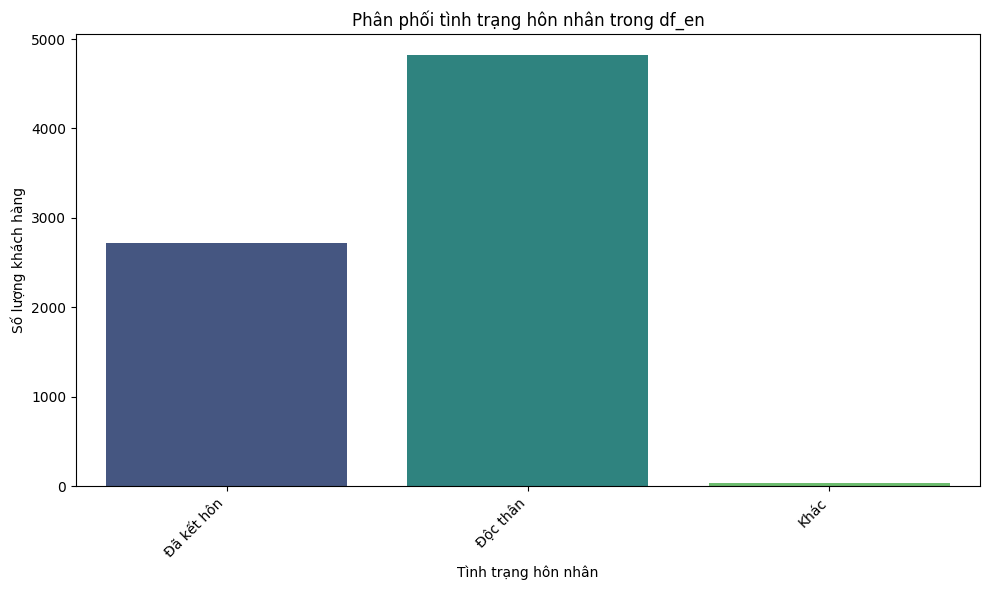

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_en, x='tình_trạng_hôn_nhân', palette='viridis')
plt.title('Phân phối tình trạng hôn nhân trong df_en')
plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Thực hiện one hot encoding với hôn nhân

In [ ]:
# Kiểm tra các giá trị trong cột tình_trạng_hôn_nhân

marital_status_summary = pd.DataFrame({
    'count': df_en['tình_trạng_hôn_nhân'].value_counts(dropna=False),
    'percentage (%)': df_en['tình_trạng_hôn_nhân']
                        .value_counts(normalize=True, dropna=False)
                        .mul(100)
                        .round(2)
})

print(marital_status_summary)

                     count  percentage (%)
tình_trạng_hôn_nhân                       
Độc thân              4817           63.62
Đã kết hôn            2717           35.89
Khác                    37            0.49


Thực hiện one hot encoding với cột các thành phố

In [ ]:
# =========================
# ONE-HOT ENCODING: tình_trạng_hôn_nhân
# =========================

# 1. One-hot encoding
df_en = pd.get_dummies(
    df_en,
    columns=['tình_trạng_hôn_nhân'],
    prefix='tinh_trang_hon_nhan',
    drop_first=False   # giữ đủ các nhóm để kiểm tra
)

# 2. Kiểm tra các cột mới sinh ra từ tình_trạng_hôn_nhân
encoded_marital_cols = [
    col for col in df_en.columns
    if col.startswith('tinh_trang_hon_nhan_')
]

print("Các biến đã được encode từ cột tình_trạng_hôn_nhân:")
print(encoded_marital_cols)

# 3. Xem phân bố giá trị của các biến encode (sanity check)
print("\nPhân bố giá trị các biến one-hot:")
print(df_en[encoded_marital_cols].sum())

Các biến đã được encode từ cột tình_trạng_hôn_nhân:
['tinh_trang_hon_nhan_Khác', 'tinh_trang_hon_nhan_Đã kết hôn', 'tinh_trang_hon_nhan_Độc thân']

Phân bố giá trị các biến one-hot:
tinh_trang_hon_nhan_Khác            37
tinh_trang_hon_nhan_Đã kết hôn    2717
tinh_trang_hon_nhan_Độc thân      4817
dtype: int64


Kiểm tra tỉ lệ các cột tỉnh thành

In [ ]:
province_distribution = pd.DataFrame({
    'count': df_en['Thành_phố'].value_counts(dropna=False),
    'percentage (%)': df_en['Thành_phố']
                            .value_counts(normalize=True, dropna=False)
                            .mul(100)
                            .round(2)
})

print("Phân bố các tỉnh thành sinh sống trong df_en:")
print(province_distribution)

Phân bố các tỉnh thành sinh sống trong df_en:
                 count  percentage (%)
Thành_phố                             
Hà Nội            2222           29.35
TP. Hồ Chí Minh    646            8.53
Hải Phòng          234            3.09
Nam Định           232            3.06
Thanh Hóa          213            2.81
...                ...             ...
Cao Bằng             7            0.09
Bạc Liêu             4            0.05
Bắc Kạn              3            0.04
Lai Châu             3            0.04
NaN                  1            0.01

[64 rows x 2 columns]


In [ ]:
# =========================
# 1. GỘP CÁC TỈNH < 5% → "Khác"
# =========================

# Tính tỷ lệ %
province_ratio = df_en['Thành_phố'].value_counts(normalize=True)

# Các tỉnh >= 5%
major_provinces = province_ratio[province_ratio >= 0.05].index

# Gộp tỉnh nhỏ
df_en['Thành_phố_grouped'] = df_en['Thành_phố'].where(
    df_en['Thành_phố'].isin(major_provinces),
    'Khác'
)

# =========================
# 2. ONE-HOT ENCODING CỘT Thành_phố_grouped
# =========================

df_en = pd.get_dummies(
    df_en,
    columns=['Thành_phố_grouped'],
    prefix='thanh_pho',
    drop_first=False
)

# =========================
# 3. KIỂM TRA CÁC BIẾN ĐÃ ENCODE
# =========================

encoded_city_cols = [
    col for col in df_en.columns
    if col.startswith('thanh_pho_')
]

print("Các biến one-hot được tạo từ cột Thành_phố:")
print(encoded_city_cols)

print("\nPhân bố các biến one-hot (sanity check):")
print(df_en[encoded_city_cols].sum())

Các biến one-hot được tạo từ cột Thành_phố:
['thanh_pho_Hà Nội', 'thanh_pho_Khác', 'thanh_pho_TP. Hồ Chí Minh']

Phân bố các biến one-hot (sanity check):
thanh_pho_Hà Nội             2222
thanh_pho_Khác               4703
thanh_pho_TP. Hồ Chí Minh     646
dtype: int64


##Các biến định lượng

In [ ]:
import pandas as pd

# Exclude known categorical and target columns
excluded_cols = [
    'giới_tính_khách_hàng',
    'tình_trạng_hôn_nhân',
    'thế_hệ',
    'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',
    'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021',
    'loại_kỳ_hạn_vay',
    'Thành_phố', # The original 'Thành_phố' column
    'Thành_phố_grouped',
    'dùng_heo_số', # This is the target variable, not a feature
    'giới_tính_Nữ', # Encoded categorical
    'thế_hệ_encoded', # Encoded ordinal
    'tinh_trang_hon_nhan_Độc thân', # Encoded categorical
    'tinh_trang_hon_nhan_Đã kết hôn', # Encoded categorical
    'tinh_trang_hon_nhan_Khác' # Encoded categorical

]

quantitative_cols_in_df_en = [
    col for col in df_en.columns
    if pd.api.types.is_numeric_dtype(df_en[col]) and col not in excluded_cols
    and not col.startswith('thanh_pho_') # Exclude one-hot encoded city columns
]

print("Các biến định lượng trong df_en:")
for col in quantitative_cols_in_df_en:
    print(f"- {col}")

print(f"\nTổng số biến định lượng: {len(quantitative_cols_in_df_en)}")


Các biến định lượng trong df_en:
- tỉnh_thành_sinh_sống
- tổng_số_tiền_giao_dịch_trong_1_tuần
- số_tiền_lớn_nhất_trong_1_tuần
- số_tiền_nhỏ_nhất_trong_1_tuần
- số_loại_dịch_vụ_sử_dụng_trong_1_tuần
- số_lần_sử_dụng_dịch_vụ_trong_1_tuần
- số_nhóm_giao_dịch_trong_1_tuần
- số_lượng_đối_tác_giao_dịch_trong_1_tuần
- tổng_số_tiền_giao_dịch_trong_1_tháng
- số_tiền_lớn_nhất_trong_1_tháng
- số_tiền_nhỏ_nhất_trong_1_tháng
- số_loại_dịch_vụ_sử_dụng_trong_1_tháng
- số_lần_sử_dụng_dịch_vụ_trong_1_tháng
- số_nhóm_giao_dịch_trong_1_tháng
- số_lượng_đối_tác_giao_dịch_trong_1_tháng
- tổng_số_tiền_giao_dịch_trong_3_tháng
- số_tiền_lớn_nhất_trong_3_tháng
- số_tiền_nhỏ_nhất_trong_3_tháng
- số_loại_dịch_vụ_sử_dụng_trong_3_tháng
- số_lần_sử_dụng_dịch_vụ_trong_3_tháng
- số_nhóm_giao_dịch_trong_3_tháng
- số_lượng_đối_tác_giao_dịch_trong_3_tháng
- số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021
- tổng_số_giao_dịch_tháng_3_2021
- tổng_giá_trị_giao_dịch_tháng_3_2021
- số_lượng_loại_giao_dịch_phổ_biến_nhất_thán

##Tổng hợp các biến sử dụng cho model

In [ ]:
df_en.columns

Index(['tỉnh_thành_sinh_sống', 'tổng_số_tiền_giao_dịch_trong_1_tuần',
       'số_tiền_lớn_nhất_trong_1_tuần', 'số_tiền_nhỏ_nhất_trong_1_tuần',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tuần', 'số_nhóm_giao_dịch_trong_1_tuần',
       'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
       'tổng_số_tiền_giao_dịch_trong_1_tháng',
       'số_tiền_lớn_nhất_trong_1_tháng', 'số_tiền_nhỏ_nhất_trong_1_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
       'số_nhóm_giao_dịch_trong_1_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
       'tổng_số_tiền_giao_dịch_trong_3_tháng',
       'số_tiền_lớn_nhất_trong_3_tháng', 'số_tiền_nhỏ_nhất_trong_3_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
       'số_nhóm_giao_dịch_trong_3_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
       'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',

Bỏ các cột không cần thiết

Bỏ các cột có nguy cơ làm leak dữ liệu

In [ ]:
# List columns related to 'Heo Số' that are not the target variable
df_en_model = df_en.copy()
heoso_cols_to_drop = [
    'tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021',
    'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021',
    #'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
    #'số_dư_tiết_kiệm_heo_số_tháng_6_2021',
    'tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021',
    'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',
    'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'
]

print("Các cột liên quan đến Heo Số bị loại bỏ:")
print([col for col in heoso_cols_to_drop if col in df_en_model.columns])

# Drop these columns from df_en_model
df_en_model = df_en_model.drop(columns=[col for col in heoso_cols_to_drop if col in df_en_model.columns])

print(f"\nSố lượng feature còn lại trong df_en_model: {df_en_model.shape[1] - 1} (trừ cột target)") # -1 for the target variable

Các cột liên quan đến Heo Số bị loại bỏ:
['tổng_số_lần_đăng_nhập_heo_số_tháng_3_2021', 'tổng_số_lần_đăng_nhập_heo_số_tháng_6_2021', 'tổng_số_lần_gửi_tiết_kiệm_heo_số_năm_2021', 'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_3_2021', 'số_lượng_loại_giao_dịch_phổ_biến_nhất_tháng_6_2021']

Số lượng feature còn lại trong df_en_model: 44 (trừ cột target)


Bỏ các cột không phục vụ cho việc dự đoán

In [ ]:
print("Columns in df_en_model:")
print(df_en_model.columns)
print(f"\nTotal number of features in df_en_model: {df_en_model.shape[1]}")

Columns in df_en_model:
Index(['tỉnh_thành_sinh_sống', 'tổng_số_tiền_giao_dịch_trong_1_tuần',
       'số_tiền_lớn_nhất_trong_1_tuần', 'số_tiền_nhỏ_nhất_trong_1_tuần',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tuần', 'số_nhóm_giao_dịch_trong_1_tuần',
       'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
       'tổng_số_tiền_giao_dịch_trong_1_tháng',
       'số_tiền_lớn_nhất_trong_1_tháng', 'số_tiền_nhỏ_nhất_trong_1_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
       'số_nhóm_giao_dịch_trong_1_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
       'tổng_số_tiền_giao_dịch_trong_3_tháng',
       'số_tiền_lớn_nhất_trong_3_tháng', 'số_tiền_nhỏ_nhất_trong_3_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
       'số_nhóm_giao_dịch_trong_3_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
       'loại_giao_dịch_phổ_biến_nhất

In [ ]:
print(df_en_model.isnull().sum())

tỉnh_thành_sinh_sống                            0
tổng_số_tiền_giao_dịch_trong_1_tuần             0
số_tiền_lớn_nhất_trong_1_tuần                   0
số_tiền_nhỏ_nhất_trong_1_tuần                   0
số_loại_dịch_vụ_sử_dụng_trong_1_tuần            0
số_lần_sử_dụng_dịch_vụ_trong_1_tuần             0
số_nhóm_giao_dịch_trong_1_tuần                  0
số_lượng_đối_tác_giao_dịch_trong_1_tuần         0
tổng_số_tiền_giao_dịch_trong_1_tháng            0
số_tiền_lớn_nhất_trong_1_tháng                  0
số_tiền_nhỏ_nhất_trong_1_tháng                  0
số_loại_dịch_vụ_sử_dụng_trong_1_tháng           0
số_lần_sử_dụng_dịch_vụ_trong_1_tháng            0
số_nhóm_giao_dịch_trong_1_tháng                 0
số_lượng_đối_tác_giao_dịch_trong_1_tháng        0
tổng_số_tiền_giao_dịch_trong_3_tháng            0
số_tiền_lớn_nhất_trong_3_tháng                  0
số_tiền_nhỏ_nhất_trong_3_tháng                  0
số_loại_dịch_vụ_sử_dụng_trong_3_tháng           0
số_lần_sử_dụng_dịch_vụ_trong_3_tháng            0


In [ ]:
# =========================
# DROP CÁC CỘT KHÔNG DÙNG TRONG df_en_model
# =========================

cols_to_drop = [
    # Địa lý (giữ bản encode, bỏ bản gốc)
    'tỉnh_thành_sinh_sống',
    'Thành_phố',

    # Min / Max amount (1 tuần, 1 tháng, 3 tháng)
    'số_tiền_lớn_nhất_trong_1_tuần',
    'số_tiền_nhỏ_nhất_trong_1_tuần',
    'số_tiền_lớn_nhất_trong_1_tháng',
    'số_tiền_nhỏ_nhất_trong_1_tháng',
    'số_tiền_lớn_nhất_trong_3_tháng',
    'số_tiền_nhỏ_nhất_trong_3_tháng',

    # Lãi suất
    'lãi_suất_danh_nghĩa',
    'lãi_suất_thực_tế',

    # Tín dụng / phân loại thô
    'loại_kỳ_hạn_vay',
    'thế_hệ',

    # Loại giao dịch phổ biến (biến text)
    'loại_giao_dịch_phổ_biến_nhất_tháng_3_2021',
    'loại_giao_dịch_phổ_biến_nhất_tháng_6_2021'
]

# Chỉ drop các cột thực sự tồn tại (tránh KeyError)
cols_to_drop = [col for col in cols_to_drop if col in df_en_model.columns]

df_en_model = df_en_model.drop(columns=cols_to_drop)

# =========================
# CHECK KẾT QUẢ
# =========================
print("Số feature sau khi drop:", df_en_model.shape[1] - 1)  # trừ target
print("Các cột còn lại:")
print(df_en_model.columns)


Số feature sau khi drop: 30
Các cột còn lại:
Index(['tổng_số_tiền_giao_dịch_trong_1_tuần',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tuần',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tuần', 'số_nhóm_giao_dịch_trong_1_tuần',
       'số_lượng_đối_tác_giao_dịch_trong_1_tuần',
       'tổng_số_tiền_giao_dịch_trong_1_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_1_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_1_tháng',
       'số_nhóm_giao_dịch_trong_1_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_1_tháng',
       'tổng_số_tiền_giao_dịch_trong_3_tháng',
       'số_loại_dịch_vụ_sử_dụng_trong_3_tháng',
       'số_lần_sử_dụng_dịch_vụ_trong_3_tháng',
       'số_nhóm_giao_dịch_trong_3_tháng',
       'số_lượng_đối_tác_giao_dịch_trong_3_tháng',
       'tổng_số_giao_dịch_tháng_3_2021', 'tổng_giá_trị_giao_dịch_tháng_3_2021',
       'tổng_số_giao_dịch_tháng_6_2021', 'tổng_giá_trị_giao_dịch_tháng_6_2021',
       'số_dư_tiết_kiệm_heo_số_tháng_3_2021',
       'số_dư_tiết_kiệm_heo_số_tháng_6_2021', 'số_dư_tài

In [ ]:
df_en_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7571 entries, 491 to 99999
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   tổng_số_tiền_giao_dịch_trong_1_tuần       7571 non-null   float64
 1   số_loại_dịch_vụ_sử_dụng_trong_1_tuần      7571 non-null   float64
 2   số_lần_sử_dụng_dịch_vụ_trong_1_tuần       7571 non-null   float64
 3   số_nhóm_giao_dịch_trong_1_tuần            7571 non-null   float64
 4   số_lượng_đối_tác_giao_dịch_trong_1_tuần   7571 non-null   float64
 5   tổng_số_tiền_giao_dịch_trong_1_tháng      7571 non-null   float64
 6   số_loại_dịch_vụ_sử_dụng_trong_1_tháng     7571 non-null   float64
 7   số_lần_sử_dụng_dịch_vụ_trong_1_tháng      7571 non-null   float64
 8   số_nhóm_giao_dịch_trong_1_tháng           7571 non-null   float64
 9   số_lượng_đối_tác_giao_dịch_trong_1_tháng  7571 non-null   float64
 10  tổng_số_tiền_giao_dịch_trong_3_tháng  

# MODEL

In [ ]:
df_model = df_en_model.copy()

In [ ]:
df_model.shape

(7571, 31)

##LOGISTIC REGRESSION

Train size: 5302
Validation size: 1133
Test size: 1136
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters: {'logistic__penalty': 'l1', 'logistic__C': 1}
Best CV ROC-AUC: 0.7674448671443328

Validation ROC-AUC: 0.7864737242955064
Validation Accuracy: 0.6637246248896734

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.60      0.72       808
         1.0       0.45      0.82      0.58       325

    accuracy                           0.66      1133
   macro avg       0.67      0.71      0.65      1133
weighted avg       0.77      0.66      0.68      1133


Test ROC-AUC: 0.7509088843444672
Test Accuracy: 0.6408450704225352

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.58      0.70       810
         1.0       0.43      0.78      0.56       326

    accuracy                           0.64      1136
   macro avg       0.65      0.68      0.63      1136
weighted avg       0.74      0.64      0.66      1136

Confusion Matrix (Test):
[[473 337]

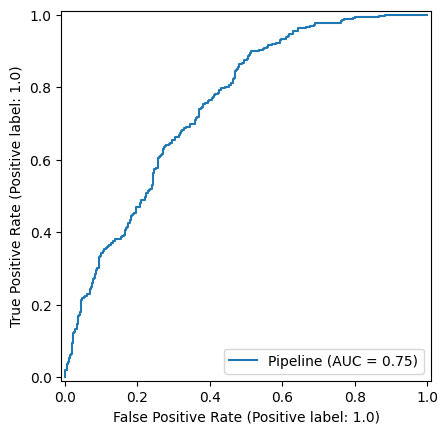

In [ ]:
# =====================================================
# LOGISTIC REGRESSION PIPELINE – RANDOMIZED SEARCH + VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# -------------------------
# 1. Split X / y
# -------------------------
X = df_model.drop(columns=['dùng_heo_số'])
y = df_model['dùng_heo_số']

# -------------------------
# 2. Train / Validation / Test split
# 70% train – 15% val – 15% test
# -------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# -------------------------
# 3. Pipeline: Scaling + SMOTE + Logistic Regression
# -------------------------
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logistic', LogisticRegression(
        solver='saga',
        max_iter=500,
        random_state=42
    ))
])

# -------------------------
# 4. Randomized Search + Cross Validation (TRAIN ONLY)
# -------------------------
param_dist = {
    'logistic__C': [0.01, 0.1, 1],
    'logistic__penalty': ['l1', 'l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=6,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# -------------------------
# 5. Train (CV + SMOTE chỉ trong TRAIN)
# -------------------------
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_model = random_search.best_estimator_

# =====================================================
# 6. EVALUATION ON VALIDATION SET
# =====================================================
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation ROC-AUC:", val_auc)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# =====================================================
# 7. FINAL EVALUATION ON TEST SET
# =====================================================
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTest ROC-AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# =====================================================
# 8. FEATURE IMPORTANCE – LOGISTIC COEFFICIENT
# =====================================================
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.named_steps['logistic'].coef_[0],
    'abs_coefficient': np.abs(best_model.named_steps['logistic'].coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)

print("\nTop 10 features (Logistic coefficients):")
print(coef_df.head(10))

# =====================================================
# 9. FEATURE IMPORTANCE – PERMUTATION (ON VALIDATION)
# =====================================================
perm_importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=3,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("\nTop 10 features (Permutation importance – validation):")
print(perm_df.head(10))

# =====================================================
# 10. SUMMARY METRICS
# =====================================================
print("\n=== SUMMARY METRICS ===")
print(f"Validation | ROC-AUC: {val_auc:.4f} | Accuracy: {val_accuracy:.4f}")
print(f"Test       | ROC-AUC: {test_auc:.4f} | Accuracy: {test_accuracy:.4f}")

##DECISION TREE

Train size: 5302
Validation size: 1133
Test size: 1136
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'dt__min_samples_split': 2, 'dt__min_samples_leaf': 1, 'dt__max_depth': 7, 'dt__criterion': 'entropy'}
Best CV ROC-AUC: 0.8441490255028

Validation ROC-AUC: 0.8367745620715918
Validation Accuracy: 0.7413945278022948

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.79       808
         1.0       0.53      0.91      0.67       325

    accuracy                           0.74      1133
   macro avg       0.74      0.79      0.73      1133
weighted avg       0.83      0.74      0.75      1133


Test ROC-AUC: 0.8295785048852533
Test Accuracy: 0.733274647887324

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.67      0.78       810
         1.0       0.52      0.89      0.66       326

    accuracy               

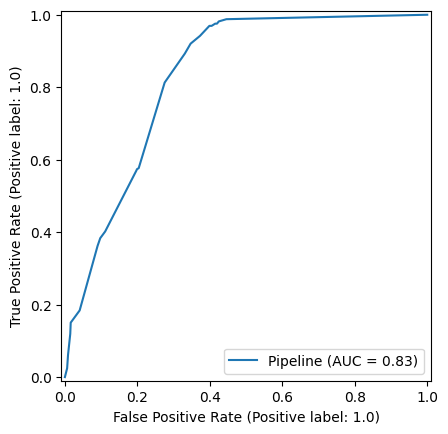

In [ ]:
# =====================================================
# DECISION TREE PIPELINE – RANDOMIZED SEARCH + VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# -------------------------
# 1. Split X / y
# -------------------------
X = df_model.drop(columns=['dùng_heo_số'])
y = df_model['dùng_heo_số']

# -------------------------
# 2. Train / Validation / Test split
# 70% train – 15% val – 15% test
# -------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# -------------------------
# 3. Pipeline: SMOTE + Decision Tree
# -------------------------
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# -------------------------
# 4. Randomized Search + Cross Validation (TRAIN ONLY)
# -------------------------
param_dist = {
    'dt__max_depth': [3, 5, 7],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 5],
    'dt__criterion': ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=24,                # full coverage
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# -------------------------
# 5. Train (CV + SMOTE chỉ trong TRAIN)
# -------------------------
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_model = random_search.best_estimator_

# =====================================================
# 6. EVALUATION ON VALIDATION SET
# =====================================================
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation ROC-AUC:", val_auc)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# =====================================================
# 7. FINAL EVALUATION ON TEST SET
# =====================================================
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTest ROC-AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# =====================================================
# 8. FEATURE IMPORTANCE – DECISION TREE
# =====================================================
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.named_steps['dt'].feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 most important features (Decision Tree):")
print(feature_importance_df.head(10))

##RANDOM FOREST

Train size: 5302
Validation size: 1133
Test size: 1136
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
Best CV ROC-AUC: 0.9267026741043021

Validation ROC-AUC: 0.9523457730388423
Validation Accuracy: 0.8720211827007943

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.91       808
         1.0       0.77      0.79      0.78       325

    accuracy                           0.87      1133
   macro avg       0.84      0.85      0.84      1133
weighted avg       0.87      0.87      0.87      1133


Test ROC-AUC: 0.9353215178368552
Test Accuracy: 0.8556338028169014

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90       810
         1.0       0.76      0.73      0.74       

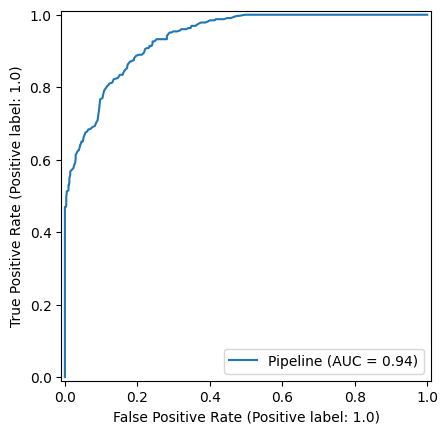

In [ ]:
# =====================================================
# RANDOM FOREST PIPELINE – RANDOMIZED SEARCH + VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# -------------------------
# 1. Split X / y
# -------------------------
X = df_model.drop(columns=['dùng_heo_số'])
y = df_model['dùng_heo_số']

# -------------------------
# 2. Train / Validation / Test split
# 70% train – 15% val – 15% test
# -------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# -------------------------
# 3. Pipeline: SMOTE + Random Forest
# -------------------------
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------
# 4. Randomized Search + Cross Validation (TRAIN ONLY)
# -------------------------
param_dist = {
    'rf__n_estimators': [200, 300, 500],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 5],
    'rf__max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# -------------------------
# 5. Train (CV + SMOTE chỉ trong TRAIN)
# -------------------------
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_model = random_search.best_estimator_

# =====================================================
# 6. EVALUATION ON VALIDATION SET
# =====================================================
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation ROC-AUC:", val_auc)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# =====================================================
# 7. FINAL EVALUATION ON TEST SET
# =====================================================
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTest ROC-AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# =====================================================
# 8. FEATURE IMPORTANCE – RANDOM FOREST
# =====================================================
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.named_steps['rf'].feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 most important features (Random Forest):")
print(feature_importance_df.head(10))

# =====================================================
# 9. SUMMARY METRICS
# =====================================================
print("\n=== SUMMARY METRICS ===")
print(f"Validation | ROC-AUC: {val_auc:.4f} | Accuracy: {val_accuracy:.4f}")
print(f"Test       | ROC-AUC: {test_auc:.4f} | Accuracy: {test_accuracy:.4f}")

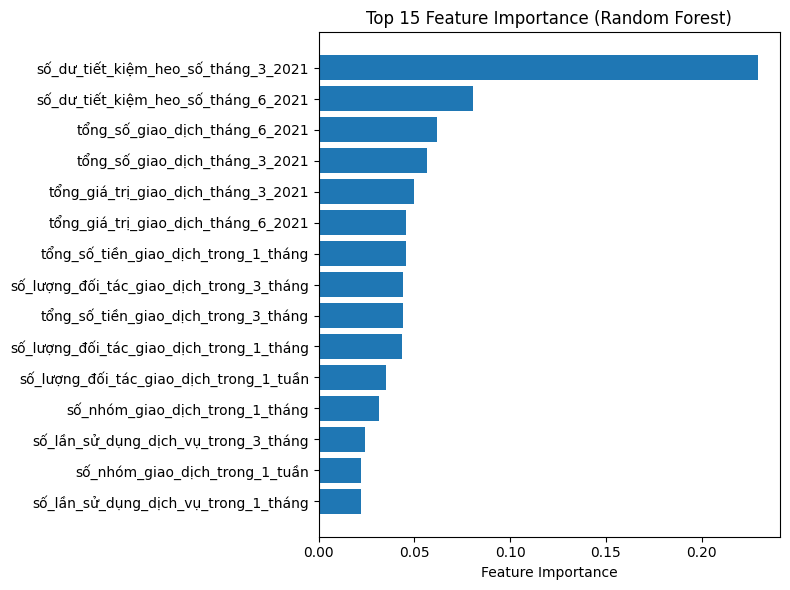

In [ ]:
import matplotlib.pyplot as plt

# Lấy feature importance
importances = best_model.named_steps['rf'].feature_importances_
features = X.columns

fi_df = (
    pd.DataFrame({
        'feature': features,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
)

# Chọn top N feature
TOP_N = 15
fi_top = fi_df.head(TOP_N)

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.barh(fi_top['feature'][::-1], fi_top['importance'][::-1])
plt.xlabel('Feature Importance')
plt.title(f'Top {TOP_N} Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

##LIGHTGBM

Train size: 5302
Validation size: 1133
Test size: 1136
Fitting 5 folds for each of 60 candidates, totalling 300 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3783, number of negative: 3783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4674
[LightGBM] [Info] Number of data points in the train set: 7566, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best parameters: {'lgbm__subsample': 1, 'lgbm__num_leaves': 25, 'lgbm__n_estimators': 75, 'lgbm__min_child_samples': 20, 'lgbm__max_depth': 10, 'lgbm__learning_rate': 0.09, 'lgbm__colsample_bytree': 0.9}
Best CV ROC-AUC: 0.9213820171303755

Validation ROC-AUC: 0.9378979436405179
Validation Accuracy: 0.

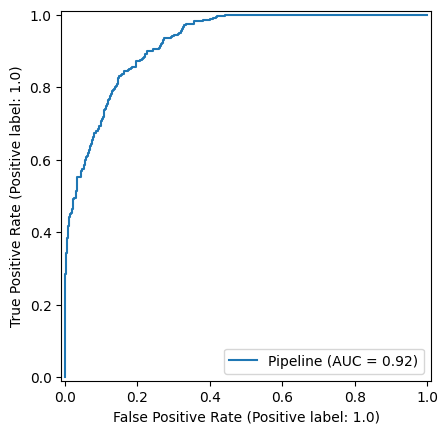

In [ ]:
# =====================================================
# LIGHTGBM PIPELINE – RANDOMIZED SEARCH + VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

# -------------------------
# 1. Split X / y
# -------------------------
X = df_model.drop(columns=['dùng_heo_số'])
y = df_model['dùng_heo_số']

# -------------------------
# 2. Train / Validation / Test split
# 70% train – 15% val – 15% test
# -------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# -------------------------
# 3. Pipeline: SMOTE + LightGBM
# -------------------------
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------
# 4. Randomized Search + CV (TRAIN ONLY)
# -------------------------
param_dist = {
    'lgbm__num_leaves': [15, 20, 25],
    'lgbm__max_depth': [1, 5, 10],
    'lgbm__learning_rate': [0.01, 0.05, 0.09],
    'lgbm__n_estimators': [50, 75, 100],
    'lgbm__min_child_samples': [10, 20, 25],
    'lgbm__subsample': [0.7, 0.9, 1],
    'lgbm__colsample_bytree': [0.7, 0.9, 1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# -------------------------
# 5. Train (CV + SMOTE chỉ trong TRAIN)
# -------------------------
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_model = random_search.best_estimator_

# =====================================================
# 6. EVALUATION ON VALIDATION SET
# =====================================================
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation ROC-AUC:", val_auc)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# =====================================================
# 7. FINAL EVALUATION ON TEST SET
# =====================================================
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTest ROC-AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# =====================================================
# 8. FEATURE IMPORTANCE – LIGHTGBM
# =====================================================
lgbm_model = best_model.named_steps['lgbm']

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_gain': lgbm_model.feature_importances_
}).sort_values(by='importance_gain', ascending=False)

print("\nTop 10 most important features (LightGBM):")
print(feature_importance_df.head(10))

# =====================================================
# 9. SUMMARY METRICS
# =====================================================
print("\n=== SUMMARY METRICS ===")
print(f"Validation | ROC-AUC: {val_auc:.4f} | Accuracy: {val_accuracy:.4f}")
print(f"Test       | ROC-AUC: {test_auc:.4f} | Accuracy: {test_accuracy:.4f}")

##XGBOOST

Train size: 5302
Validation size: 1133
Test size: 1136
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:26:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'xgb__subsample': 0.7, 'xgb__scale_pos_weight': np.float64(2.490454246214615), 'xgb__n_estimators': 500, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0, 'xgb__colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9334632853376318

Validation ROC-AUC: 0.950026656511805
Validation Accuracy: 0.8649602824360106

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90       808
         1.0       0.71      0.90      0.79       325

    accuracy                           0.86      1133
   macro avg       0.83      0.88      0.85      1133
weighted avg       0.89      0.86      0.87      1133


Test ROC-AUC: 0.9396197833825646
Test Accuracy: 0.8450704225352113

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.84      0.88       810
         1.0       0.68      0.87      0.76       326

    accuracy   

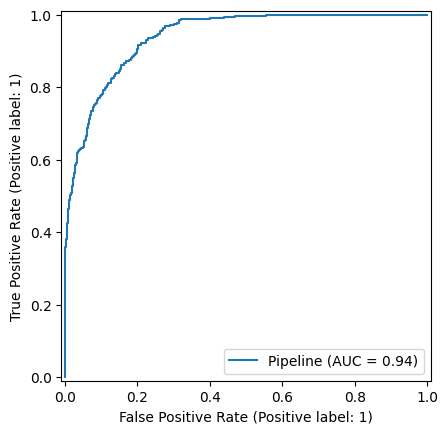

In [ ]:
# =====================================================
# XGBOOST PIPELINE – RANDOMIZED SEARCH + VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

# -------------------------
# 1. Split X / y
# -------------------------
X = df_model.drop(columns=['dùng_heo_số'])
y = df_model['dùng_heo_số']

# -------------------------
# 2. Train / Validation / Test split
# 70% train – 15% val – 15% test
# -------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# -------------------------
# 3. Pipeline: SMOTE + XGBoost
# -------------------------
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------
# 4. Randomized Search + CV (TRAIN ONLY)
# -------------------------
param_dist = {
    'xgb__n_estimators': [200, 500],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.9, 1.0],
    'xgb__min_child_weight': [1, 5, 10],
    'xgb__gamma': [0, 0.1, 0.3],
    'xgb__scale_pos_weight': [
        1,
        y_train.value_counts()[0] / y_train.value_counts()[1]
    ]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# -------------------------
# 5. Train (CV + SMOTE chỉ trong TRAIN)
# -------------------------
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

best_model = random_search.best_estimator_

# =====================================================
# 6. EVALUATION ON VALIDATION SET
# =====================================================
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("\nValidation ROC-AUC:", val_auc)
print("Validation Accuracy:", val_accuracy)

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

# =====================================================
# 7. FINAL EVALUATION ON TEST SET
# =====================================================
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTest ROC-AUC:", test_auc)
print("Test Accuracy:", test_accuracy)

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# =====================================================
# 8. FEATURE IMPORTANCE – XGBOOST
# =====================================================
xgb_model = best_model.named_steps['xgb']

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_gain': xgb_model.feature_importances_
}).sort_values(by='importance_gain', ascending=False)

print("\nTop 10 most important features (XGBoost):")
print(feature_importance_df.head(10))

# =====================================================
# 9. SUMMARY METRICS
# =====================================================
print("\n=== SUMMARY METRICS ===")
print(f"Validation | ROC-AUC: {val_auc:.4f} | Accuracy: {val_accuracy:.4f}")
print(f"Test       | ROC-AUC: {test_auc:.4f} | Accuracy: {test_accuracy:.4f}")